# VC Syndication Networks: Nestedness Analysis

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import warnings
from tqdm import tqdm  # For progress bar
from networkx.algorithms.community import greedy_modularity_communities
from matplotlib.patches import ConnectionPatch

# warnings.filterwarnings('ignore')

import sys
import os
import re

sys.path.append('./libs') 

# Import custom modules
from libs.data_cleaning import *
from libs.data_extraction import *
from libs.network_analysis import *
from libs.nestedsness_calculator import *
from libs.curveball import *

plt.style.use('default')
sns.set_palette('husl')

In [ ]:
country = "fr"
raw_dir = f'../data/raw/{country}'
processed_dir = f'../data/processed/{country}'
figures_dir = f'../reports/figures/{country}'

edges_file = f"{processed_dir}/edges.csv"
nodes_file = f"{processed_dir}/nodes.csv"
communities_file = f"{processed_dir}/communities.csv.gz"
investors_with_communities_file = f"{processed_dir}/investors_with_communities.csv.gz"
community_nestedness_file = f"{processed_dir}/community_nestedness_results.csv.gz"

# Create figures directory if it doesn't exist
os.makedirs(figures_dir, exist_ok=True)

In [ ]:
# Create cleaned data on processed_dir. 
# Useful for first time run, then deactivate to save resources
GENERATE_CLEAN_DATA = False

# Calculate communities using greedy_modularity_communities or load from saved parquet files
CALCULATE_COMMUNITIES = True

# Activate 
CALCULATE_COMMUNITIES_NESTEDNESS = True

CALCULATE_COMMUNITIES_TS_NESTEDNESS = True

In [4]:
if (GENERATE_CLEAN_DATA):
  generate_cleaned_data(raw_dir, processed_dir)

cleaned_data = load_clean_data(processed_dir)

companies_clean = cleaned_data['companies']
investors_clean = cleaned_data['investors']
investments_clean = cleaned_data['investments']
funding_rounds_clean = cleaned_data['funding_rounds']

print(f"After cleaning:")
print(f"Companies: {len(companies_clean):,}")
print(f"Investors: {len(investors_clean):,}")
print(f"Investments: {len(investments_clean):,}")
print(f"Funding rounds: {len(funding_rounds_clean):,}")

After cleaning:
Companies: 2,361
Investors: 4,564
Investments: 10,163
Funding rounds: 14,375


## Data ETL

In [5]:
vc_investments = extract_vc_investments(cleaned_data['investments'])
vc_investments['investor_name'] = vc_investments[['investor_name', 'investment_type']].agg('-'.join, axis=1)

Found 5826 VC investments
Unique companies with VC funding: 1849


In [6]:
overall_stats = {
  'unique_investors': vc_investments['investor_uuid'].nunique(),
  'unique_companies': vc_investments['org_uuid'].nunique(),
  'total_investments': len(vc_investments),
  'total_funding_sum': vc_investments['raised_amount_usd'].sum(),
  'mean_funding': vc_investments['raised_amount_usd'].mean(),
  'median_funding': vc_investments['raised_amount_usd'].median(),
  'min_year': vc_investments['announced_year'].min(),
  'max_year': vc_investments['announced_year'].max()
}
for k, v in overall_stats.items():
  print(f"{k}: {v}")


unique_investors: 1206
unique_companies: 1849
total_investments: 5826
total_funding_sum: 124542691367.0
mean_funding: 22805839.84013917
median_funding: 6100000.0
min_year: 1999
max_year: 2025


In [7]:
early_stages = set(['angel', 'pre_seed', 'seed', 'series_a'])
late_stages = set(['series_b', 'series_c', 'series_d', 'series_e', 'series_f', 'series_g', 'series_h', 'series_i'])
min_year = 2004
max_year = 2024

early_stage_mask = vc_investments['investment_type'].isin(early_stages)
late_stage_mask = vc_investments['investment_type'].isin(late_stages)

# Create left and right
right_investments = vc_investments[
  (early_stage_mask)
]

left_investments = vc_investments[
  (late_stage_mask)
]

investments_pairs = create_investment_pairs(left_investments, right_investments, 'left', 'right')
investments_pairs['announced_year'] = investments_pairs[['announced_year_left', 'announced_year_right']].max(axis=1)
investments_pairs['year'] = investments_pairs['announced_year']
investments_pairs['total_funding_usd'] = investments_pairs['total_funding_usd_left']
investments_pairs['company_country'] = investments_pairs['company_country_left']
investments_pairs['category'] = investments_pairs['category_left']

Created 4136 investment pairs
Covering 241 unique statups


In [8]:
investments_pairs_clean = investments_pairs[[
    'investor_name_left',
    'investor_name_right',
    'announced_year_left',
    'announced_year_right', 
    'org_uuid',
    'total_funding_usd',
    'total_funding_usd_left',
    'total_funding_usd_right',
    'year',
    'company_country',
    'investor_country_left',
    'investor_country_right',
    'investor_region_left',
    'investor_region_right',
    'investment_type_left',
    'investment_type_right',
    'category_left',
    'category_right',
]].copy()

investments_pairs_clean = investments_pairs_clean.dropna(subset=['year'])
# investments_pairs_clean = investments_pairs_clean[(investments_pairs_clean['year'] >= min_year) & (investments_pairs_clean['year'] <= max_year)]

# Filter out pairs where the VCs might be related (first 5 characters of names match)
investments_pairs_clean = investments_pairs_clean[
    investments_pairs_clean['investor_name_left'].str[:5] != 
    investments_pairs_clean['investor_name_right'].str[:5]
]

## Dataset Analysis

### Descriptive Analysis

#### Investment Data Overview

In [9]:
# This section provides comprehensive descriptive statistics and visualizations
# for the key variables used throughout the analysis

print("="*80)
print("COMPREHENSIVE DESCRIPTIVE ANALYSIS OF INVESTMENTS_CLEAN DATASET")
print("="*80)

# Basic dataset overview
print(f"\n1. DATASET OVERVIEW")
print("-" * 40)
print(f"Total investment records: {len(investments_clean):,}")
print(f"Time period: {investments_clean['announced_year'].min()} - {investments_clean['announced_year'].max()}")
print(f"Number of unique companies: {investments_clean['org_uuid'].nunique():,}")
print(f"Number of unique investors: {investments_clean['investor_uuid'].nunique():,}")
print(f"Number of unique funding rounds: {investments_clean['funding_round_uuid'].nunique() if 'funding_round_uuid' in investments_clean.columns else 'N/A'}")

# Check for missing values
print(f"\n2. DATA COMPLETENESS")
print("-" * 40)
missing_summary = investments_clean.isnull().sum()
missing_pct = (missing_summary / len(investments_clean)) * 100
print("Missing values by column:")
for col in investments_clean.columns:
    if missing_summary[col] > 0:
        print(f"  {col}: {missing_summary[col]:,} ({missing_pct[col]:.1f}%)")
    else:
        print(f"  {col}: 0 (0.0%)")

# Key columns analysis
key_numeric_cols = ['announced_year', 'total_funding_usd']
key_categorical_cols = ['investment_type', 'investor_country', 'investor_region', 'category']

print(f"\n3. NUMERIC VARIABLES SUMMARY")
print("-" * 40)
for col in key_numeric_cols:
    if col in investments_clean.columns:
        data = investments_clean[col].dropna()
        print(f"\n{col.upper()}:")
        print(f"  Count: {len(data):,}")
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Min: {data.min():.2f}")
        print(f"  Max: {data.max():.2f}")
        print(f"  25th percentile: {data.quantile(0.25):.2f}")
        print(f"  75th percentile: {data.quantile(0.75):.2f}")

print(f"\n4. CATEGORICAL VARIABLES SUMMARY")
print("-" * 40)
for col in key_categorical_cols:
    if col in investments_clean.columns:
        data = investments_clean[col].dropna()
        value_counts = data.value_counts()
        print(f"\n{col.upper()} (top 10):")
        print(f"  Total unique values: {len(value_counts)}")
        print(f"  Most common values:")
        for i, (value, count) in enumerate(value_counts.head(10).items()):
            pct = (count / len(data)) * 100
            print(f"    {i+1}. {value}: {count:,} ({pct:.1f}%)")

# Syndication analysis summary
print(f"\n5. SYNDICATION CHARACTERISTICS")
print("-" * 40)
if 'syndication' in investments_clean.columns:
    syndicated_count = investments_clean['syndication'].sum()
    total_count = len(investments_clean)
    syndicated_pct = (syndicated_count / total_count) * 100
    print(f"Syndicated investments: {syndicated_count:,} ({syndicated_pct:.1f}%)")
    print(f"Non-syndicated investments: {total_count - syndicated_count:,} ({100-syndicated_pct:.1f}%)")
else:
    print("Syndication indicator not available in current dataset")

COMPREHENSIVE DESCRIPTIVE ANALYSIS OF INVESTMENTS_CLEAN DATASET

1. DATASET OVERVIEW
----------------------------------------
Total investment records: 10,163
Time period: 1999 - 2025
Number of unique companies: 2,361
Number of unique investors: 2,343
Number of unique funding rounds: 4647

2. DATA COMPLETENESS
----------------------------------------
Missing values by column:
  uuid: 0 (0.0%)
  funding_round_uuid: 0 (0.0%)
  investor_uuid: 0 (0.0%)
  is_lead_investor: 6,225 (61.3%)
  investor_name: 0 (0.0%)
  investor_types: 802 (7.9%)
  investment_count: 0 (0.0%)
  investor_region: 164 (1.6%)
  investor_country: 164 (1.6%)
  investor_founded_year: 643 (6.3%)
  investor_description: 0 (0.0%)
  num_exits: 1,744 (17.2%)
  investor_logo_url: 554 (5.5%)
  investment_type: 0 (0.0%)
  announced_year: 0 (0.0%)
  raised_amount_usd: 812 (8.0%)
  org_uuid: 0 (0.0%)
  company_name: 0 (0.0%)
  company_location: 0 (0.0%)
  company_city: 0 (0.0%)
  company_country: 0 (0.0%)
  company_continent: 0 (0

#### Syndication Trends

Structure of investments_clean:
Shape: (10163, 35)
Columns: ['uuid', 'funding_round_uuid', 'investor_uuid', 'is_lead_investor', 'investor_name', 'investor_types', 'investment_count', 'investor_region', 'investor_country', 'investor_founded_year', 'investor_description', 'num_exits', 'investor_logo_url', 'investment_type', 'announced_year', 'raised_amount_usd', 'org_uuid', 'company_name', 'company_location', 'company_city', 'company_country', 'company_continent', 'company_ecosystem', 'total_funding_usd', 'fundraising_speed', 'last_funding_year', 'category_groups_list', 'short_description', 'keywords', 'last_valuation', 'first_ipo_year', 'category', 'investor_ecosystem', 'syndication', 'total_funding_by_investor']

First few rows:
                                   uuid                    funding_round_uuid  \
0  c684e50f-4772-15a9-5a13-84aaa89001aa  25b142a6-ea15-fe19-c4d1-a6767eacbf2b   
1  3c313f91-d8f9-18b5-0a22-0e4395fb2f86  25b142a6-ea15-fe19-c4d1-a6767eacbf2b   
2  e0c51729-993a-c

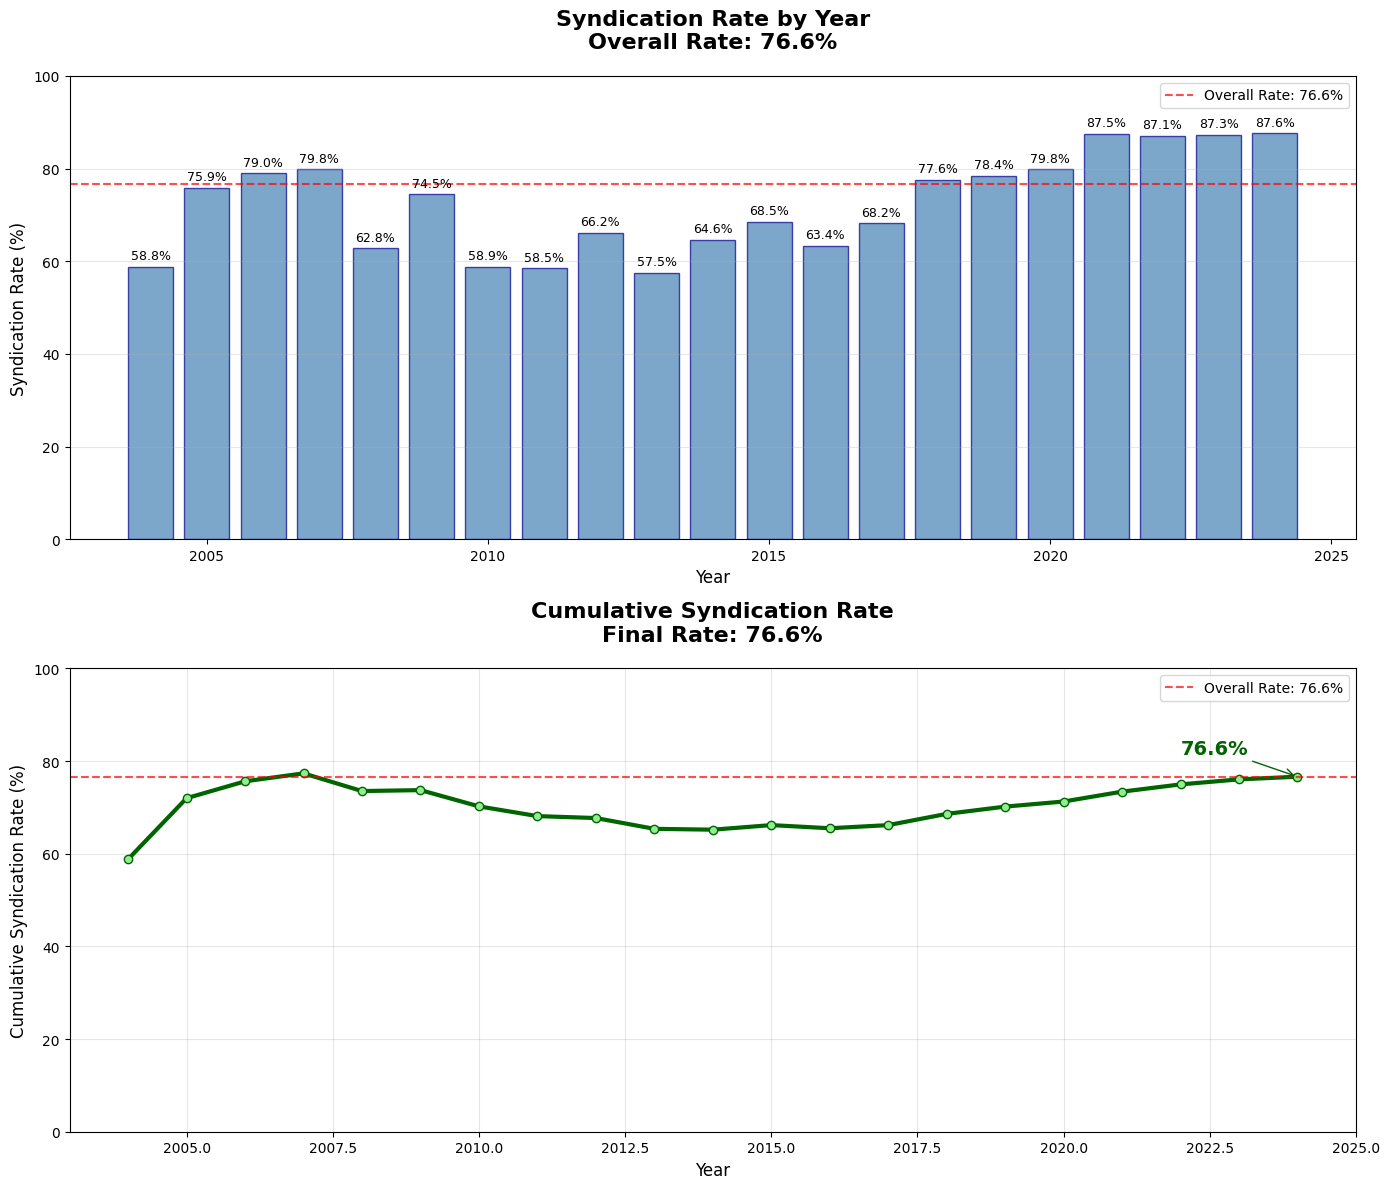


SYNDICATION TRENDS SUMMARY
Analysis period: 2004-2024
Total investments analyzed: 10,075
Syndicated investments: 7,721
Overall syndication rate: 76.6%

Year-by-year breakdown:
  2004: 58.8% (10/17)
  2005: 75.9% (44/58)
  2006: 79.0% (64/81)
  2007: 79.8% (87/109)
  2008: 62.8% (59/94)
  2009: 74.5% (73/98)
  2010: 58.9% (83/141)
  2011: 58.5% (76/130)
  2012: 66.2% (129/195)
  2013: 57.5% (157/273)
  2014: 64.6% (241/373)
  2015: 68.5% (451/658)
  2016: 63.4% (452/713)
  2017: 68.2% (685/1005)
  2018: 77.6% (823/1060)
  2019: 78.4% (746/951)
  2020: 79.8% (610/764)
  2021: 87.5% (889/1016)
  2022: 87.1% (871/1000)
  2023: 87.3% (731/837)
  2024: 87.6% (440/502)

Trends:
  Highest year-by-year rate: 87.6% in 2024
  Lowest year-by-year rate: 57.5% in 2013
  Final cumulative rate: 76.6%


In [10]:
# First, let's understand the structure of investments_clean and create syndication indicator
print("Structure of investments_clean:")
print(f"Shape: {investments_clean.shape}")
print(f"Columns: {investments_clean.columns.tolist()}")
print("\nFirst few rows:")
print(investments_clean.head())

# Create syndication indicator - investments are syndicated if there are multiple investors in the same funding round
if 'funding_round_uuid' in investments_clean.columns:
    # Count investors per funding round
    investors_per_round = investments_clean.groupby('funding_round_uuid')['investor_uuid'].nunique().reset_index()
    investors_per_round.columns = ['funding_round_uuid', 'investor_count']
    
    # Merge back to create syndication indicator
    investments_with_syndication = investments_clean.merge(investors_per_round, on='funding_round_uuid', how='left')
    investments_with_syndication['syndication'] = investments_with_syndication['investor_count'] > 1
    
    print(f"\nSyndication analysis:")
    print(f"Total investments: {len(investments_with_syndication):,}")
    syndicated_count = investments_with_syndication['syndication'].sum()
    total_count = len(investments_with_syndication)
    syndicated_pct = (syndicated_count / total_count) * 100
    print(f"Syndicated investments: {syndicated_count:,} ({syndicated_pct:.1f}%)")
    print(f"Non-syndicated investments: {total_count - syndicated_count:,} ({100-syndicated_pct:.1f}%)")
    
else:
    print("No funding_round_uuid column found. Creating alternative syndication indicator...")
    # Alternative: identify syndication by company-year combinations with multiple investors
    # This is less precise but workable if funding_round_uuid is not available
    investments_with_syndication = investments_clean.copy()
    
    # Group by company and year to count unique investors
    company_year_investors = investments_clean.groupby(['org_uuid', 'announced_year'])['investor_uuid'].nunique().reset_index()
    company_year_investors.columns = ['org_uuid', 'announced_year', 'investor_count']
    
    # Merge back to create syndication indicator
    investments_with_syndication = investments_clean.merge(
        company_year_investors, 
        on=['org_uuid', 'announced_year'], 
        how='left'
    )
    investments_with_syndication['syndication'] = investments_with_syndication['investor_count'] > 1
    
    print(f"\nSyndication analysis (by company-year):")
    print(f"Total investments: {len(investments_with_syndication):,}")
    syndicated_count = investments_with_syndication['syndication'].sum()
    total_count = len(investments_with_syndication)
    syndicated_pct = (syndicated_count / total_count) * 100
    print(f"Investments with syndication: {syndicated_count:,} ({syndicated_pct:.1f}%)")
    print(f"Investments without syndication: {total_count - syndicated_count:,} ({100-syndicated_pct:.1f}%)")

# Update the investments_clean variable with syndication information
investments_clean = investments_with_syndication.copy()

# Now create the syndication trends plot
print(f"\nCreating syndication trends visualization...")

# Filter data for the analysis period
analysis_data = investments_clean[
    (investments_clean['announced_year'] >= min_year) & 
    (investments_clean['announced_year'] <= max_year)
].copy()

print(f"Analysis period: {min_year} to {max_year}")
print(f"Investments in analysis period: {len(analysis_data):,}")

# Calculate year-by-year syndication percentages
yearly_stats = analysis_data.groupby('announced_year').agg({
    'syndication': ['sum', 'count']
}).reset_index()

yearly_stats.columns = ['year', 'syndicated_count', 'total_count']
yearly_stats['syndicated_pct'] = (yearly_stats['syndicated_count'] / yearly_stats['total_count']) * 100

# Calculate cumulative syndication percentages
cumulative_syndicated = []
cumulative_total = []
cumulative_pct = []

for year in sorted(yearly_stats['year']):
    cum_data = analysis_data[analysis_data['announced_year'] <= year]
    cum_syndicated = cum_data['syndication'].sum()
    cum_total = len(cum_data)
    cum_pct = (cum_syndicated / cum_total * 100) if cum_total > 0 else 0
    
    cumulative_syndicated.append(cum_syndicated)
    cumulative_total.append(cum_total)
    cumulative_pct.append(cum_pct)

cumulative_df = pd.DataFrame({
    'year': sorted(yearly_stats['year']),
    'cumulative_syndicated': cumulative_syndicated,
    'cumulative_total': cumulative_total,
    'cumulative_pct': cumulative_pct
})

# Calculate overall syndication percentage
overall_syndicated = analysis_data['syndication'].sum()
overall_total = len(analysis_data)
overall_pct = (overall_syndicated / overall_total) * 100

print(f"\nOverall syndication rate: {overall_pct:.1f}% ({overall_syndicated:,}/{overall_total:,})")

# Create the plot
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Year-by-year syndication percentages
ax1 = axes[0]
bars = ax1.bar(yearly_stats['year'], yearly_stats['syndicated_pct'], 
               alpha=0.7, color='steelblue', edgecolor='darkblue', linewidth=1)
ax1.set_title(f'Syndication Rate by Year\nOverall Rate: {overall_pct:.1f}%', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Syndication Rate (%)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 100)

# Add value labels on bars
for bar, pct in zip(bars, yearly_stats['syndicated_pct']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 2: Cumulative syndication percentages
ax2 = axes[1]
line = ax2.plot(cumulative_df['year'], cumulative_df['cumulative_pct'], 
                marker='o', linewidth=3, markersize=6, color='darkgreen', 
                markerfacecolor='lightgreen', markeredgecolor='darkgreen')
ax2.set_title(f'Cumulative Syndication Rate\nFinal Rate: {overall_pct:.1f}%', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Cumulative Syndication Rate (%)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Add final percentage as annotation
ax2.annotate(f'{overall_pct:.1f}%', 
             xy=(cumulative_df['year'].iloc[-1], cumulative_df['cumulative_pct'].iloc[-1]),
             xytext=(cumulative_df['year'].iloc[-1] - 2, cumulative_df['cumulative_pct'].iloc[-1] + 5),
             fontsize=14, fontweight='bold', color='darkgreen',
             arrowprops=dict(arrowstyle='->', color='darkgreen'))

# Add horizontal line for overall percentage
ax1.axhline(y=overall_pct, color='red', linestyle='--', alpha=0.7, 
            label=f'Overall Rate: {overall_pct:.1f}%')
ax1.legend()

ax2.axhline(y=overall_pct, color='red', linestyle='--', alpha=0.7, 
            label=f'Overall Rate: {overall_pct:.1f}%')
ax2.legend()

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(figures_dir, 'syndication_trends.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n" + "="*60)
print(f"SYNDICATION TRENDS SUMMARY")
print(f"="*60)
print(f"Analysis period: {min_year}-{max_year}")
print(f"Total investments analyzed: {overall_total:,}")
print(f"Syndicated investments: {overall_syndicated:,}")
print(f"Overall syndication rate: {overall_pct:.1f}%")
print(f"\nYear-by-year breakdown:")
for _, row in yearly_stats.iterrows():
    print(f"  {int(row['year'])}: {row['syndicated_pct']:.1f}% ({int(row['syndicated_count'])}/{int(row['total_count'])})")

print(f"\nTrends:")
print(f"  Highest year-by-year rate: {yearly_stats['syndicated_pct'].max():.1f}% in {yearly_stats.loc[yearly_stats['syndicated_pct'].idxmax(), 'year']}")
print(f"  Lowest year-by-year rate: {yearly_stats['syndicated_pct'].min():.1f}% in {yearly_stats.loc[yearly_stats['syndicated_pct'].idxmin(), 'year']}")
print(f"  Final cumulative rate: {cumulative_df['cumulative_pct'].iloc[-1]:.1f}%")

#### Investment Activity Over Time


TEMPORAL ANALYSIS: Investment Activity Evolution


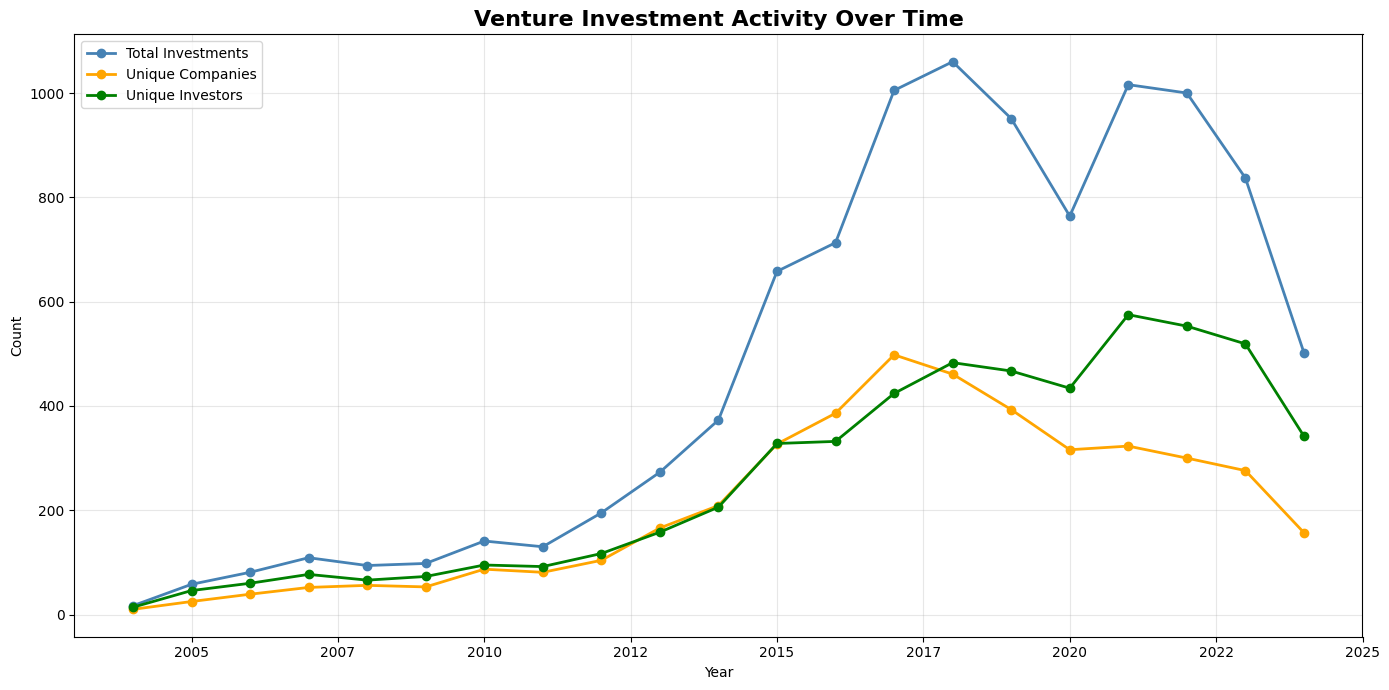

In [11]:
print("\nTEMPORAL ANALYSIS: Investment Activity Evolution")
print("="*60)

# Filter data for analysis period
analysis_data = investments_clean[
      (investments_clean['announced_year'] >= min_year) & 
      (investments_clean['announced_year'] <= max_year)
].copy()

# Yearly investment statistics
yearly_stats = analysis_data.groupby('announced_year').agg(
    unique_investors=('investor_uuid', 'nunique'),
    unique_companies=('org_uuid', 'nunique'),
    total_investments=('org_uuid', 'count'),
    total_funding_sum=('raised_amount_usd', 'sum'),
    mean_funding=('raised_amount_usd', 'mean'),
    median_funding=('raised_amount_usd', 'median')
).round(2)

# Flatten column names
yearly_stats.columns = ['unique_investors', 'unique_companies', 'total_investments', 
                                 'total_funding_sum', 'mean_funding', 'median_funding']
yearly_stats = yearly_stats.reset_index()

# Create comprehensive temporal visualization
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(yearly_stats['announced_year'], yearly_stats['total_investments'], 
  'o-', linewidth=2, markersize=6, color='steelblue', label='Total Investments')
ax.plot(yearly_stats['announced_year'], yearly_stats['unique_companies'], 
  'o-', linewidth=2, markersize=6, color='orange', label='Unique Companies')
ax.plot(yearly_stats['announced_year'], yearly_stats['unique_investors'], 
  'o-', linewidth=2, markersize=6, color='green', label='Unique Investors')
ax.set_title('Venture Investment Activity Over Time', fontweight='bold', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'vc_investment_activity_over_time.png'), 
      dpi=300, bbox_inches='tight')
plt.show()


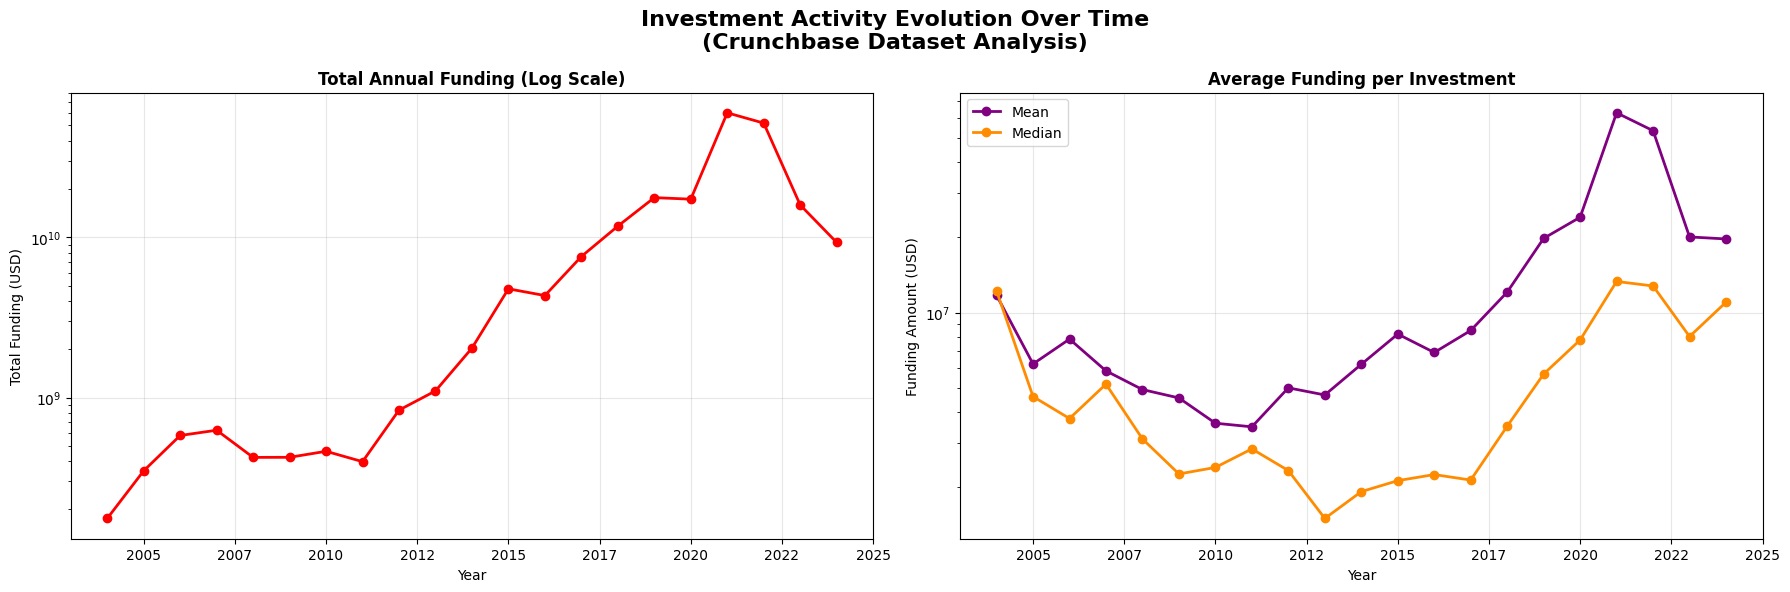


Temporal Analysis Summary (2004-2024):
Peak investment year: 2018 (1,060 investments)
Peak funding year: 2021 ($59936003592)
Most active year (investors): 2021 (575 investors)

Growth from 2004 to 2024:
Total investments: 2852.9%
Unique investors: 2342.9%


In [12]:
# Create comprehensive temporal visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Investment Activity Evolution Over Time\n(Crunchbase Dataset Analysis)', 
                   fontsize=16, fontweight='bold', y=0.98)

# Plot 3: Funding amounts over time (log scale)
ax3 = axes[0]
ax3.plot(yearly_stats['announced_year'], yearly_stats['total_funding_sum'], 
             'o-', linewidth=2, markersize=6, color='red', label='Total Funding')
ax3.set_title('Total Annual Funding (Log Scale)', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Total Funding (USD)')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
# Format x-axis to show integers only
ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

# Plot 4: Average funding per investment
ax4 = axes[1]
ax4.plot(yearly_stats['announced_year'], yearly_stats['mean_funding'], 
             'o-', linewidth=2, markersize=6, color='purple', label='Mean')
ax4.plot(yearly_stats['announced_year'], yearly_stats['median_funding'], 
             'o-', linewidth=2, markersize=6, color='darkorange', label='Median')
ax4.set_title('Average Funding per Investment', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Funding Amount (USD)')
ax4.set_yscale('log')
ax4.legend()
ax4.grid(True, alpha=0.3)
# Format x-axis to show integers only
ax4.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'investment_funding_temporal_evolution.png'), 
                  dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nTemporal Analysis Summary ({min_year}-{max_year}):")
print(f"Peak investment year: {yearly_stats.loc[yearly_stats['total_investments'].idxmax(), 'announced_year']} "
        f"({yearly_stats['total_investments'].max():,} investments)")
print(f"Peak funding year: {yearly_stats.loc[yearly_stats['total_funding_sum'].idxmax(), 'announced_year']} "
        f"(${yearly_stats['total_funding_sum'].max():.0f})")
print(f"Most active year (investors): {yearly_stats.loc[yearly_stats['unique_investors'].idxmax(), 'announced_year']} "
        f"({yearly_stats['unique_investors'].max():,} investors)")

# Growth rates
total_investments_growth = ((yearly_stats['total_investments'].iloc[-1] / yearly_stats['total_investments'].iloc[0]) - 1) * 100
unique_investors_growth = ((yearly_stats['unique_investors'].iloc[-1] / yearly_stats['unique_investors'].iloc[0]) - 1) * 100
print(f"\nGrowth from {min_year} to {max_year}:")
print(f"Total investments: {total_investments_growth:.1f}%")
print(f"Unique investors: {unique_investors_growth:.1f}%")

#### Investment Stage


INVESTMENT STAGE DISTRIBUTION ANALYSIS
Investment Type Distribution:
------------------------------
  series_unknown :  2,653 ( 26.3%)
  series_a       :  1,953 ( 19.4%)
  seed           :  1,930 ( 19.2%)
  series_b       :  1,344 ( 13.3%)
  series_c       :    594 (  5.9%)
  grant          :    288 (  2.9%)
  private_equity :    261 (  2.6%)
  pre_seed       :    246 (  2.4%)
  series_d       :    205 (  2.0%)
  non_equity_assistance:    153 (  1.5%)
  angel          :     95 (  0.9%)
  series_e       :     78 (  0.8%)
  convertible_note:     64 (  0.6%)
  series_f       :     40 (  0.4%)
  equity_crowdfunding:     39 (  0.4%)
  undisclosed    :     38 (  0.4%)
  corporate_round:     35 (  0.3%)
  secondary_market:     22 (  0.2%)
  series_g       :     14 (  0.1%)
  series_h       :     10 (  0.1%)
  initial_coin_offering:      6 (  0.1%)
  series_i       :      6 (  0.1%)
  product_crowdfunding:      1 (  0.0%)


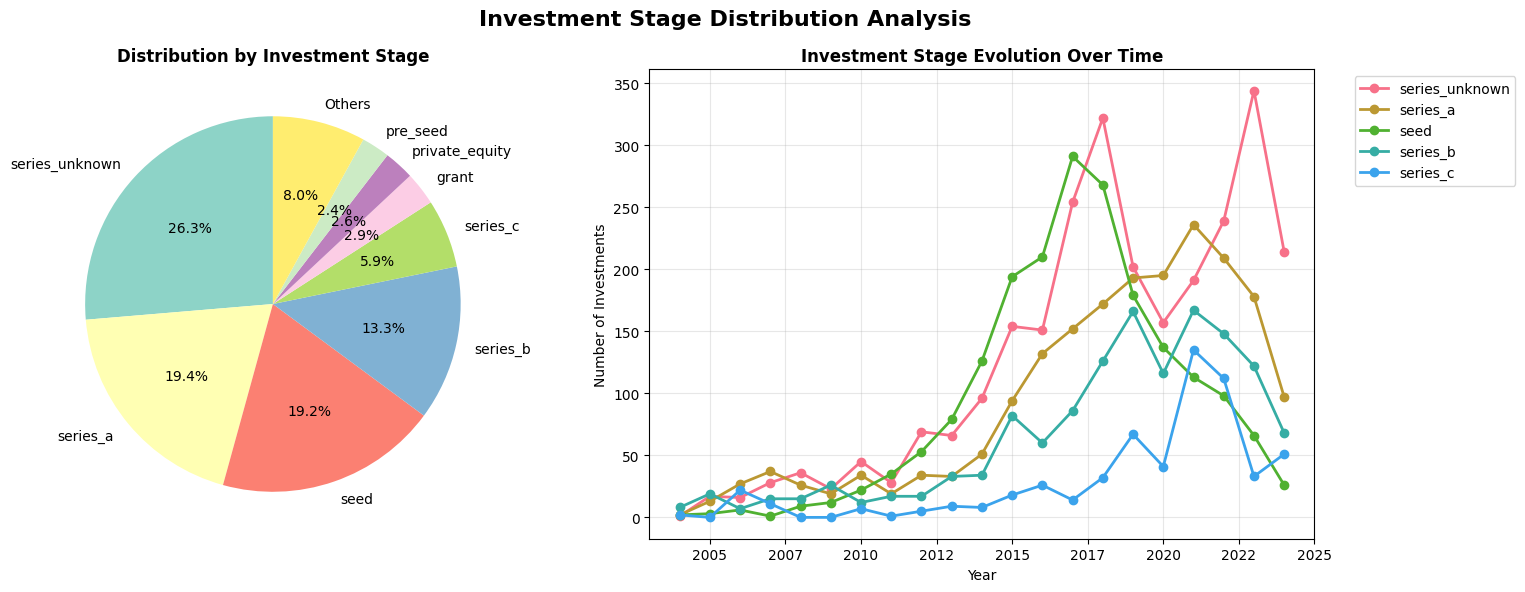


Early vs Late Stage Classification:
-----------------------------------
  Early-stage (angel to series_a):  4,224 ( 41.9%)
  Late-stage (series_b+):           2,291 ( 22.7%)
  Other stages:                     3,560 ( 35.3%)


In [13]:
print("\nINVESTMENT STAGE DISTRIBUTION ANALYSIS")
print("="*60)

# Investment type distribution
if 'investment_type' in analysis_data.columns:
    stage_counts = analysis_data['investment_type'].value_counts()
    stage_pct = (stage_counts / len(analysis_data)) * 100
    
    print("Investment Type Distribution:")
    print("-" * 30)
    for stage, count in stage_counts.items():
        pct = (count / len(analysis_data)) * 100
        print(f"  {stage:<15}: {count:>6,} ({pct:>5.1f}%)")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Investment Stage Distribution Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Investment type distribution (pie chart)
    ax1 = axes[0]
    top_stages = stage_counts.head(8)  # Top 8 stages
    other_count = stage_counts.iloc[8:].sum() if len(stage_counts) > 8 else 0
    
    if other_count > 0:
        plot_data = pd.concat([top_stages, pd.Series({'Others': other_count})])
    else:
        plot_data = top_stages
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
    wedges, texts, autotexts = ax1.pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%',
                                       colors=colors, startangle=90)
    ax1.set_title('Distribution by Investment Stage', fontweight='bold')
    
    # Plot 2: Stage evolution over time
    ax2 = axes[1]
    stage_evolution_sum_inv = analysis_data.groupby(['announced_year', 'investment_type']).size().unstack(fill_value=0)
    
    # Select top 5 most common stages for clarity
    top_5_stages = stage_counts.head(5).index
    stage_evolution_sum_inv_top = stage_evolution_sum_inv[top_5_stages]
    
    for stage in top_5_stages:
        ax2.plot(stage_evolution_sum_inv_top.index, stage_evolution_sum_inv_top[stage], 
                marker='o', linewidth=2, label=stage)
    
    ax2.set_title('Investment Stage Evolution Over Time', fontweight='bold')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Number of Investments')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'investment_stage_distribution.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Early vs Late stage classification
    early_stages_set = {'angel', 'pre_seed', 'seed', 'series_a'}
    late_stages_set = {'series_b', 'series_c', 'series_d', 'series_e', 'series_f', 'series_g', 'series_h', 'series_i'}
    
    early_count = analysis_data[analysis_data['investment_type'].isin(early_stages_set)].shape[0]
    late_count = analysis_data[analysis_data['investment_type'].isin(late_stages_set)].shape[0]
    other_count = len(analysis_data) - early_count - late_count
    
    early_pct = (early_count / len(analysis_data)) * 100
    late_pct = (late_count / len(analysis_data)) * 100
    other_pct = (other_count / len(analysis_data)) * 100
    
    print(f"\nEarly vs Late Stage Classification:")
    print("-" * 35)
    print(f"  Early-stage (angel to series_a): {early_count:>6,} ({early_pct:>5.1f}%)")
    print(f"  Late-stage (series_b+):          {late_count:>6,} ({late_pct:>5.1f}%)")
    print(f"  Other stages:                    {other_count:>6,} ({other_pct:>5.1f}%)")
    
else:
    print("Investment type data not available in dataset")

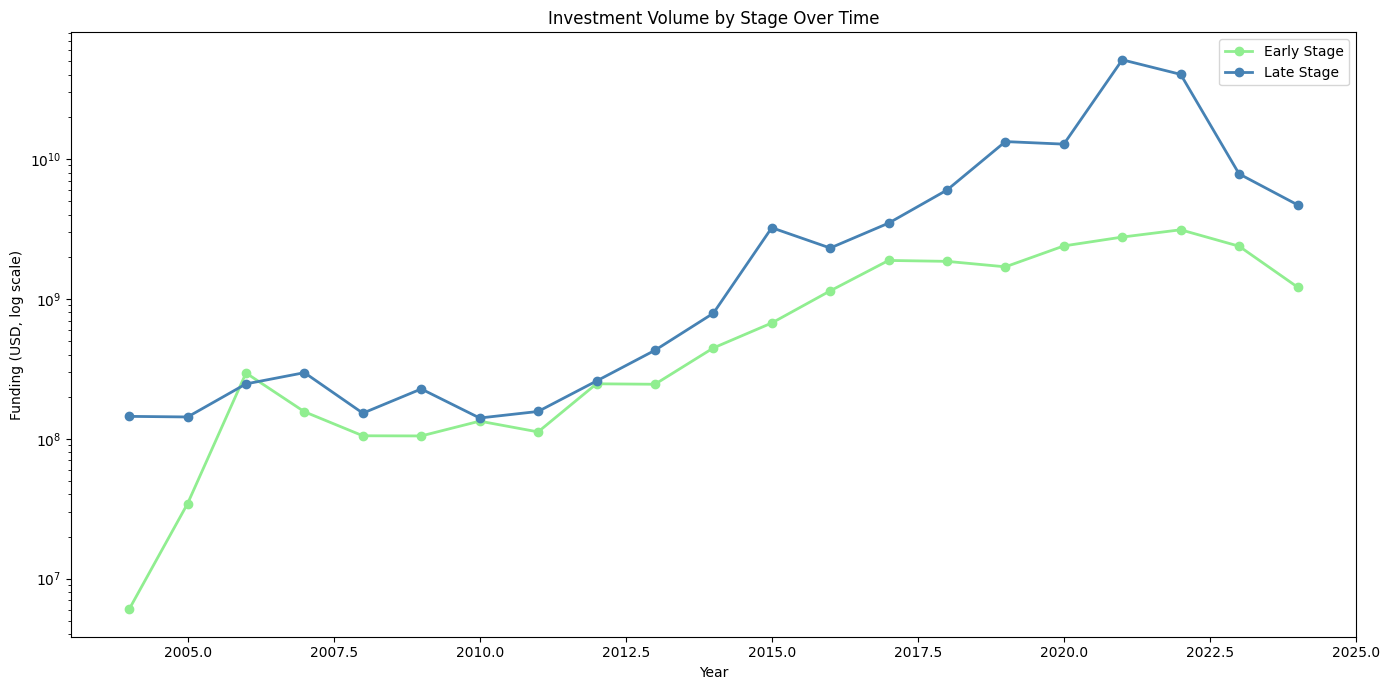

Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Early stage funding per year:
announced_year
2004    6.047988e+06
2005    3.441277e+07
2006    2.951146e+08
2007    1.559673e+08
2008    1.050687e+08
2009    1.047849e+08
2010    1.336670e+08
2011    1.119818e+08
2012    2.471800e+08
2013    2.452803e+08
2014    4.457535e+08
2015    6.723966e+08
2016    1.140546e+09
2017    1.881904e+09
2018    1.853815e+09
2019    1.694362e+09
2020    2.389820e+09
2021    2.765128e+09
2022    3.116973e+09
2023    2.378179e+09
2024    1.213783e+09
dtype: float64
Late stage funding per year:
announced_year
2004    1.445909e+08
2005    1.431945e+08
2006    2.467524e+08
2007    2.968614e+08
2008    1.524301e+08
2009    2.270798e+08
2010    1.407564e+08
2011    1.567676e+08
2012    2.587419e+08
2013    4.289293e+08
2014    7.890574e+08
2015    3.224913e+09
2016    2.309036e+09
2017    3.477440e+09
2018    5.996087e+09
2019  

In [14]:
stage_evolution_sum_funding = analysis_data.groupby(['announced_year', 'investment_type'])['raised_amount_usd'].sum().unstack(fill_value=0)

# Define early and late stage sets
early_stages_set = {'angel', 'pre_seed', 'seed', 'series_a'}
late_stages_set = {'series_b', 'series_c', 'series_d', 'series_e', 'series_f', 'series_g', 'series_h', 'series_i', 'series_j'}

years = stage_evolution_sum_funding.index.tolist()
early_stage_cols = list(early_stages_set.intersection(stage_evolution_sum_funding.columns))
late_stage_cols = list(late_stages_set.intersection(stage_evolution_sum_funding.columns))

early_counts = stage_evolution_sum_funding[early_stage_cols].sum(axis=1)
late_counts = stage_evolution_sum_funding[late_stage_cols].sum(axis=1)

plt.figure(figsize=(14, 7))
plt.plot(years, early_counts, marker='o', linewidth=2, color='lightgreen', label='Early Stage')
plt.plot(years, late_counts, marker='o', linewidth=2, color='steelblue', label='Late Stage')
plt.xlabel('Year')
plt.ylabel('Funding (USD, log scale)')
plt.title('Investment Volume by Stage Over Time')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'investment_stage_curves_log.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Years:", years)
print("Early stage funding per year:")
print(early_counts)
print("Late stage funding per year:")
print(late_counts)


#### Geographic Distribution


GEOGRAPHIC DISTRIBUTION ANALYSIS
Top 15 Countries by Investment Count:
----------------------------------------
   1. France                   :  7,173 ( 71.2%)
   2. United States            :    949 (  9.4%)
   3. Belgium                  :    409 (  4.1%)
   4. United Kingdom           :    325 (  3.2%)
   5. Germany                  :    170 (  1.7%)
   6. Switzerland              :    138 (  1.4%)
   7. Luxembourg               :    111 (  1.1%)
   8. Netherlands              :     81 (  0.8%)
   9. China                    :     52 (  0.5%)
  10. Singapore                :     48 (  0.5%)
  11. Canada                   :     41 (  0.4%)
  12. Italy                    :     33 (  0.3%)
  13. Spain                    :     31 (  0.3%)
  14. Japan                    :     31 (  0.3%)
  15. Finland                  :     23 (  0.2%)

US vs International Breakdown:
-----------------------------------
  United States:    949 (  9.4%)
  International:  9,126 ( 90.6%)


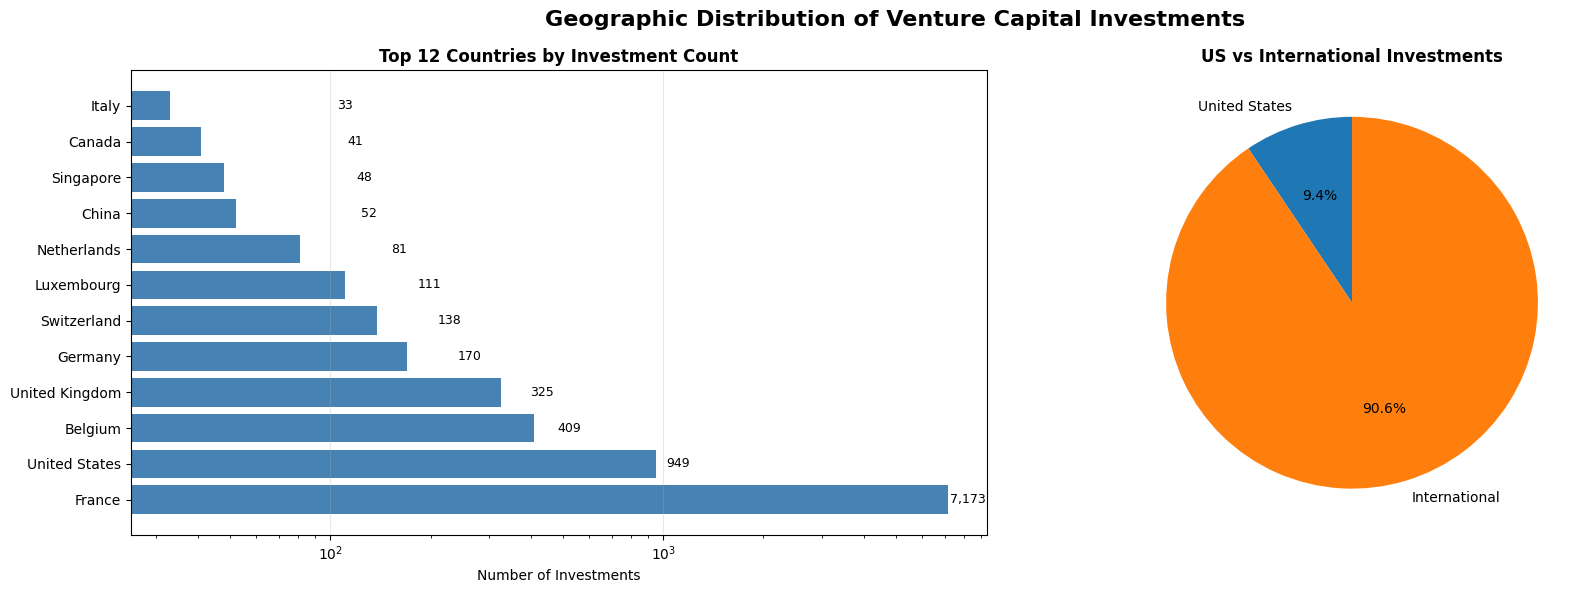

In [15]:
print("\nGEOGRAPHIC DISTRIBUTION ANALYSIS")
print("="*60)

# Country analysis
if 'investor_country' in analysis_data.columns:
    country_counts = analysis_data['investor_country'].value_counts()
    
    print("Top 15 Countries by Investment Count:")
    print("-" * 40)
    for i, (country, count) in enumerate(country_counts.head(15).items()):
        pct = (count / len(analysis_data)) * 100
        print(f"  {i+1:2d}. {country:<25}: {count:>6,} ({pct:>5.1f}%)")
    
    # US vs International analysis
    us_count = analysis_data[analysis_data['investor_country'] == 'United States'].shape[0]
    intl_count = len(analysis_data) - us_count
    us_pct = (us_count / len(analysis_data)) * 100
    intl_pct = (intl_count / len(analysis_data)) * 100
    
    print(f"\nUS vs International Breakdown:")
    print("-" * 35)
    print(f"  United States: {us_count:>6,} ({us_pct:>5.1f}%)")
    print(f"  International: {intl_count:>6,} ({intl_pct:>5.1f}%)")

# Create geographic visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Geographic Distribution of Venture Capital Investments', 
             fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Top countries
ax1 = axes[0]
top_countries = country_counts.head(12)
bars1 = ax1.barh(range(len(top_countries)), top_countries.values, color='steelblue')
ax1.set_yticks(range(len(top_countries)))
ax1.set_yticklabels([country[:20] + '...' if len(country) > 20 else country 
                     for country in top_countries.index])
ax1.set_xlabel('Number of Investments')
ax1.set_title('Top 12 Countries by Investment Count', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xscale('log')

# Add value labels on bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.01*max(top_countries.values), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontsize=9)

# Plot 2: US vs International pie chart
ax2 = axes[1]
us_intl_data = pd.Series({'United States': us_count, 'International': intl_count})
colors = ['#1f77b4', '#ff7f0e']
wedges, texts, autotexts = ax2.pie(us_intl_data.values, labels=us_intl_data.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('US vs International Investments', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'geographic_distribution_country_analysis.png'), 
            dpi=300, bbox_inches='tight')
plt.show()


Top 10 US Regions by Investment Count:
---------------------------------------------
   1. California               :    388 ( 40.9%)
   2. New York                 :    268 ( 28.2%)
   3. Massachusetts            :     75 (  7.9%)
   4. New Jersey               :     32 (  3.4%)
   5. Colorado                 :     28 (  3.0%)
   6. District of Columbia     :     16 (  1.7%)
   7. Georgia                  :     15 (  1.6%)
   8. Illinois                 :     14 (  1.5%)
   9. Connecticut              :     13 (  1.4%)
  10. Florida                  :     12 (  1.3%)

California vs Other US Regions:
-----------------------------------
  California:        388 ( 40.9%)
  Other US:          561 ( 59.1%)


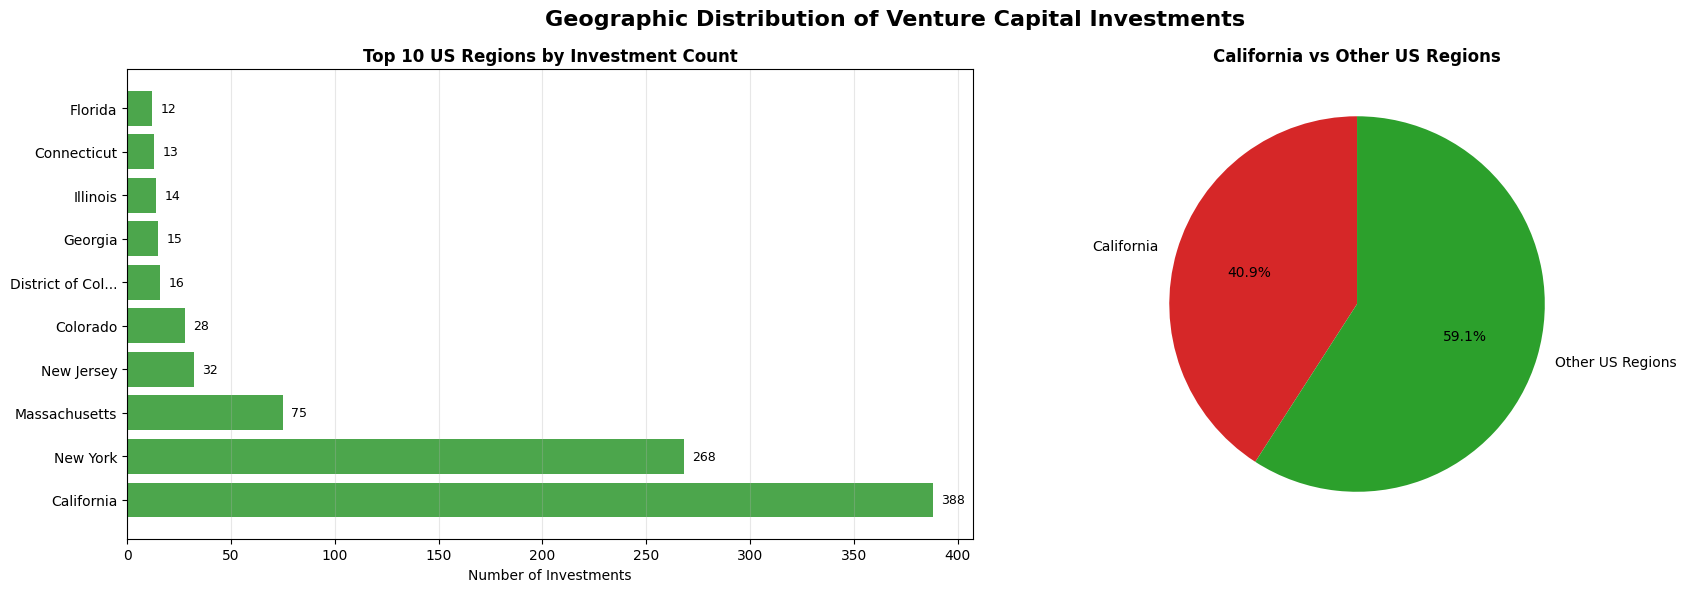

In [16]:
# Region analysis (for US investors)
us_data = analysis_data[analysis_data['investor_country'] == 'United States']
if len(us_data) > 0:
    region_counts = us_data['investor_region'].value_counts()
    
    print(f"\nTop 10 US Regions by Investment Count:")
    print("-" * 45)
    for i, (region, count) in enumerate(region_counts.head(10).items()):
        pct = (count / len(us_data)) * 100
        print(f"  {i+1:2d}. {region:<25}: {count:>6,} ({pct:>5.1f}%)")
    
    # California analysis
    ca_count = us_data[us_data['investor_region'] == 'California'].shape[0]
    other_us_count = len(us_data) - ca_count
    ca_pct = (ca_count / len(us_data)) * 100
    other_us_pct = (other_us_count / len(us_data)) * 100
    
    print(f"\nCalifornia vs Other US Regions:")
    print("-" * 35)
    print(f"  California:     {ca_count:>6,} ({ca_pct:>5.1f}%)")
    print(f"  Other US:       {other_us_count:>6,} ({other_us_pct:>5.1f}%)")

# Create geographic visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Geographic Distribution of Venture Capital Investments', 
             fontsize=16, fontweight='bold', y=0.98)

# Plot 3: Top US regions
ax3 = axes[0]
top_regions = region_counts.head(10)
bars3 = ax3.barh(range(len(top_regions)), top_regions.values, color='green', alpha=0.7)
ax3.set_yticks(range(len(top_regions)))
ax3.set_yticklabels([region[:15] + '...' if len(region) > 15 else region 
                        for region in top_regions.index])
ax3.set_xlabel('Number of Investments')
ax3.set_title('Top 10 US Regions by Investment Count', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax3.text(width + 0.01*max(top_regions.values), bar.get_y() + bar.get_height()/2, 
                f'{int(width):,}', ha='left', va='center', fontsize=9)

# Plot 4: California vs Other US pie chart
ax4 = axes[1]
ca_other_data = pd.Series({'California': ca_count, 'Other US Regions': other_us_count})
colors = ['#d62728', '#2ca02c']
wedges, texts, autotexts = ax4.pie(ca_other_data.values, labels=ca_other_data.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax4.set_title('California vs Other US Regions', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'geographic_distribution_region_analysis.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

#### Funding Characteristics


FUNDING CHARACTERISTICS ANALYSIS
Funding Amount Statistics:
------------------------------
  Count: 10,075
  Mean: $70,238,964
  Median: $12,562,451
  Std: $164,135,168
  Min: $80,697
  Max: $1,212,000,000
  25th percentile: $3,378,206
  75th percentile: $50,331,104
  95th percentile: $443,546,071
  99th percentile: $846,835,229

Funding Statistics by Investment Stage:
--------------------------------------------------
Stage           Count    Mean         Median       Std         
--------------------------------------------------
series_f        40       $785,888,857 $728,555,360 $274,197,394
series_e        78       $693,196,911 $751,564,900 $324,852,766
series_h        10       $642,604,720 $642,604,720 $0          
series_i        6        $642,604,720 $642,604,720 $0          
series_g        14       $571,512,345 $642,604,720 $98,980,949 
series_d        205      $406,590,543 $319,987,263 $331,061,702
series_c        594      $230,599,059 $137,912,490 $238,786,688
secondary_mar

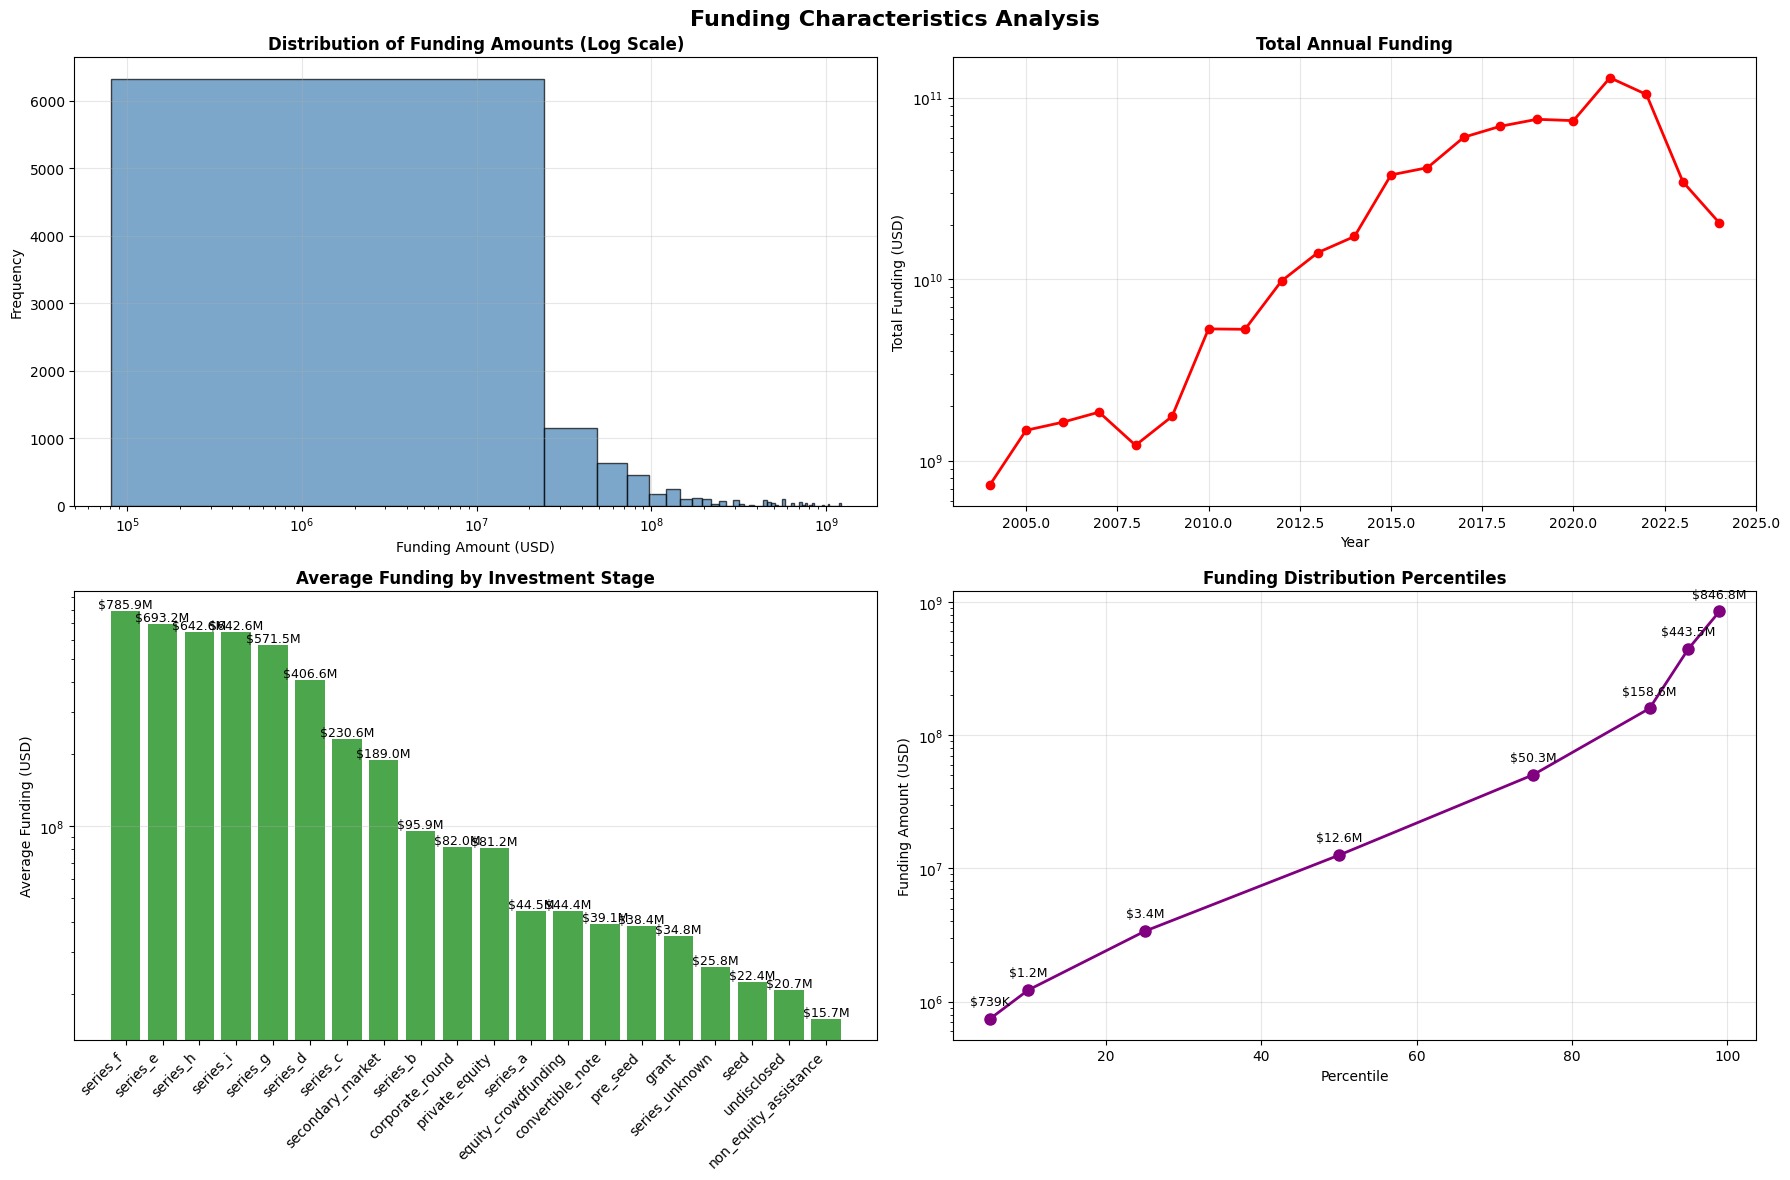


Funding Concentration Analysis:
-----------------------------------
  Top 1% of rounds: 16.6% of total funding
  Top 5% of rounds: 51.3% of total funding
  Top 10% of rounds: 68.5% of total funding


In [17]:
print("\nFUNDING CHARACTERISTICS ANALYSIS")
print("="*60)

# Funding amount analysis
if 'total_funding_usd' in analysis_data.columns:
    funding_data = analysis_data['total_funding_usd'].dropna()
    
    print("Funding Amount Statistics:")
    print("-" * 30)
    print(f"  Count: {len(funding_data):,}")
    print(f"  Mean: ${funding_data.mean():,.0f}")
    print(f"  Median: ${funding_data.median():,.0f}")
    print(f"  Std: ${funding_data.std():,.0f}")
    print(f"  Min: ${funding_data.min():,.0f}")
    print(f"  Max: ${funding_data.max():,.0f}")
    print(f"  25th percentile: ${funding_data.quantile(0.25):,.0f}")
    print(f"  75th percentile: ${funding_data.quantile(0.75):,.0f}")
    print(f"  95th percentile: ${funding_data.quantile(0.95):,.0f}")
    print(f"  99th percentile: ${funding_data.quantile(0.99):,.0f}")
    
    # Funding by investment stage
    if 'investment_type' in analysis_data.columns:
        funding_by_stage = analysis_data.groupby('investment_type')['total_funding_usd'].agg([
            'count', 'mean', 'median', 'std'
        ]).round(0)
        funding_by_stage.columns = ['Count', 'Mean', 'Median', 'Std']
        funding_by_stage = funding_by_stage.sort_values('Mean', ascending=False)
        
        print(f"\nFunding Statistics by Investment Stage:")
        print("-" * 50)
        print(f"{'Stage':<15} {'Count':<8} {'Mean':<12} {'Median':<12} {'Std':<12}")
        print("-" * 50)
        for stage, row in funding_by_stage.head(10).iterrows():
            print(f"{stage:<15} {row['Count']:<8.0f} ${row['Mean']:<11,.0f} ${row['Median']:<11,.0f} ${row['Std']:<11,.0f}")

# Create funding analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Funding Characteristics Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Funding distribution (log scale histogram)
ax1 = axes[0, 0]
funding_clean = funding_data[funding_data > 0]  # Remove zeros for log scale
ax1.hist(funding_clean, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Funding Amount (USD)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Funding Amounts (Log Scale)', fontweight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

# Plot 2: Funding by year
ax2 = axes[0, 1]
yearly_funding = analysis_data.groupby('announced_year')['total_funding_usd'].agg(['sum', 'mean', 'count'])
ax2.plot(yearly_funding.index, yearly_funding['sum'], 'o-', linewidth=2, markersize=6, color='red')
ax2.set_xlabel('Year')
ax2.set_ylabel('Total Funding (USD)')
ax2.set_title('Total Annual Funding', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Plot 3: Average funding by investment stage
if 'investment_type' in analysis_data.columns:
    ax3 = axes[1, 0]
    stage_avg_funding = funding_by_stage.head(20)  # Top 8 stages
    bars3 = ax3.bar(range(len(stage_avg_funding)), stage_avg_funding['Mean'], 
                    color='green', alpha=0.7)
    ax3.set_xticks(range(len(stage_avg_funding)))
    ax3.set_xticklabels(stage_avg_funding.index, rotation=45, ha='right')
    ax3.set_ylabel('Average Funding (USD)')
    ax3.set_title('Average Funding by Investment Stage', fontweight='bold')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'${height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# Plot 4: Funding distribution percentiles
ax4 = axes[1, 1]
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
percentile_values = [funding_data.quantile(p/100) for p in percentiles]
ax4.plot(percentiles, percentile_values, 'o-', linewidth=2, markersize=8, color='purple')
ax4.set_xlabel('Percentile')
ax4.set_ylabel('Funding Amount (USD)')
ax4.set_title('Funding Distribution Percentiles', fontweight='bold')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3)

# Add value labels
for i, (p, v) in enumerate(zip(percentiles, percentile_values)):
    if v > 1e6:
        label = f'${v/1e6:.1f}M'
    elif v > 1e3:
        label = f'${v/1e3:.0f}K'
    else:
        label = f'${v:.0f}'
    ax4.annotate(label, (p, v), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'funding_characteristics_analysis.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

# Funding concentration analysis
if len(funding_data) > 0:
    total_funding = funding_data.sum()
    top_1_pct_threshold = funding_data.quantile(0.99)
    top_5_pct_threshold = funding_data.quantile(0.95)
    top_10_pct_threshold = funding_data.quantile(0.90)
    
    top_1_pct_funding = funding_data[funding_data >= top_1_pct_threshold].sum()
    top_5_pct_funding = funding_data[funding_data >= top_5_pct_threshold].sum()
    top_10_pct_funding = funding_data[funding_data >= top_10_pct_threshold].sum()
    
    print(f"\nFunding Concentration Analysis:")
    print("-" * 35)
    print(f"  Top 1% of rounds: {(top_1_pct_funding/total_funding)*100:.1f}% of total funding")
    print(f"  Top 5% of rounds: {(top_5_pct_funding/total_funding)*100:.1f}% of total funding")
    print(f"  Top 10% of rounds: {(top_10_pct_funding/total_funding)*100:.1f}% of total funding")

#### Sector


SECTORAL/INDUSTRY DISTRIBUTION ANALYSIS
Top 20 Industry Categories by Investment Count:
--------------------------------------------------
   1. Health Care                   :  1,149 ( 11.4%)
   2. Biotechnology                 :    611 (  6.1%)
   3. Financial Services            :    597 (  5.9%)
   4. Transportation                :    576 (  5.7%)
   5. Commerce and Shopping         :    544 (  5.4%)
   6. Hardware                      :    472 (  4.7%)
   7. Science and Engineering       :    434 (  4.3%)
   8. Information Technology        :    432 (  4.3%)
   9. Manufacturing                 :    386 (  3.8%)
  10. Energy                        :    340 (  3.4%)
  11. Data and Analytics            :    307 (  3.0%)
  12. Artificial Intelligence       :    306 (  3.0%)
  13. Internet Services             :    295 (  2.9%)
  14. Real Estate                   :    270 (  2.7%)
  15. Travel and Tourism            :    229 (  2.3%)
  16. Privacy and Security          :    229 (  2.

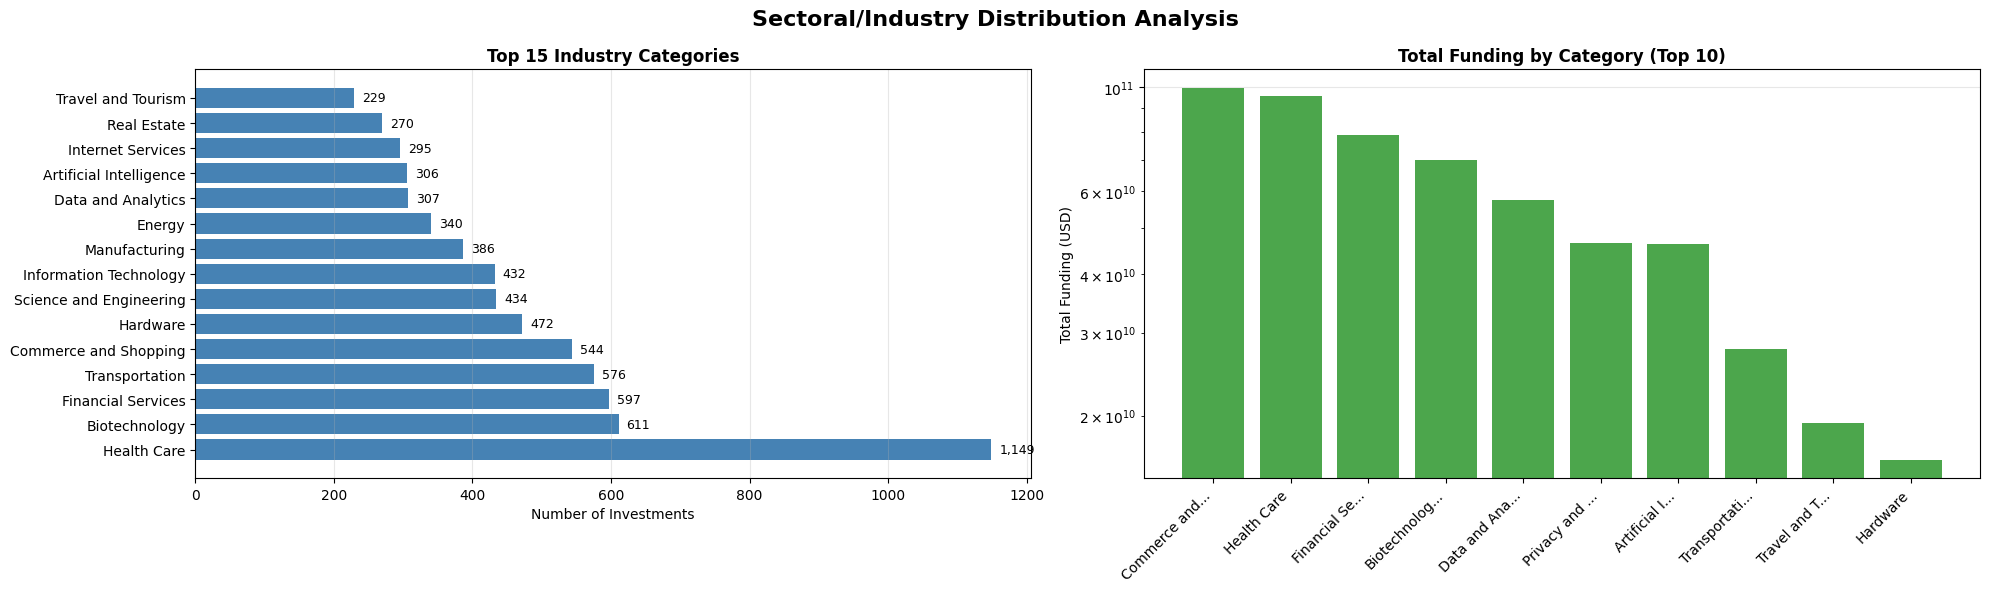


Technology vs Non-Technology Classification:
---------------------------------------------
  Technology-related:  2,081 ( 20.7%)
  Non-technology:      7,994 ( 79.3%)
  Technology categories identified: 6


In [18]:
print("\nSECTORAL/INDUSTRY DISTRIBUTION ANALYSIS")
print("="*60)

# Industry category analysis
if 'category' in analysis_data.columns:
    category_counts = analysis_data['category'].value_counts()
    
    print("Top 20 Industry Categories by Investment Count:")
    print("-" * 50)
    for i, (category, count) in enumerate(category_counts.head(20).items()):
        pct = (count / len(analysis_data)) * 100
        print(f"  {i+1:2d}. {category:<30}: {count:>6,} ({pct:>5.1f}%)")
    
    # Industry concentration analysis
    top_5_categories = category_counts.head(5)
    top_10_categories = category_counts.head(10)
    top_20_categories = category_counts.head(20)
    
    top_5_pct = (top_5_categories.sum() / len(analysis_data)) * 100
    top_10_pct = (top_10_categories.sum() / len(analysis_data)) * 100
    top_20_pct = (top_20_categories.sum() / len(analysis_data)) * 100
    
    print(f"\nIndustry Concentration:")
    print("-" * 25)
    print(f"  Top 5 categories:  {top_5_pct:.1f}% of total investments")
    print(f"  Top 10 categories: {top_10_pct:.1f}% of total investments")
    print(f"  Top 20 categories: {top_20_pct:.1f}% of total investments")
    print(f"  Total unique categories: {len(category_counts)}")

# Create sectoral visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Sectoral/Industry Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Top categories bar chart
ax1 = axes[0]
top_categories_plot = category_counts.head(15)
bars1 = ax1.barh(range(len(top_categories_plot)), top_categories_plot.values, color='steelblue')
ax1.set_yticks(range(len(top_categories_plot)))
ax1.set_yticklabels([cat[:25] + '...' if len(cat) > 25 else cat 
                     for cat in top_categories_plot.index])
ax1.set_xlabel('Number of Investments')
ax1.set_title('Top 15 Industry Categories', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.01*max(top_categories_plot.values), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontsize=9)

# Plot 4: Funding by category (top 10)
if 'total_funding_usd' in analysis_data.columns:
    ax4 = axes[1]
    funding_by_category = analysis_data.groupby('category')['total_funding_usd'].agg(['sum', 'mean', 'count'])
    funding_by_category = funding_by_category.sort_values('sum', ascending=False).head(10)
    
    bars4 = ax4.bar(range(len(funding_by_category)), funding_by_category['sum'], 
                    color='green', alpha=0.7)
    ax4.set_xticks(range(len(funding_by_category)))
    ax4.set_xticklabels([cat[:12] + '...' if len(cat) > 12 else cat 
                         for cat in funding_by_category.index], 
                        rotation=45, ha='right')
    ax4.set_ylabel('Total Funding (USD)')
    ax4.set_title('Total Funding by Category (Top 10)', fontweight='bold')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'sectoral_industry_analysis_bars.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

# Technology vs non-technology classification
if 'category' in analysis_data.columns:
    tech_keywords = ['software', 'technology', 'internet', 'mobile', 'artificial intelligence', 
                     'information technology', 'fintech', 'biotech', 'healthtech', 'edtech', 
                     'proptech', 'blockchain', 'cryptocurrency', 'cyber', 'data']
    
    tech_categories = []
    for cat in category_counts.index:
        if any(keyword.lower() in cat.lower() for keyword in tech_keywords):
            tech_categories.append(cat)
    
    tech_count = analysis_data[analysis_data['category'].isin(tech_categories)].shape[0]
    non_tech_count = len(analysis_data) - tech_count
    tech_pct = (tech_count / len(analysis_data)) * 100
    non_tech_pct = (non_tech_count / len(analysis_data)) * 100
    
    print(f"\nTechnology vs Non-Technology Classification:")
    print("-" * 45)
    print(f"  Technology-related: {tech_count:>6,} ({tech_pct:>5.1f}%)")
    print(f"  Non-technology:     {non_tech_count:>6,} ({non_tech_pct:>5.1f}%)")
    print(f"  Technology categories identified: {len(tech_categories)}")

else:
    print("Category data not available in dataset")

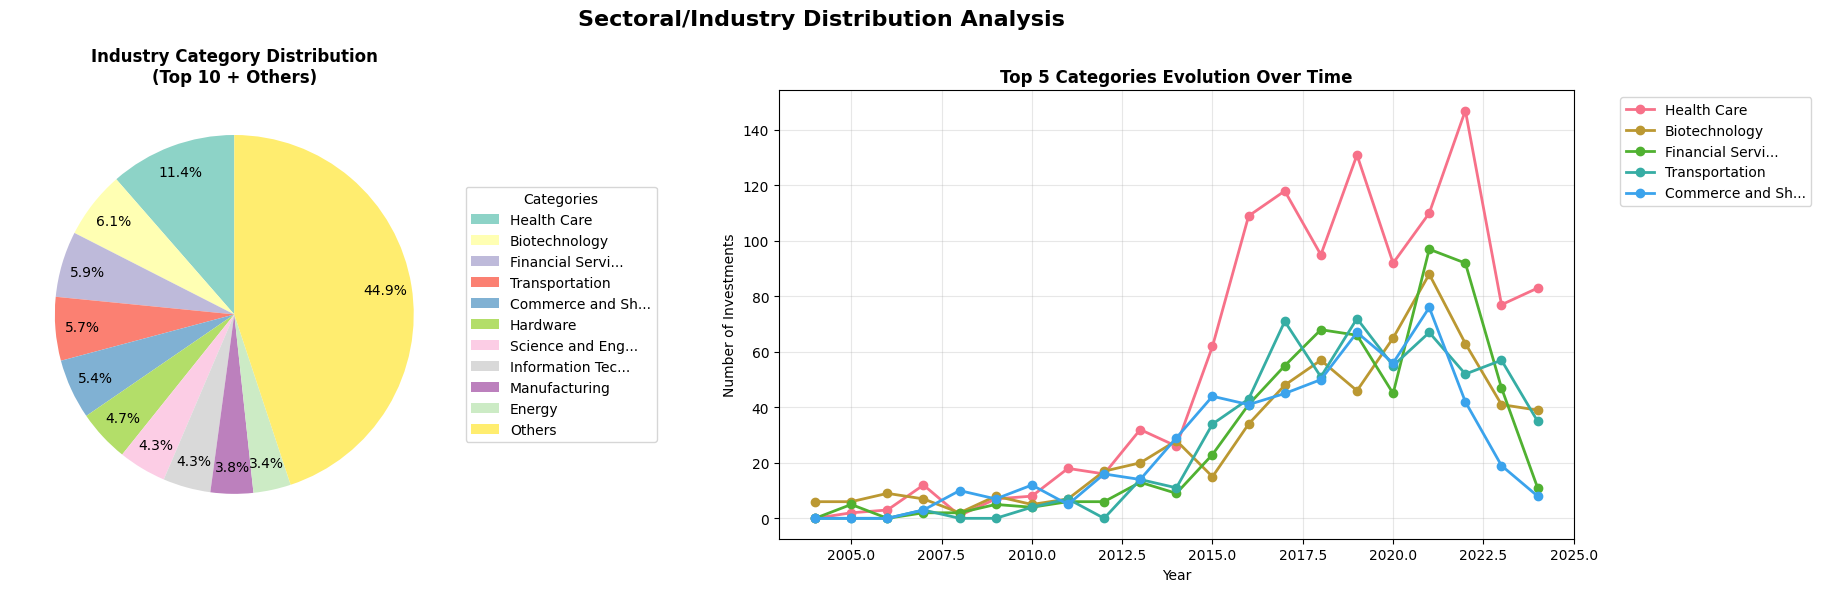

In [19]:
# Create sectoral visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Sectoral/Industry Distribution Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 2: Category distribution pie chart (top 10 + others)
ax2 = axes[0]
top_10_categories = category_counts.head(10)
other_count = category_counts.iloc[10:].sum()
plot_data = pd.concat([top_10_categories, pd.Series({'Others': other_count})])

colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))

# Custom autopct function to move percentages outward
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%'
    return my_autopct

wedges, texts, autotexts = ax2.pie(
    plot_data.values,
    # labels=[label[:15] + '...' if len(label) > 15 else label for label in plot_data.index],
    autopct=make_autopct(plot_data.values),
    colors=colors,
    startangle=90,
    pctdistance=0.85  # Move percentages outward (default is 0.6)
)

ax2.set_title('Industry Category Distribution\n(Top 10 + Others)', fontweight='bold')

# Move legend outside and add arrows from legend to pie slices

# Place legend on right
legend_labels = [label[:15] + '...' if len(label) > 15 else label for label in plot_data.index]
legend = ax2.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), title='Categories')

# Draw arrows from legend to pie slices

# Plot 3: Category evolution over time (top 5 categories)
if 'announced_year' in analysis_data.columns:
    ax3 = axes[1]
    top_5_cats = category_counts.head(5).index
    category_evolution = analysis_data.groupby(['announced_year', 'category']).size().unstack(fill_value=0)
    
    for cat in top_5_cats:
        if cat in category_evolution.columns:
            ax3.plot(category_evolution.index, category_evolution[cat], 
                    marker='o', linewidth=2, label=cat[:15] + '...' if len(cat) > 15 else cat)
    
    ax3.set_title('Top 5 Categories Evolution Over Time', fontweight='bold')
    ax3.set_xlabel('Year')
    ax3.set_ylabel('Number of Investments')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'sectoral_industry_analysis_trends.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

### Network Characteristics (Classical Model)

Not used in the Thesis


INVESTOR ACTIVITY AND NETWORK CHARACTERISTICS
Investor Activity Statistics:
------------------------------
  Total unique investors: 2,321
  Mean investments per investor: 4.3
  Median investments per investor: 1.0
  Max investments by single investor: 570
  Investors with only 1 investment: 1,291 (55.6%)

Top 20 Most Active Investors:
--------------------------------------------------
Rank Investor UUID                            Investments  Companies 
--------------------------------------------------
1    d420cb3c-c5c2-df2a-63db-4850847570c...   570          444       
2    d1bc5ab8-adde-56aa-5dfc-d69d0377430...   129          112       
3    ae6eb8da-ebb3-42be-9ee6-644a57af875...   128          63        
4    c71a2ce5-aab4-8f6c-8d4d-091fd702af6...   117          74        
5    1d0c86bf-c986-6b40-d757-4d97cdd5d87...   112          103       
6    8cbd9845-c791-b45e-047e-c6385a72dc0...   101          92        
7    7475db43-36a9-414d-f7a9-b92b78bae47...   96           58        

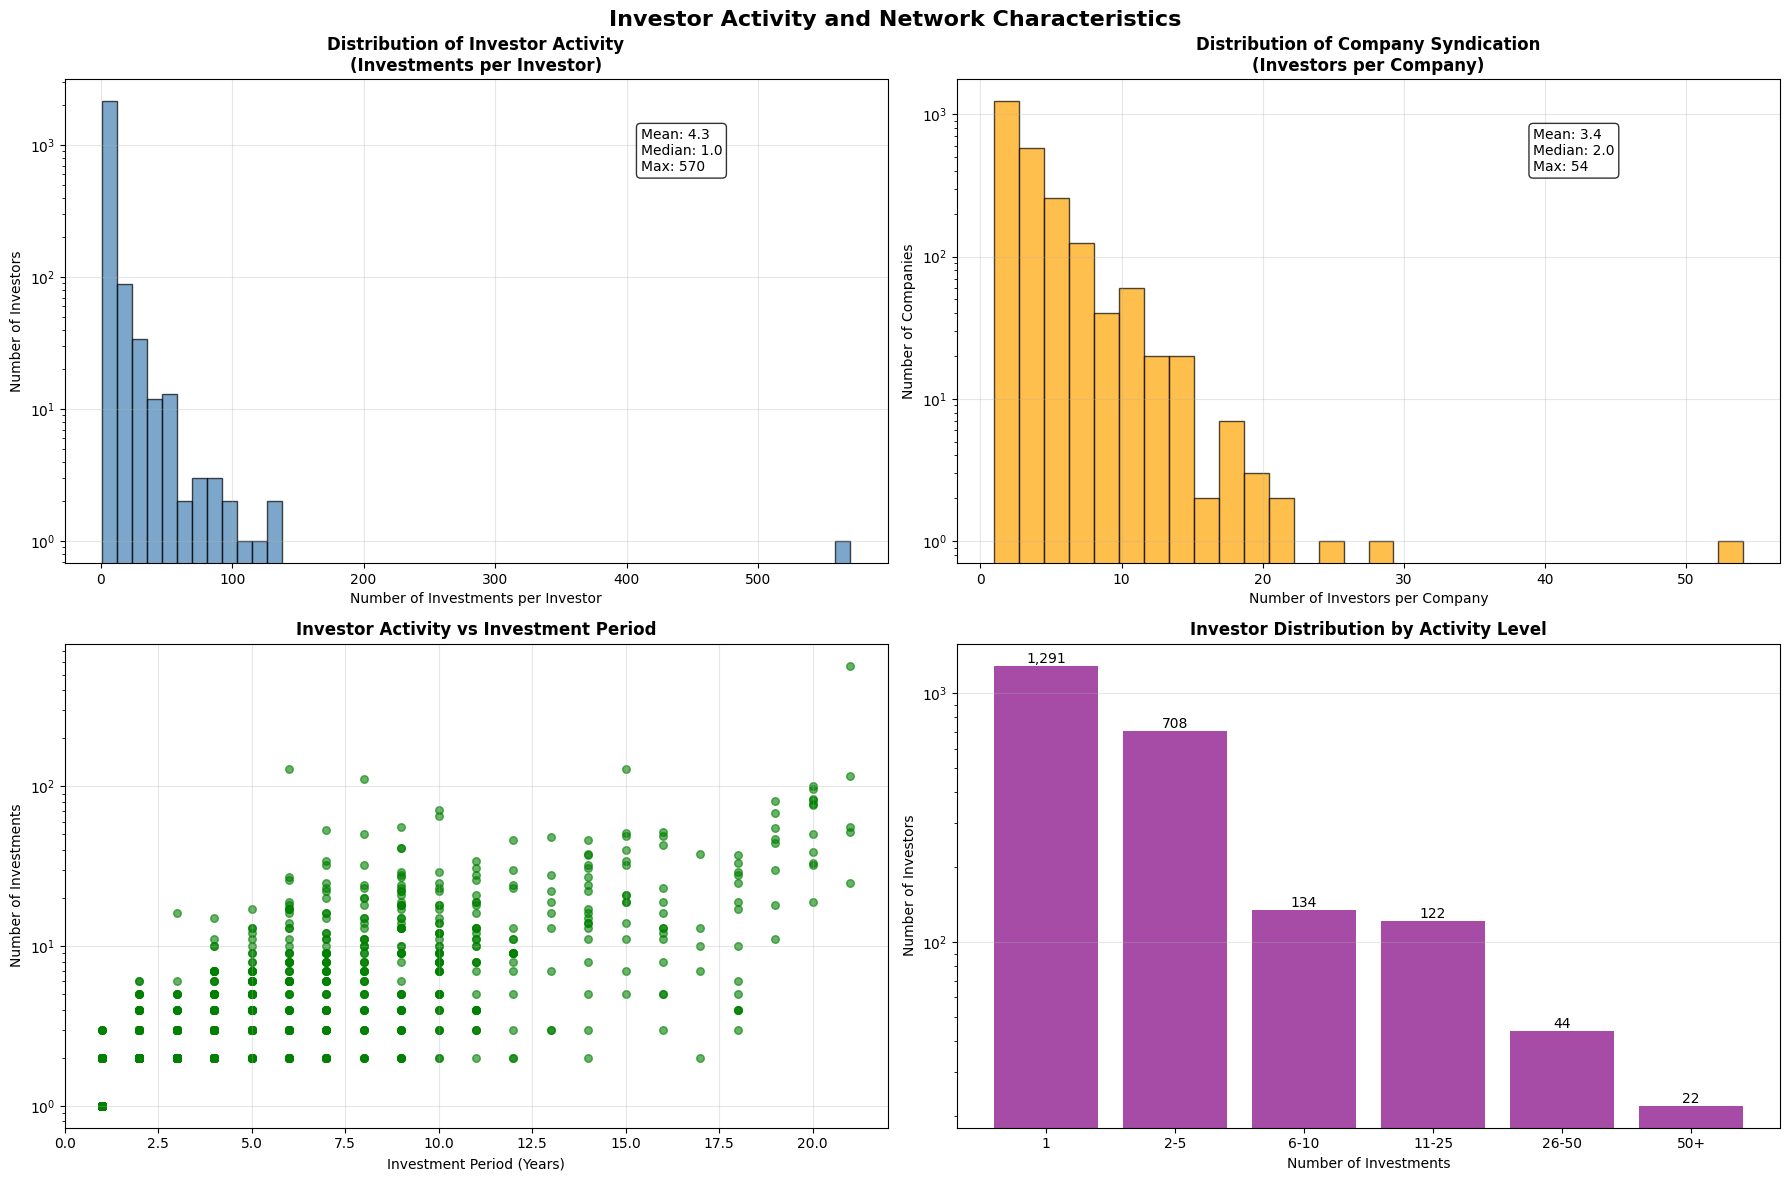


Network Connectivity Analysis:
-----------------------------------
  Companies with syndication: 1,657 (70.5%)
  Highly active investors (top 5%): 120
  Threshold for top 5%: 17 investments
  These investors account for: 4,896 investments (48.6%)


In [20]:
print("\nINVESTOR ACTIVITY AND NETWORK CHARACTERISTICS")
print("="*60)

# Investor activity analysis
investor_activity = analysis_data.groupby('investor_uuid').agg(
    num_investments=('org_uuid', 'count'),                # Number of investments per investor
    unique_companies=('org_uuid', 'nunique'),             # Number of unique companies invested in
    total_funding=('total_funding_usd', 'sum'),           # Total funding
    avg_funding=('total_funding_usd', 'mean'),            # Average funding
    first_year=('announced_year', 'min'),                 # First investment year
    last_year=('announced_year', 'max')                   # Last investment year
).round(2)

# Flatten column names
investor_activity.columns = ['num_investments', 'unique_companies', 'total_funding', 
                           'avg_funding', 'first_year', 'last_year']
investor_activity['investment_period'] = investor_activity['last_year'] - investor_activity['first_year'] + 1
investor_activity = investor_activity.reset_index()

print("Investor Activity Statistics:")
print("-" * 30)
print(f"  Total unique investors: {len(investor_activity):,}")
print(f"  Mean investments per investor: {investor_activity['num_investments'].mean():.1f}")
print(f"  Median investments per investor: {investor_activity['num_investments'].median():.1f}")
print(f"  Max investments by single investor: {investor_activity['num_investments'].max():,}")
print(f"  Investors with only 1 investment: {(investor_activity['num_investments'] == 1).sum():,} "
      f"({(investor_activity['num_investments'] == 1).sum()/len(investor_activity)*100:.1f}%)")

# Most active investors
most_active = investor_activity.nlargest(20, 'num_investments')
print(f"\nTop 20 Most Active Investors:")
print("-" * 50)
print(f"{'Rank':<4} {'Investor UUID':<40} {'Investments':<12} {'Companies':<10}")
print("-" * 50)
for i, (_, row) in enumerate(most_active.iterrows()):
    print(f"{i+1:<4} {row['investor_uuid'][:35] + '...' if len(row['investor_uuid']) > 35 else row['investor_uuid']:<40} "
          f"{row['num_investments']:<12.0f} {row['unique_companies']:<10.0f}")

# Company activity analysis
company_activity = analysis_data.groupby('org_uuid').agg(
    total_investments=('investor_uuid', 'count'),         # Total investments per company
    unique_investors=('investor_uuid', 'nunique'),        # Number of unique investors
    total_funding=('total_funding_usd', 'first'),         # Total funding (assumed same for all records of company)
    first_year=('announced_year', 'min'),                 # First investment year
    last_year=('announced_year', 'max'),                  # Last investment year
    investment_stages=('investment_type', lambda x: list(x.unique())) # Investment stages
).round(2)

# Flatten column names
company_activity.columns = ['total_investments', 'unique_investors', 'total_funding', 
                          'first_year', 'last_year', 'investment_stages']
company_activity['fundraising_period'] = company_activity['last_year'] - company_activity['first_year'] + 1
company_activity['num_stages'] = company_activity['investment_stages'].apply(len)
company_activity = company_activity.reset_index()

print(f"\nCompany Fundraising Statistics:")
print("-" * 35)
print(f"  Total unique companies: {len(company_activity):,}")
print(f"  Mean investors per company: {company_activity['unique_investors'].mean():.1f}")
print(f"  Median investors per company: {company_activity['unique_investors'].median():.1f}")
print(f"  Max investors for single company: {company_activity['unique_investors'].max():,}")
print(f"  Companies with only 1 investor: {(company_activity['unique_investors'] == 1).sum():,} "
      f"({(company_activity['unique_investors'] == 1).sum()/len(company_activity)*100:.1f}%)")

# Create investor activity visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Investor Activity and Network Characteristics', 
             fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Distribution of investments per investor
ax1 = axes[0, 0]
inv_per_investor = investor_activity['num_investments']
ax1.hist(inv_per_investor, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Number of Investments per Investor')
ax1.set_ylabel('Number of Investors')
ax1.set_title('Distribution of Investor Activity\n(Investments per Investor)', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Add statistics text
stats_text = f'Mean: {inv_per_investor.mean():.1f}\nMedian: {inv_per_investor.median():.1f}\nMax: {inv_per_investor.max()}'
ax1.text(0.7, 0.9, stats_text, transform=ax1.transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top')

# Plot 2: Distribution of investors per company
ax2 = axes[0, 1]
inv_per_company = company_activity['unique_investors']
ax2.hist(inv_per_company, bins=30, alpha=0.7, color='orange', edgecolor='black')
ax2.set_xlabel('Number of Investors per Company')
ax2.set_ylabel('Number of Companies')
ax2.set_title('Distribution of Company Syndication\n(Investors per Company)', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Add statistics text
stats_text2 = f'Mean: {inv_per_company.mean():.1f}\nMedian: {inv_per_company.median():.1f}\nMax: {inv_per_company.max()}'
ax2.text(0.7, 0.9, stats_text2, transform=ax2.transAxes, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='top')

# Plot 3: Investment period vs number of investments
ax3 = axes[1, 0]
active_investors = investor_activity[investor_activity['investment_period'] > 0]
scatter = ax3.scatter(active_investors['investment_period'], active_investors['num_investments'], 
                     alpha=0.6, s=30, color='green')
ax3.set_xlabel('Investment Period (Years)')
ax3.set_ylabel('Number of Investments')
ax3.set_title('Investor Activity vs Investment Period', fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)

# Plot 4: Top investor categories by activity level
ax4 = axes[1, 1]
activity_categories = pd.cut(investor_activity['num_investments'], 
                           bins=[0, 1, 5, 10, 25, 50, float('inf')], 
                           labels=['1', '2-5', '6-10', '11-25', '26-50', '50+'])
activity_counts = activity_categories.value_counts()

bars4 = ax4.bar(range(len(activity_counts)), activity_counts.values, 
                color='purple', alpha=0.7)
ax4.set_xticks(range(len(activity_counts)))
ax4.set_xticklabels(activity_counts.index)
ax4.set_xlabel('Number of Investments')
ax4.set_ylabel('Number of Investors')
ax4.set_title('Investor Distribution by Activity Level', fontweight='bold')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'investor_activity_network_characteristics.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

# Network density and connectivity analysis
print(f"\nNetwork Connectivity Analysis:")
print("-" * 35)

# Potential syndication pairs (companies with multiple investors)
syndicated_companies = company_activity[company_activity['unique_investors'] > 1]
print(f"  Companies with syndication: {len(syndicated_companies):,} "
      f"({len(syndicated_companies)/len(company_activity)*100:.1f}%)")

# Highly connected investors (top 5%)
high_activity_threshold = investor_activity['num_investments'].quantile(0.95)
high_activity_investors = investor_activity[investor_activity['num_investments'] >= high_activity_threshold]
print(f"  Highly active investors (top 5%): {len(high_activity_investors):,}")
print(f"  Threshold for top 5%: {high_activity_threshold:.0f} investments")
print(f"  These investors account for: "
      f"{high_activity_investors['num_investments'].sum():,} investments "
      f"({high_activity_investors['num_investments'].sum()/investor_activity['num_investments'].sum()*100:.1f}%)")

## Communities Analysis

### Create bipartite graph

In [21]:
# Create bipartite graph
bipartite_graph = create_bipartite_graph(investments_pairs_clean, 'investor_name_left', 'investor_name_right', None, 'left', 'right')
bipartite_sets = get_bipartite_sets(bipartite_graph)

set_0 = bipartite_sets['set_0']
set_1 = bipartite_sets['set_1']

### Detect communities

In [22]:
G = bipartite_graph.copy()

if CALCULATE_COMMUNITIES or not os.path.exists(communities_file):
    print("Calculating communities using greedy_modularity_communities...")
    communities = list(greedy_modularity_communities(G))
    # Convert communities to a DataFrame for saving
    communities_data = []
    for comm_idx, community in enumerate(communities):
        for node in community:
            communities_data.append({
                'community_id': comm_idx,
                'node': node,
                'community_size': len(community)
            })
    
    communities_df = pd.DataFrame(communities_data)
    
    # Create output directory if it doesn't exist
    os.makedirs(processed_dir, exist_ok=True)
    
    # Save to parquet file
    communities_df.to_csv(communities_file, compression='gzip', index_label='index')
    print(f"Saved {len(communities)} communities to {communities_file}")
else:
    # Load communities from parquet file
    print(f"Loading communities from {communities_file}")
    communities_df = pd.read_csv(communities_file, compression='gzip')
    
    # Reconstruct communities list from DataFrame
    communities = []
    for comm_id in sorted(communities_df['community_id'].unique()):
        community_nodes = communities_df[communities_df['community_id'] == comm_id]['node'].tolist()
        communities.append(set(community_nodes))
    
    print(f"Loaded {len(communities)} communities from csv file")

print(f"Total communities: {len(communities)}")

nodes = communities_df.copy()
nodes['id'] = communities_df['node']
nodes['set'] = nodes['node'].apply(lambda x: 0 if x in set_0 else 1)
nodes.to_csv(nodes_file, index_label='index')

Calculating communities using greedy_modularity_communities...
Saved 24 communities to ../data/processed/fr/communities.csv.gz
Total communities: 24


In [23]:
max_top_communities = 10

top_communities = sorted(communities, key=lambda x: len(x), reverse=True)[:max_top_communities]
print("Top 5 investor communities by size:")
for c_idx, top_community in enumerate(top_communities):
    print(f"Community {c_idx}: {len(top_community)} investors")
    
color_map = {}
for c_idx, community in enumerate(communities):
    comm_size = len(community)
    for node in community:
        color_map[node] = c_idx

colors = [color_map[node] for node in G.nodes]
unique_colors = sorted(set(colors))

Top 5 investor communities by size:
Community 0: 245 investors
Community 1: 232 investors
Community 2: 196 investors
Community 3: 88 investors
Community 4: 84 investors
Community 5: 39 investors
Community 6: 38 investors
Community 7: 29 investors
Community 8: 22 investors
Community 9: 17 investors


### Descriptive Analysis

In [24]:
# Function to parse the null_scores column
def parse_null_scores(scores_str):
    if isinstance(scores_str, str):
        try:
            # Extract numbers from np.float64(...) format
            pattern = r'np\.float64\((\d+\.\d+(?:e[+-]?\d+)?)\)'
            matches = re.findall(pattern, scores_str)
            
            # If no matches found, try a more general pattern
            if not matches:
                pattern = r'\d+\.\d+(?:e[+-]?\d+)?'
                matches = re.findall(pattern, scores_str)
            
            # Convert to float
            values = [float(match) for match in matches]
            return np.array(values)
        except Exception as e:
            print(f"Error parsing null_scores: {e}")
    return np.array([])

#### Investment pairs

In [25]:
investments_pairs_communities = investments_pairs_clean.copy()
# Create a mapping from investor name to community ID
investor_to_community = {}
for comm_idx, community in enumerate(communities):
  for investor in community:
    investor_to_community[investor] = comm_idx

# Add community column for left and right investors
investments_pairs_communities['community_left'] = investments_pairs_communities['investor_name_left'].map(investor_to_community).fillna(-1).astype(int)
investments_pairs_communities['community_right'] = investments_pairs_communities['investor_name_right'].map(investor_to_community).fillna(-1).astype(int)

# A pair is considered to be in a community if both investors are in the same community
investments_pairs_communities['community'] = np.where(
  (investments_pairs_communities['community_left'] == investments_pairs_communities['community_right']) & 
  (investments_pairs_communities['community_left'] != -1),
  investments_pairs_communities['community_left'],
  -1
)

# Drop the intermediate columns
#investments_pairs_communities.drop(columns=['community_left', 'community_right'], inplace=True)

# Print distribution of communities
community_counts = investments_pairs_communities['community'].value_counts()
print(f"Investment pairs assigned to communities: {(investments_pairs_communities['community'] != -1).sum()}")
print(f"Investment pairs not in any community: {(investments_pairs_communities['community'] == -1).sum()}")
print("\nTop 5 communities by number of investment pairs:")
print(community_counts.head())

edges = investments_pairs_communities.copy()
edges['Source'] = edges['investor_name_left']
edges['Target'] = edges['investor_name_right']

# Save edges to CSV with ASCII encoding to avoid ambiguous unicode characters
edges.to_csv(edges_file, index_label="index", errors='replace')

Investment pairs assigned to communities: 2845
Investment pairs not in any community: 688

Top 5 communities by number of investment pairs:
community
 0    717
 1    712
-1    688
 2    489
 4    299
Name: count, dtype: int64


In [26]:
# Filter the data for communities 0, 1, and 2
communities_of_interest = [0, 1, 2]

community_data = {}
for comm_id in communities_of_interest:
  community_data[comm_id] = investments_pairs_communities[investments_pairs_communities['community'] == comm_id]

# Print the sizes of each community
for comm_id in communities_of_interest:
  print(f"Community {comm_id}: {len(community_data[comm_id])} investment pairs")

# Function to truncate long category names
def truncate_name(name, max_length=30):
  if isinstance(name, str) and len(name) > max_length:
    return name[:max_length] + '...'
  return name

Community 0: 717 investment pairs
Community 1: 712 investment pairs
Community 2: 489 investment pairs


#### Numeric Columns

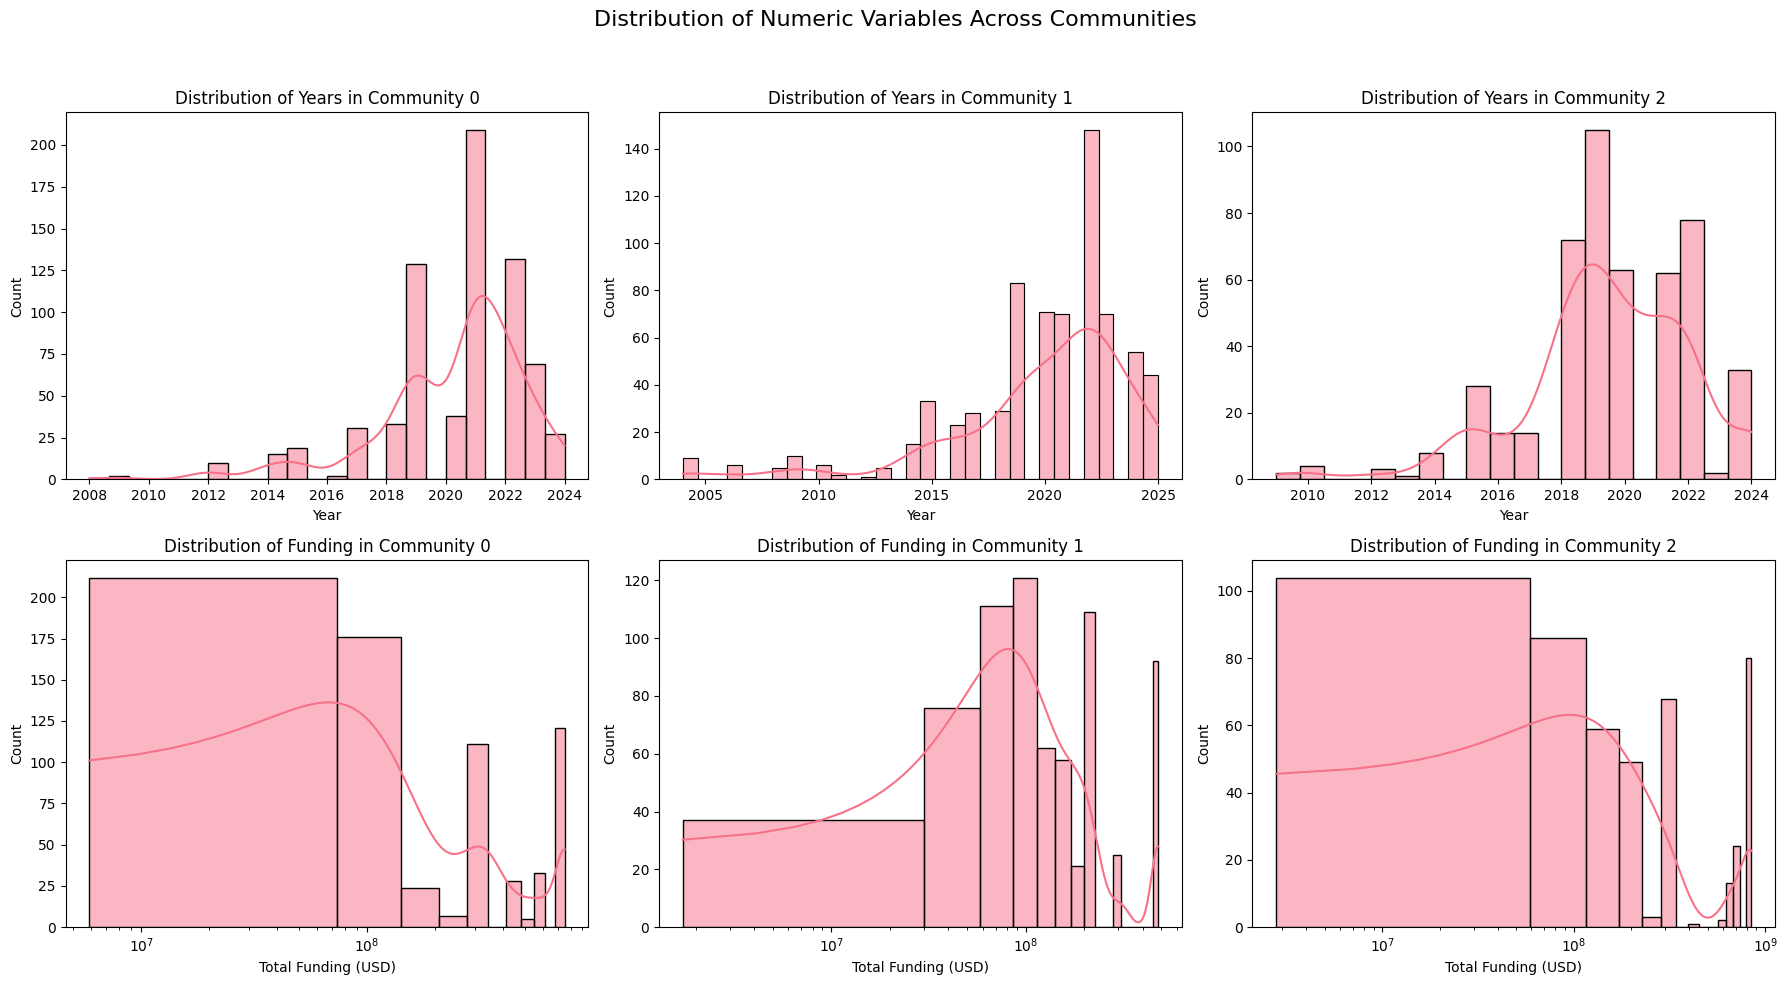

In [27]:
# Plot numeric columns
numeric_columns = ['year', 'total_funding_usd']
fig, axes = plt.subplots(len(numeric_columns), len(communities_of_interest), figsize=(18, 10))
fig.suptitle('Distribution of Numeric Variables Across Communities', fontsize=16)

for row_idx, column in enumerate(numeric_columns):
  for col_idx, comm_id in enumerate(communities_of_interest):
    ax = axes[row_idx, col_idx]
    data = community_data[comm_id]
    
    if len(data) > 0:
      if column == 'total_funding_usd':
        # Log scale and clip outliers
        sns.histplot(data[column].clip(upper=data[column].quantile(0.95), ), kde=True, ax=ax)
        ax.set_xlabel('Total Funding (USD)')
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of Funding in Community {comm_id}')
        ax.set_xscale('log')

      else:
        sns.histplot(data[column], kde=True, ax=ax)
        ax.set_xlabel('Year')
        ax.set_ylabel('Count')
        ax.set_title(f'Distribution of Years in Community {comm_id}')
        
    else:
      ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
      ax.set_title(f'Community {comm_id}')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
plt.savefig(os.path.join(figures_dir, 'numeric_variables_distribution.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

#### Categorical Columns

<Figure size 1200x800 with 0 Axes>

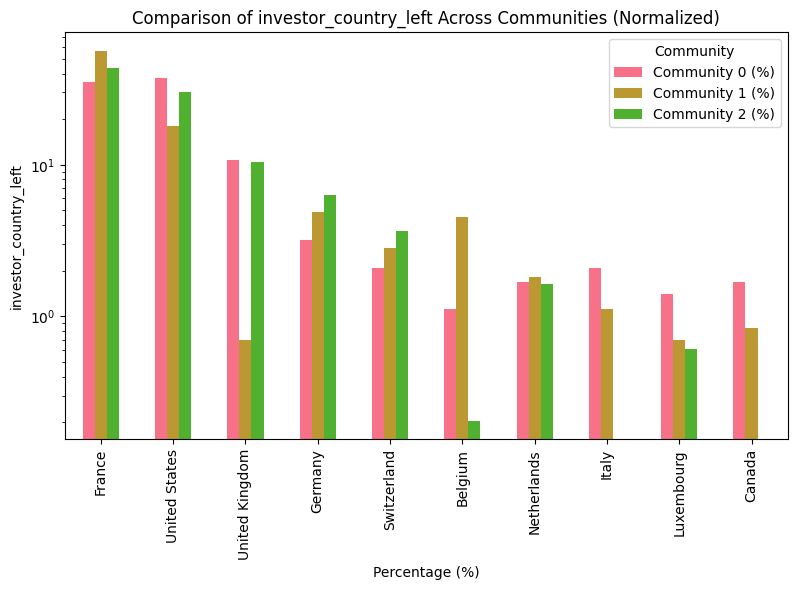

<Figure size 1200x800 with 0 Axes>

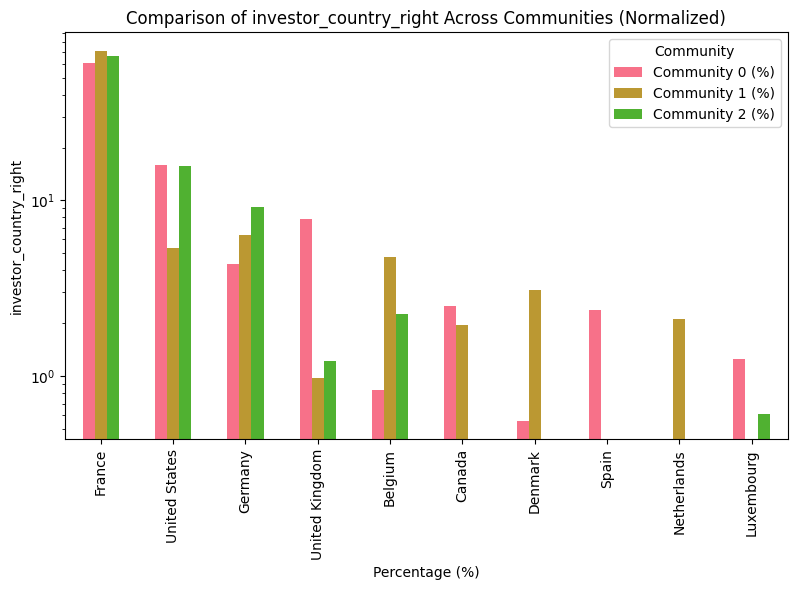

<Figure size 1200x800 with 0 Axes>

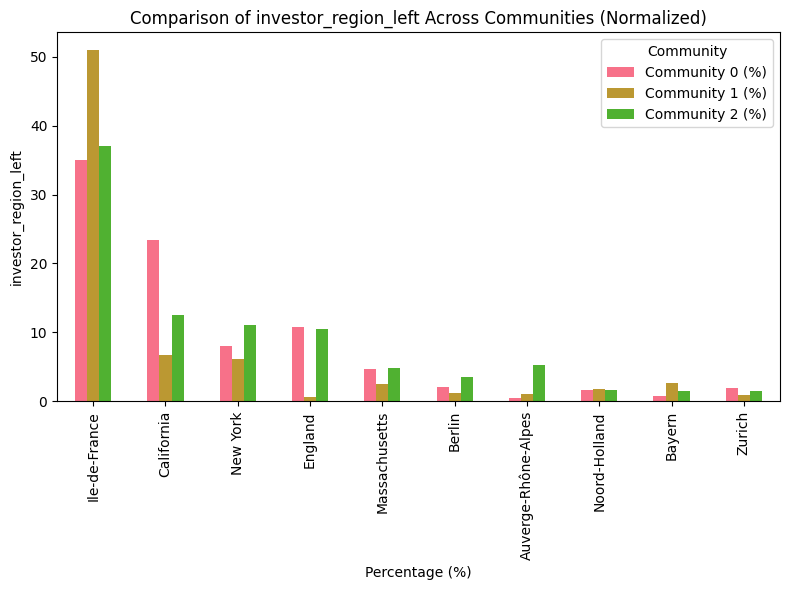

<Figure size 1200x800 with 0 Axes>

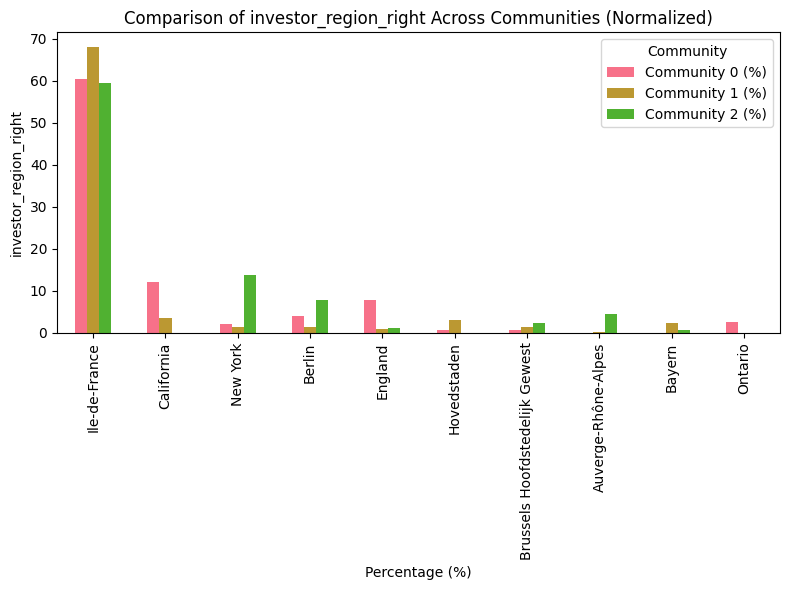

<Figure size 1200x800 with 0 Axes>

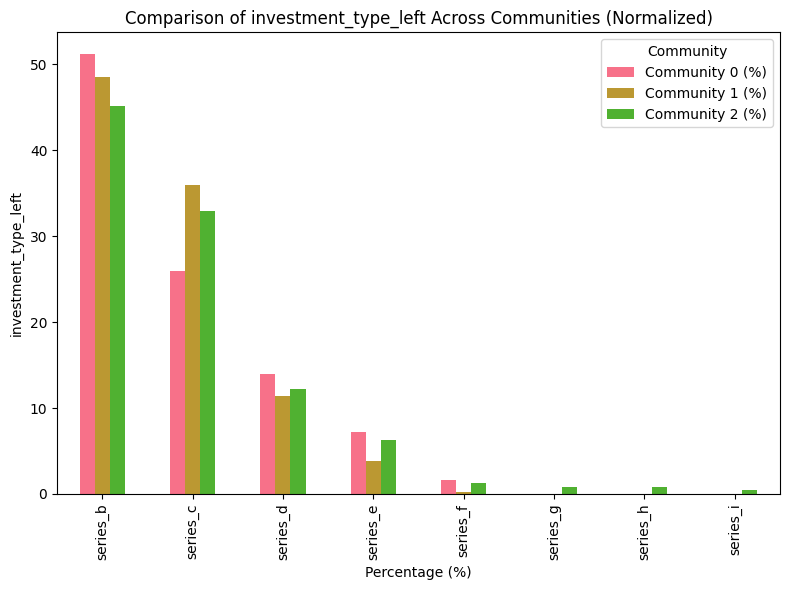

<Figure size 1200x800 with 0 Axes>

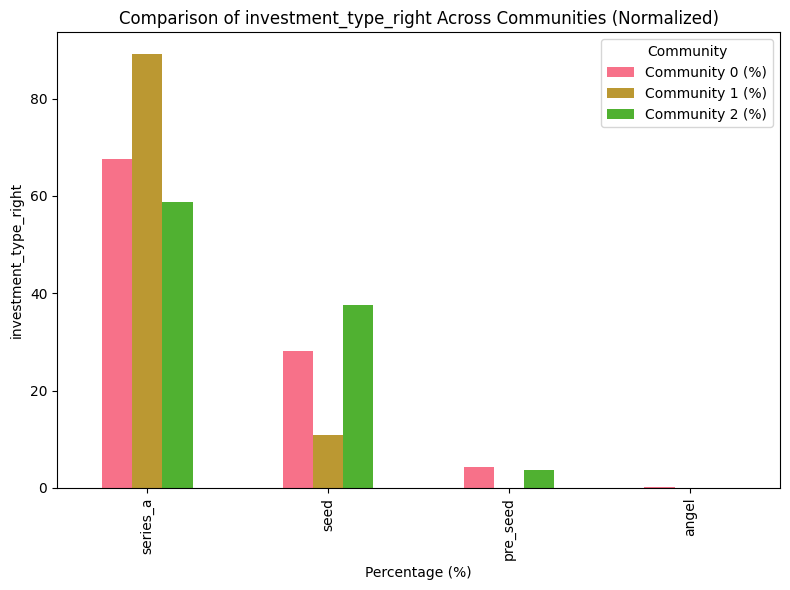

<Figure size 1200x800 with 0 Axes>

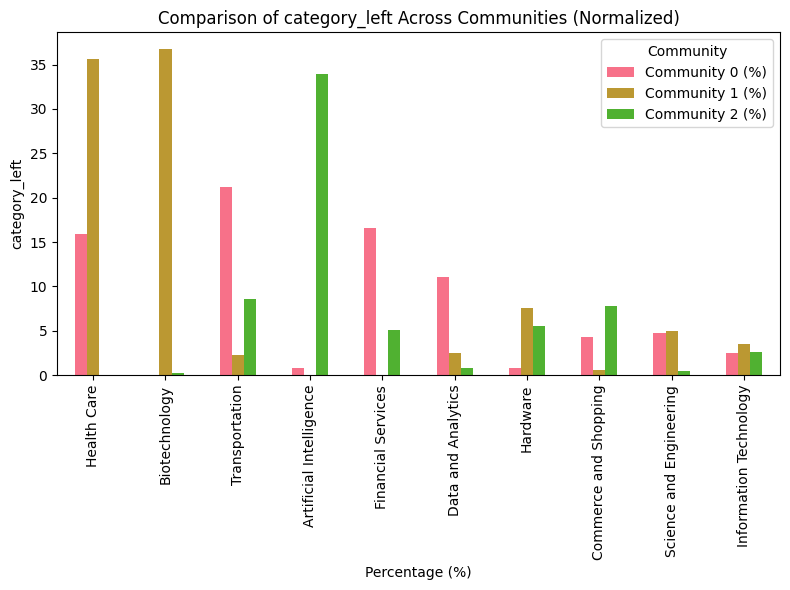

In [28]:
# Plot categorical columns
categorical_columns = [
  'investor_country_left',
  'investor_country_right',
  'investor_region_left',
  'investor_region_right',
  'investment_type_left',
  'investment_type_right',
  'category_left',
]

for column in categorical_columns:
  # Get the top 10 categories across all communities
  all_data = pd.concat([community_data[comm_id][column] for col_idx, comm_id in enumerate(communities_of_interest)])
  top_categories = all_data.value_counts().head(10).index.tolist()
  
  # Create a comparison dataframe
  comparison_df = pd.DataFrame(index=top_categories)
  
  for comm_id in communities_of_interest:
    if len(community_data[comm_id]) > 0:
      # Get counts for this community
      counts = community_data[comm_id][column].value_counts()
      # Normalize to percentages
      normalized_counts = counts / len(community_data[comm_id]) * 100
      # Add to comparison df
      comparison_df[f'Community {comm_id} (%)'] = normalized_counts.reindex(comparison_df.index, fill_value=0)
    else:
      comparison_df[f'Community {comm_id} (%)'] = 0
  
  # Truncate long category names
  truncated_index = [truncate_name(cat) for cat in comparison_df.index]
  comparison_df.index = truncated_index
  
  # Plot the comparison
  plt.figure(figsize=(12, 8))
  comparison_df.plot(kind='bar', figsize=(8, 6))
  plt.title(f'Comparison of {column} Across Communities (Normalized)')
  plt.xlabel('Percentage (%)')
  plt.ylabel(column)
  plt.legend(title='Community')
  plt.tight_layout()
  
  safe_column_name = column.replace('/', '_').replace(' ', '_')
  if 'country' in safe_column_name:
    plt.yscale('log')
  
  # Save figure
  plt.savefig(os.path.join(figures_dir, f'categorical_comparison_{safe_column_name}.png'), 
              dpi=300, bbox_inches='tight')
  plt.show()

#### Percentage of local (US and California) and foreign



US vs Foreign Investors Analysis

Community 0 (717 investment pairs)
------------------------------
Country Distribution:
  Late-stage investors (Left): US 37.4% (268/717), Foreign 62.6% (449/717)
  Early-stage investors (Right): US 15.9% (114/717), Foreign 84.1% (603/717)

US Region Distribution:
  Late-stage US investors (Left): California 62.7% (168/268), Other US 37.3% (100/268)
  Early-stage US investors (Right): California 76.3% (87/114), Other US 23.7% (27/114)

Community 1 (712 investment pairs)
------------------------------
Country Distribution:
  Late-stage investors (Left): US 18.0% (128/712), Foreign 82.0% (584/712)
  Early-stage investors (Right): US 5.3% (38/712), Foreign 94.7% (674/712)

US Region Distribution:
  Late-stage US investors (Left): California 37.5% (48/128), Other US 62.5% (80/128)
  Early-stage US investors (Right): California 65.8% (25/38), Other US 34.2% (13/38)

Community 2 (489 investment pairs)
------------------------------
Country Distribution:
  

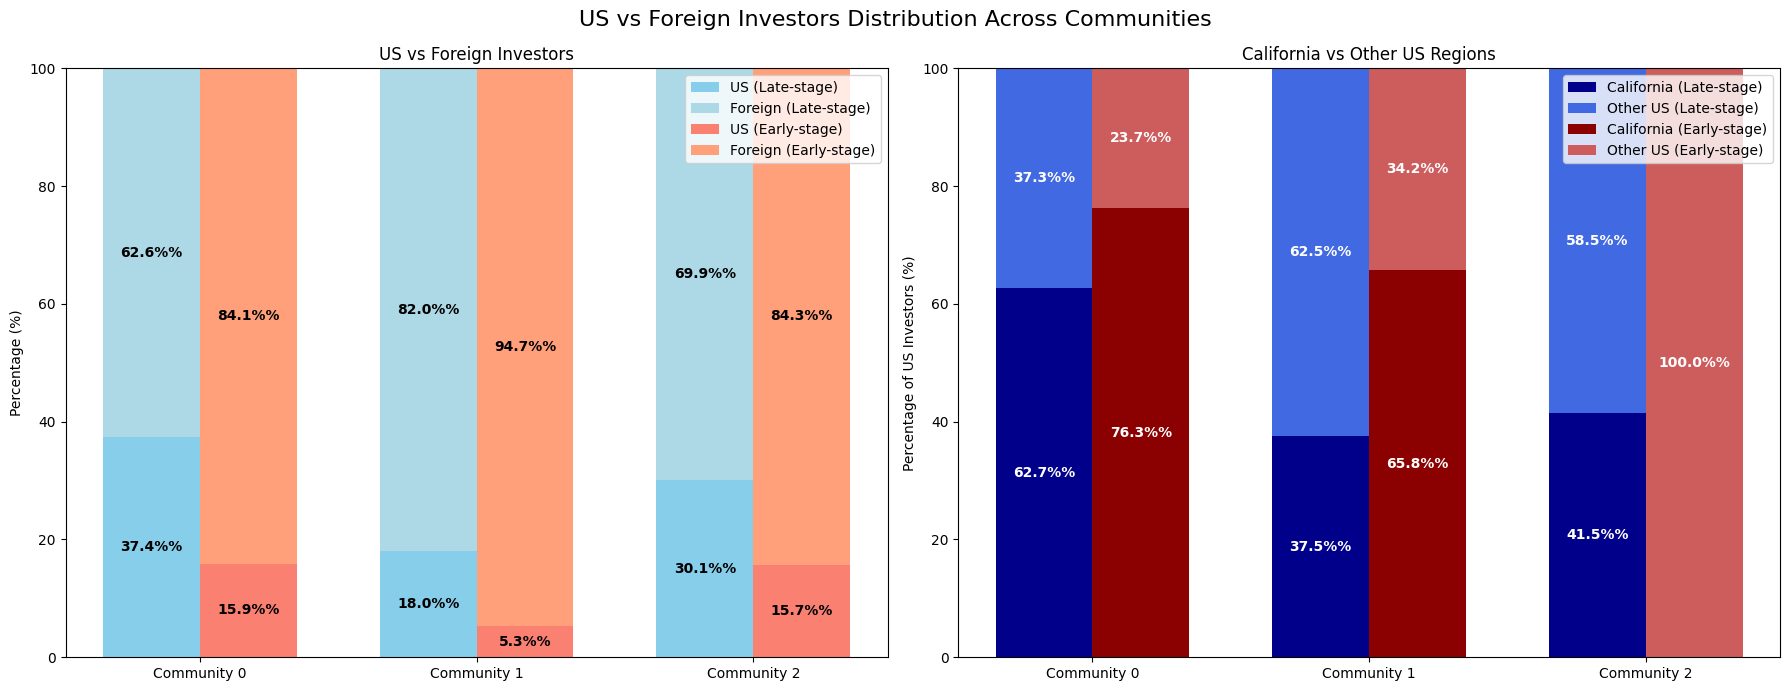

In [29]:
# Calculate percentage of US vs foreign investors for each community
print("\n\nUS vs Foreign Investors Analysis")
print("=" * 50)

# Initialize dictionaries to store results
country_stats = {}
region_stats = {}

for comm_id in communities_of_interest:
    # Get data for this community
    data = community_data[comm_id]
    
    # Country analysis
    country_stats[comm_id] = {}
    
    # Left investors (late-stage investors)
    left_total = len(data)
    left_us = data[data['investor_country_left'] == 'United States'].shape[0]
    left_foreign = left_total - left_us
    left_us_pct = (left_us / left_total * 100) if left_total > 0 else 0
    left_foreign_pct = (left_foreign / left_total * 100) if left_total > 0 else 0
    
    # Right investors (early-stage investors)
    right_total = len(data)
    right_us = data[data['investor_country_right'] == 'United States'].shape[0]
    right_foreign = right_total - right_us
    right_us_pct = (right_us / right_total * 100) if right_total > 0 else 0
    right_foreign_pct = (right_foreign / right_total * 100) if right_total > 0 else 0
    
    # Store results
    country_stats[comm_id]['left_us'] = left_us
    country_stats[comm_id]['left_foreign'] = left_foreign
    country_stats[comm_id]['left_us_pct'] = left_us_pct
    country_stats[comm_id]['left_foreign_pct'] = left_foreign_pct
    country_stats[comm_id]['right_us'] = right_us
    country_stats[comm_id]['right_foreign'] = right_foreign
    country_stats[comm_id]['right_us_pct'] = right_us_pct
    country_stats[comm_id]['right_foreign_pct'] = right_foreign_pct
    
    # Region analysis - California vs Other US regions
    region_stats[comm_id] = {}
    
    # Left investors (late-stage)
    left_us_data = data[data['investor_country_left'] == 'United States']
    left_us_total = len(left_us_data)
    left_california = left_us_data[left_us_data['investor_region_left'] == 'California'].shape[0]
    left_other_us = left_us_total - left_california
    left_california_pct = (left_california / left_us_total * 100) if left_us_total > 0 else 0
    left_other_us_pct = (left_other_us / left_us_total * 100) if left_us_total > 0 else 0
    
    # Right investors (early-stage)
    right_us_data = data[data['investor_country_right'] == 'United States']
    right_us_total = len(right_us_data)
    right_california = right_us_data[right_us_data['investor_region_right'] == 'California'].shape[0]
    right_other_us = right_us_total - right_california
    right_california_pct = (right_california / right_us_total * 100) if right_us_total > 0 else 0
    right_other_us_pct = (right_other_us / right_us_total * 100) if right_us_total > 0 else 0
    
    # Store results
    region_stats[comm_id]['left_california'] = left_california
    region_stats[comm_id]['left_other_us'] = left_other_us
    region_stats[comm_id]['left_california_pct'] = left_california_pct
    region_stats[comm_id]['left_other_us_pct'] = left_other_us_pct
    region_stats[comm_id]['right_california'] = right_california
    region_stats[comm_id]['right_other_us'] = right_other_us
    region_stats[comm_id]['right_california_pct'] = right_california_pct
    region_stats[comm_id]['right_other_us_pct'] = right_other_us_pct

    # Print results
    print(f"\nCommunity {comm_id} ({len(data)} investment pairs)")
    print("-" * 30)
    print("Country Distribution:")
    print(f"  Late-stage investors (Left): US {left_us_pct:.1f}% ({left_us}/{left_total}), Foreign {left_foreign_pct:.1f}% ({left_foreign}/{left_total})")
    print(f"  Early-stage investors (Right): US {right_us_pct:.1f}% ({right_us}/{right_total}), Foreign {right_foreign_pct:.1f}% ({right_foreign}/{right_total})")
    
    print("\nUS Region Distribution:")
    print(f"  Late-stage US investors (Left): California {left_california_pct:.1f}% ({left_california}/{left_us_total}), Other US {left_other_us_pct:.1f}% ({left_other_us}/{left_us_total})")
    print(f"  Early-stage US investors (Right): California {right_california_pct:.1f}% ({right_california}/{right_us_total}), Other US {right_other_us_pct:.1f}% ({right_other_us}/{right_us_total})")

# Create visualizations
# Country distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('US vs Foreign Investors Distribution Across Communities', fontsize=16)

# Data preparation for visualization
country_df = pd.DataFrame({
    'Community': list(communities_of_interest) * 2,
    'Investor Type': ['Late-stage (Left)'] * len(communities_of_interest) + ['Early-stage (Right)'] * len(communities_of_interest),
    'US Percentage': [country_stats[c]['left_us_pct'] for c in communities_of_interest] + 
                    [country_stats[c]['right_us_pct'] for c in communities_of_interest],
    'Foreign Percentage': [country_stats[c]['left_foreign_pct'] for c in communities_of_interest] + 
                         [country_stats[c]['right_foreign_pct'] for c in communities_of_interest]
})

# Bar plot for US vs Foreign
ax = axes[0]
x = np.arange(len(communities_of_interest))
width = 0.35

# Left investors (late-stage)
ax.bar(x - width/2, 
       [country_stats[c]['left_us_pct'] for c in communities_of_interest], 
       width, label='US (Late-stage)', color='skyblue')
ax.bar(x - width/2, 
       [country_stats[c]['left_foreign_pct'] for c in communities_of_interest],
       width, bottom=[country_stats[c]['left_us_pct'] for c in communities_of_interest],
       label='Foreign (Late-stage)', color='lightblue')

# Right investors (early-stage)
ax.bar(x + width/2, 
       [country_stats[c]['right_us_pct'] for c in communities_of_interest], 
       width, label='US (Early-stage)', color='salmon')
ax.bar(x + width/2, 
       [country_stats[c]['right_foreign_pct'] for c in communities_of_interest],
       width, bottom=[country_stats[c]['right_us_pct'] for c in communities_of_interest],
       label='Foreign (Early-stage)', color='lightsalmon')

ax.set_ylabel('Percentage (%)')
ax.set_title('US vs Foreign Investors')
ax.set_xticks(x)
ax.set_xticklabels([f'Community {c}' for c in communities_of_interest])
ax.legend()
ax.set_ylim(0, 100)

# Add value labels on bars
for i, c in enumerate(communities_of_interest):
    # Late-stage US
    ax.text(i - width/2, country_stats[c]['left_us_pct']/2, 
            f"{country_stats[c]['left_us_pct']:.1f}%%", 
            ha='center', va='center', color='black', fontweight='bold')
    
    # Late-stage Foreign
    ax.text(i - width/2, country_stats[c]['left_us_pct'] + country_stats[c]['left_foreign_pct']/2, 
            f"{country_stats[c]['left_foreign_pct']:.1f}%%", 
            ha='center', va='center', color='black', fontweight='bold')
    
    # Early-stage US
    ax.text(i + width/2, country_stats[c]['right_us_pct']/2, 
            f"{country_stats[c]['right_us_pct']:.1f}%%", 
            ha='center', va='center', color='black', fontweight='bold')
    
    # Early-stage Foreign
    ax.text(i + width/2, country_stats[c]['right_us_pct'] + country_stats[c]['right_foreign_pct']/2, 
            f"{country_stats[c]['right_foreign_pct']:.1f}%%", 
            ha='center', va='center', color='black', fontweight='bold')

# Region distribution (California vs Other US)
ax = axes[1]

# Left investors (late-stage)
ax.bar(x - width/2, 
       [region_stats[c]['left_california_pct'] for c in communities_of_interest], 
       width, label='California (Late-stage)', color='darkblue')
ax.bar(x - width/2, 
       [region_stats[c]['left_other_us_pct'] for c in communities_of_interest],
       width, bottom=[region_stats[c]['left_california_pct'] for c in communities_of_interest],
       label='Other US (Late-stage)', color='royalblue')

# Right investors (early-stage)
ax.bar(x + width/2, 
       [region_stats[c]['right_california_pct'] for c in communities_of_interest], 
       width, label='California (Early-stage)', color='darkred')
ax.bar(x + width/2, 
       [region_stats[c]['right_other_us_pct'] for c in communities_of_interest],
       width, bottom=[region_stats[c]['right_california_pct'] for c in communities_of_interest],
       label='Other US (Early-stage)', color='indianred')

ax.set_ylabel('Percentage of US Investors (%)')
ax.set_title('California vs Other US Regions')
ax.set_xticks(x)
ax.set_xticklabels([f'Community {c}' for c in communities_of_interest])
ax.legend()
ax.set_ylim(0, 100)

# Add value labels on bars
for i, c in enumerate(communities_of_interest):
    # Late-stage California
    if region_stats[c]['left_california_pct'] > 5:  # Only show label if enough space
        ax.text(i - width/2, region_stats[c]['left_california_pct']/2, 
                f"{region_stats[c]['left_california_pct']:.1f}%%", 
                ha='center', va='center', color='white', fontweight='bold')
    
    # Late-stage Other US
    if region_stats[c]['left_other_us_pct'] > 5:
        ax.text(i - width/2, region_stats[c]['left_california_pct'] + region_stats[c]['left_other_us_pct']/2, 
                f"{region_stats[c]['left_other_us_pct']:.1f}%%", 
                ha='center', va='center', color='white', fontweight='bold')
    
    # Early-stage California
    if region_stats[c]['right_california_pct'] > 5:
        ax.text(i + width/2, region_stats[c]['right_california_pct']/2, 
                f"{region_stats[c]['right_california_pct']:.1f}%%", 
                ha='center', va='center', color='white', fontweight='bold')
    
    # Early-stage Other US
    if region_stats[c]['right_other_us_pct'] > 5:
        ax.text(i + width/2, region_stats[c]['right_california_pct'] + region_stats[c]['right_other_us_pct']/2, 
                f"{region_stats[c]['right_other_us_pct']:.1f}%%", 
                ha='center', va='center', color='white', fontweight='bold')

# Statistical tests for comparing proportions across communities
print("\n\nStatistical Tests for Community Differences")
print("=" * 50)

# US vs Foreign comparison
print("\nUS vs Foreign Investors Comparison:")
for i in range(len(communities_of_interest)):
    for j in range(i+1, len(communities_of_interest)):
        comm1 = communities_of_interest[i]
        comm2 = communities_of_interest[j]
        
        # Late-stage (left) US proportion test
        count1 = country_stats[comm1]['left_us']
        count2 = country_stats[comm2]['left_us']
        total1 = len(community_data[comm1])
        total2 = len(community_data[comm2])
        
        if count1 >= 5 and count2 >= 5 and total1 >= 20 and total2 >= 20:
            # Create contingency table
            contingency = np.array([
                [count1, count2],
                [total1 - count1, total2 - count2]
            ])
            
            # Perform chi-square test
            _, p_value = stats.chi2_contingency(contingency)[:2]
            
            # Format result with significance indicator
            sig = ''
            if p_value < 0.05: sig = '*'
            if p_value < 0.01: sig = '**'
            if p_value < 0.001: sig = '***'
            
            print(f"  Late-stage US Investors - Communities {comm1} vs {comm2}: {count1/total1*100:.1f}% vs {count2/total2*100:.1f}%, p-value={p_value:.4f} {sig}")
        
        # Early-stage (right) US proportion test
        count1 = country_stats[comm1]['right_us']
        count2 = country_stats[comm2]['right_us']
        
        if count1 >= 5 and count2 >= 5 and total1 >= 20 and total2 >= 20:
            # Create contingency table
            contingency = np.array([
                [count1, count2],
                [total1 - count1, total2 - count2]
            ])
            
            # Perform chi-square test
            _, p_value = stats.chi2_contingency(contingency)[:2]
            
            # Format result with significance indicator
            sig = ''
            if p_value < 0.05: sig = '*'
            if p_value < 0.01: sig = '**'
            if p_value < 0.001: sig = '***'
            
            print(f"  Early-stage US Investors - Communities {comm1} vs {comm2}: {count1/total1*100:.1f}% vs {count2/total2*100:.1f}%, p-value={p_value:.4f} {sig}")

# California vs Other US comparison
print("\nCalifornia vs Other US Regions Comparison:")
for i in range(len(communities_of_interest)):
    for j in range(i+1, len(communities_of_interest)):
        comm1 = communities_of_interest[i]
        comm2 = communities_of_interest[j]
        
        # Late-stage (left) California proportion test
        count1 = region_stats[comm1]['left_california']
        count2 = region_stats[comm2]['left_california']
        total1 = country_stats[comm1]['left_us']
        total2 = country_stats[comm2]['left_us']
        
        if count1 >= 5 and count2 >= 5 and total1 >= 20 and total2 >= 20:
            # Create contingency table
            contingency = np.array([
                [count1, count2],
                [total1 - count1, total2 - count2]
            ])
            
            # Perform chi-square test
            _, p_value = stats.chi2_contingency(contingency)[:2]
            
            # Format result with significance indicator
            sig = ''
            if p_value < 0.05: sig = '*'
            if p_value < 0.01: sig = '**'
            if p_value < 0.001: sig = '***'
            
            print(f"  Late-stage California Investors - Communities {comm1} vs {comm2}: {count1/total1*100:.1f}% vs {count2/total2*100:.1f}%, p-value={p_value:.4f} {sig}")
        
        # Early-stage (right) California proportion test
        count1 = region_stats[comm1]['right_california']
        count2 = region_stats[comm2]['right_california']
        total1 = country_stats[comm1]['right_us']
        total2 = country_stats[comm2]['right_us']
        
        if count1 >= 5 and count2 >= 5 and total1 >= 20 and total2 >= 20:
            # Create contingency table
            contingency = np.array([
                [count1, count2],
                [total1 - count1, total2 - count2]
            ])
            
            # Perform chi-square test
            _, p_value = stats.chi2_contingency(contingency)[:2]
            
            # Format result with significance indicator
            sig = ''
            if p_value < 0.05: sig = '*'
            if p_value < 0.01: sig = '**'
            if p_value < 0.001: sig = '***'
            
            print(f"  Early-stage California Investors - Communities {comm1} vs {comm2}: {count1/total1*100:.1f}% vs {count2/total2*100:.1f}%, p-value={p_value:.4f} {sig}")

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'us_vs_foreign_investors_distribution.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

#### Distribution of degrees

In [30]:
# Calculate degree centrality for all nodes in the bipartite graph
degree_dict = dict(bipartite_graph.degree())

# Initialize storage for community degree distributions
community_degree_distributions = {}

for comm_id in communities_of_interest:
    # Get nodes in this community
    community_nodes = list(top_communities[comm_id])
    
    # Get degrees for nodes in this community
    community_degrees = [degree_dict[node] for node in community_nodes if node in degree_dict]
    
    # Store the distribution
    community_degree_distributions[comm_id] = community_degrees
    
    print(f"Community {comm_id}: {len(community_degrees)} nodes")
    print(f"  Mean degree: {np.mean(community_degrees):.2f}")
    print(f"  Median degree: {np.median(community_degrees):.2f}")
    print(f"  Max degree: {np.max(community_degrees):.0f}")
    print(f"  Min degree: {np.min(community_degrees):.0f}")
    print(f"  Std deviation: {np.std(community_degrees):.2f}")
    print()

Community 0: 245 nodes
  Mean degree: 7.07
  Median degree: 5.00
  Max degree: 49
  Min degree: 1
  Std deviation: 7.51

Community 1: 232 nodes
  Mean degree: 6.90
  Median degree: 4.00
  Max degree: 72
  Min degree: 1
  Std deviation: 8.87

Community 2: 196 nodes
  Mean degree: 6.54
  Median degree: 4.00
  Max degree: 84
  Min degree: 1
  Std deviation: 10.22



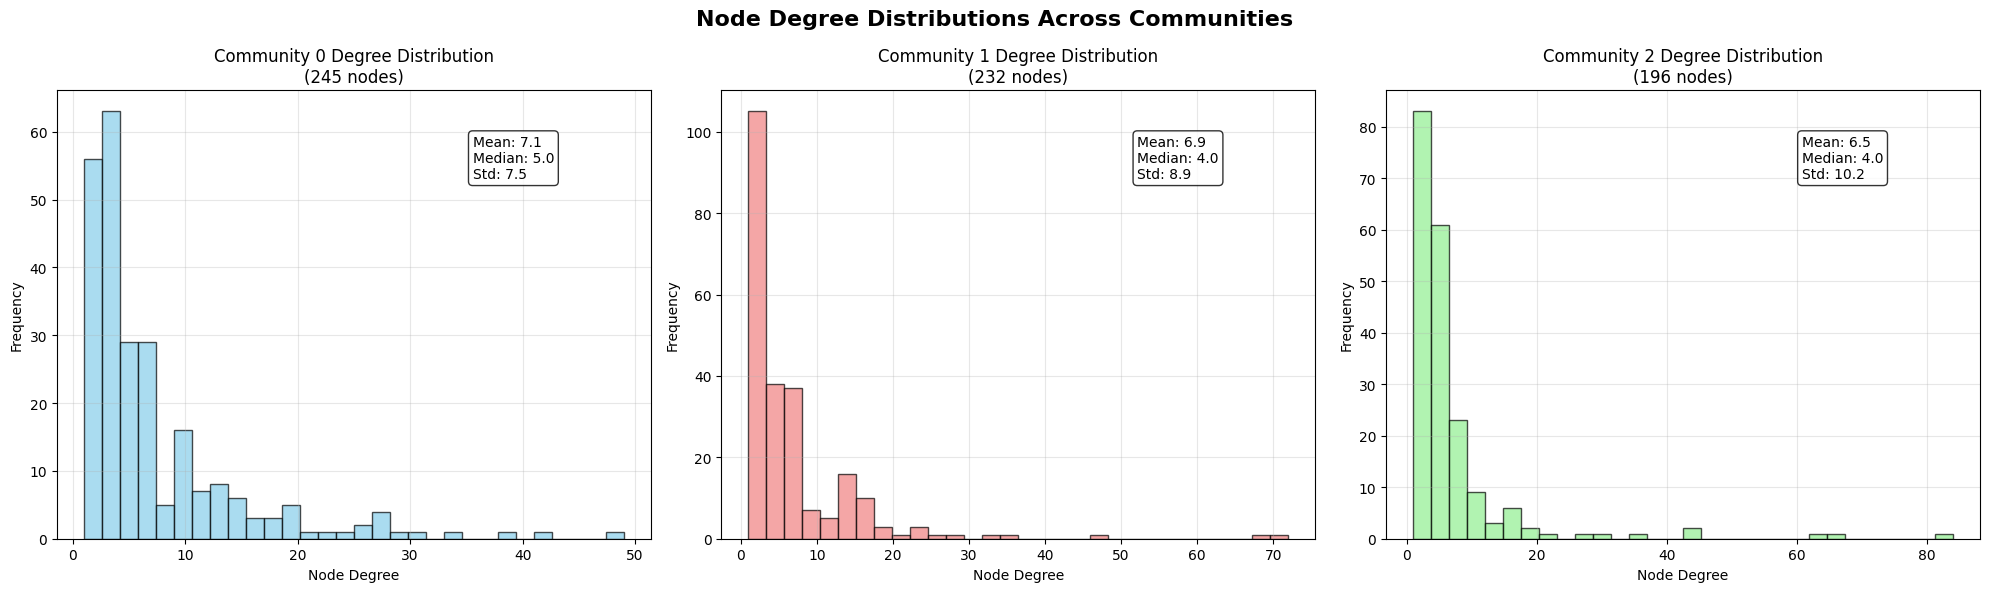

In [31]:
# Create comprehensive degree distribution plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Node Degree Distributions Across Communities', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Colors for each community
colors = ['skyblue', 'lightcoral', 'lightgreen']

# Plot 1: Histograms for each community
for i, comm_id in enumerate(communities_of_interest):
    ax = axes_flat[i]
    degrees = community_degree_distributions[comm_id]
    
    # Create histogram
    ax.hist(degrees, bins=30, alpha=0.7, color=colors[i], edgecolor='black')
    ax.set_title(f'Community {comm_id} Degree Distribution\n({len(degrees)} nodes)')
    ax.set_xlabel('Node Degree')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f'Mean: {np.mean(degrees):.1f}\nMedian: {np.median(degrees):.1f}\nStd: {np.std(degrees):.1f}'
    ax.text(0.7, 0.9, stats_text, transform=ax.transAxes, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='top')

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'node_degree_distributions_comprehensive_pt1.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

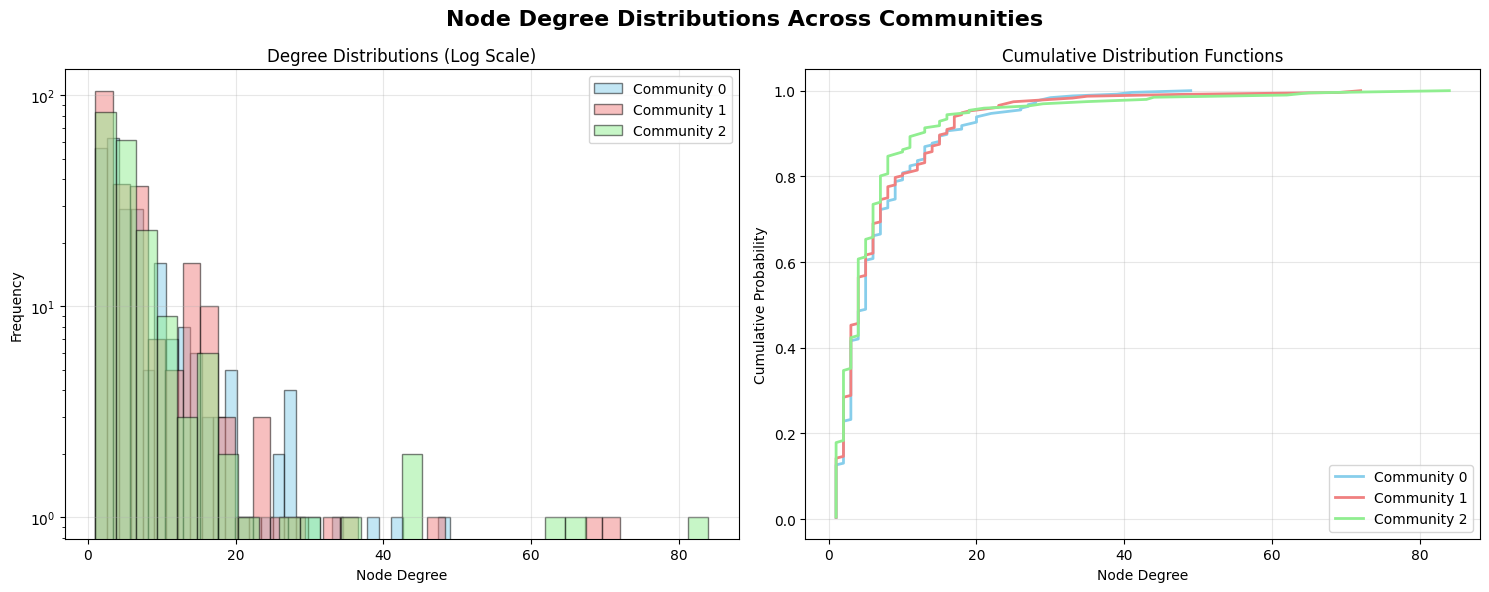

In [32]:
# Create comprehensive degree distribution plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Node Degree Distributions Across Communities', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Plot 5: Log-scale histograms (to better see heavy tails)
ax = axes_flat[0]
for i, comm_id in enumerate(communities_of_interest):
    degrees = community_degree_distributions[comm_id]
    ax.hist(degrees, bins=30, alpha=0.5, label=f'Community {comm_id}', 
            color=colors[i], edgecolor='black')

ax.set_title('Degree Distributions (Log Scale)')
ax.set_xlabel('Node Degree')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6: Cumulative distribution functions
ax = axes_flat[1]
for i, comm_id in enumerate(communities_of_interest):
    degrees = np.array(community_degree_distributions[comm_id])
    degrees_sorted = np.sort(degrees)
    cdf = np.arange(1, len(degrees_sorted) + 1) / len(degrees_sorted)
    
    ax.plot(degrees_sorted, cdf, label=f'Community {comm_id}', color=colors[i], linewidth=2)

ax.set_title('Cumulative Distribution Functions')
ax.set_xlabel('Node Degree')
ax.set_ylabel('Cumulative Probability')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'node_degree_distributions_comprehensive_pt2.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Statistical tests for degree distribution differences
print("Statistical Tests for Degree Distribution Differences")
print("=" * 60)

# Kolmogorov-Smirnov tests between communities
print("\nKolmogorov-Smirnov Tests (comparing distributions):")
for i in range(len(communities_of_interest)):
    for j in range(i+1, len(communities_of_interest)):
        comm1 = communities_of_interest[i]
        comm2 = communities_of_interest[j]
        
        degrees1 = community_degree_distributions[comm1]
        degrees2 = community_degree_distributions[comm2]
        
        # Perform KS test
        ks_stat, p_value = stats.ks_2samp(degrees1, degrees2)
        
        # Format result with significance indicator
        sig = ''
        if p_value < 0.05: sig = '*'
        if p_value < 0.01: sig = '**'
        if p_value < 0.001: sig = '***'
        
        print(f"  Communities {comm1} vs {comm2}: KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f} {sig}")

# Mann-Whitney U tests for median differences
print("\nMann-Whitney U Tests (comparing medians):")
for i in range(len(communities_of_interest)):
    for j in range(i+1, len(communities_of_interest)):
        comm1 = communities_of_interest[i]
        comm2 = communities_of_interest[j]
        
        degrees1 = community_degree_distributions[comm1]
        degrees2 = community_degree_distributions[comm2]
        
        # Perform Mann-Whitney U test
        u_stat, p_value = stats.mannwhitneyu(degrees1, degrees2, alternative='two-sided')
        
        # Format result with significance indicator
        sig = ''
        if p_value < 0.05: sig = '*'
        if p_value < 0.01: sig = '**'
        if p_value < 0.001: sig = '***'
        
        median1 = np.median(degrees1)
        median2 = np.median(degrees2)
        
        print(f"  Communities {comm1} vs {comm2}: medians = {median1:.1f} vs {median2:.1f}, p-value = {p_value:.4f} {sig}")

# Summary statistics table
print("\nSummary Statistics Table:")
print("-" * 80)
print(f"{'Community':<12} {'Nodes':<8} {'Mean':<8} {'Median':<8} {'Std':<8} {'Min':<6} {'Max':<6} {'Skewness':<10}")
print("-" * 80)

for comm_id in communities_of_interest:
    degrees = community_degree_distributions[comm_id]
    mean_deg = np.mean(degrees)
    median_deg = np.median(degrees)
    std_deg = np.std(degrees)
    min_deg = np.min(degrees)
    max_deg = np.max(degrees)
    skewness = stats.skew(degrees)
    
    print(f"{comm_id:<12} {len(degrees):<8} {mean_deg:<8.1f} {median_deg:<8.1f} {std_deg:<8.1f} {min_deg:<6.0f} {max_deg:<6.0f} {skewness:<10.2f}")

Statistical Tests for Degree Distribution Differences

Kolmogorov-Smirnov Tests (comparing distributions):
  Communities 0 vs 1: KS statistic = 0.0789, p-value = 0.4180 
  Communities 0 vs 2: KS statistic = 0.1214, p-value = 0.0744 
  Communities 1 vs 2: KS statistic = 0.0825, p-value = 0.4343 

Mann-Whitney U Tests (comparing medians):
  Communities 0 vs 1: medians = 5.0 vs 4.0, p-value = 0.2964 
  Communities 0 vs 2: medians = 5.0 vs 4.0, p-value = 0.0327 *
  Communities 1 vs 2: medians = 4.0 vs 4.0, p-value = 0.2715 

Summary Statistics Table:
--------------------------------------------------------------------------------
Community    Nodes    Mean     Median   Std      Min    Max    Skewness  
--------------------------------------------------------------------------------
0            245      7.1      5.0      7.5      1      49     2.42      
1            232      6.9      4.0      8.9      1      72     4.11      
2            196      6.5      4.0      10.2     1      84     

In [34]:
# Analyze high-degree nodes (hubs) in each community
print("High-Degree Nodes (Hubs) Analysis")
print("=" * 50)

show_top = 20

for comm_id in communities_of_interest:
    degrees = community_degree_distributions[comm_id]
    community_nodes = list(top_communities[comm_id])
    
    # Find nodes with degrees in top 5%
    threshold_95 = np.percentile(degrees, 95)
    
    # Get high-degree nodes
    high_degree_nodes = []
    for node in community_nodes:
        if node in degree_dict and degree_dict[node] >= threshold_95:
            high_degree_nodes.append((node, degree_dict[node]))
    
    # Sort by degree (descending)
    high_degree_nodes.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nCommunity {comm_id} - Top High-Degree Nodes (95th percentile, threshold={threshold_95:.1f}):")
    print("-" * 60)
    
    for i, (node, degree) in enumerate(high_degree_nodes[:show_top]):  # Show top show_top
        # Determine if it's a left or right node
        node_type = 'Late-stage' if node in set_0 else 'Early-stage'
        print(f"  {i+1:2d}. {node:<40} (degree: {degree:3d}, type: {node_type})")
    
    if len(high_degree_nodes) > show_top:
        print(f"     ... and {len(high_degree_nodes) - show_top} more high-degree nodes")
    
    # Calculate percentage of high-degree nodes by type
    left_hubs = sum(1 for node, _ in high_degree_nodes if node in set_0)
    right_hubs = sum(1 for node, _ in high_degree_nodes if node in set_1)
    total_hubs = len(high_degree_nodes)
    
    if total_hubs > 0:
        left_pct = (left_hubs / total_hubs) * 100
        right_pct = (right_hubs / total_hubs) * 100
        print(f"     Hub distribution: {left_hubs} late-stage ({left_pct:.1f}%), {right_hubs} early-stage ({right_pct:.1f}%)")

High-Degree Nodes (Hubs) Analysis

Community 0 - Top High-Degree Nodes (95th percentile, threshold=23.6):
------------------------------------------------------------
   1. Partech-series_a                         (degree:  49, type: Early-stage)
   2. Elaia-series_a                           (degree:  41, type: Early-stage)
   3. XAnge-series_b                           (degree:  39, type: Late-stage)
   4. Aglaé Ventures-series_a                  (degree:  33, type: Early-stage)
   5. Partech-seed                             (degree:  30, type: Early-stage)
   6. Index Ventures-series_a                  (degree:  29, type: Early-stage)
   7. Financiere Saint James-series_a          (degree:  28, type: Early-stage)
   8. Serena-series_b                          (degree:  28, type: Late-stage)
   9. Daphni-series_a                          (degree:  27, type: Early-stage)
  10. Isai-series_a                            (degree:  27, type: Early-stage)
  11. Kerala Ventures-seed         

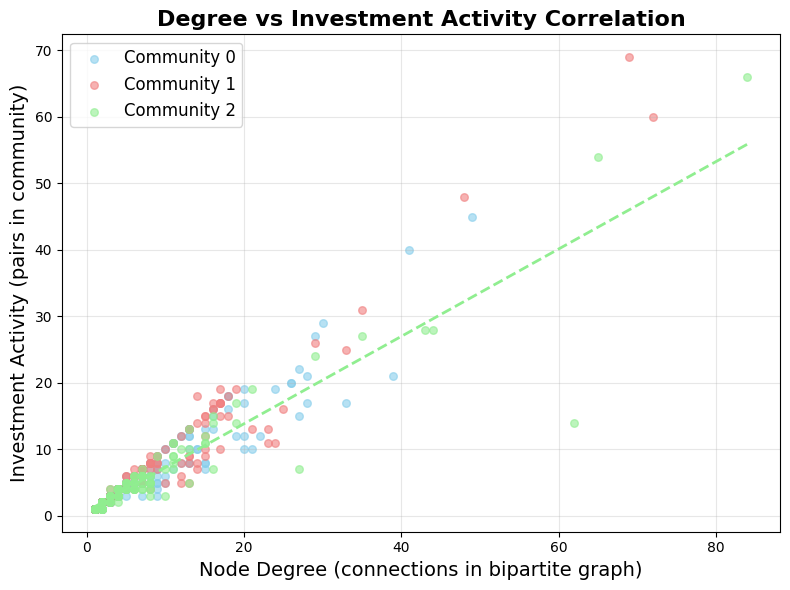

In [35]:
# Create a detailed degree analysis plot focused on the tails of the distribution
plt.figure(figsize=(8, 6))
plt.title('Degree vs Investment Activity Correlation', fontsize=16, fontweight='bold')

# For each community, plot degree vs some measure of activity
for i, comm_id in enumerate(communities_of_interest):
    community_nodes = list(top_communities[comm_id])
    community_data_subset = community_data[comm_id]
    
    # Count investment pairs for each investor
    investor_activity = {}
    for _, row in community_data_subset.iterrows():
        left_inv = row['investor_name_left']
        right_inv = row['investor_name_right']
        
        investor_activity[left_inv] = investor_activity.get(left_inv, 0) + 1
        investor_activity[right_inv] = investor_activity.get(right_inv, 0) + 1
    
    # Create scatter plot of degree vs activity
    degrees_plot = []
    activities_plot = []
    
    for node in community_nodes:
        if node in degree_dict and node in investor_activity:
            degrees_plot.append(degree_dict[node])
            activities_plot.append(investor_activity[node])
    
    if degrees_plot and activities_plot:
        plt.scatter(degrees_plot, activities_plot, alpha=0.6, 
                  label=f'Community {comm_id}', color=colors[i], s=30)

plt.xlabel('Node Degree (connections in bipartite graph)', fontsize=14)
plt.ylabel('Investment Activity (pairs in community)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Add trendlines for visual aid
for i, comm_id in enumerate(communities_of_interest):
    community_nodes = list(top_communities[comm_id])
    community_data_subset = community_data[comm_id]
    
    # Get degrees and activities again for trendline
    degrees_plot = []
    activities_plot = []
    
    for node in community_nodes:
        if node in degree_dict and node in investor_activity:
            degrees_plot.append(degree_dict[node])
            activities_plot.append(investor_activity[node])
    
    if degrees_plot and activities_plot:
        # Calculate trendline
        z = np.polyfit(degrees_plot, activities_plot, 1)
        p = np.poly1d(z)
        
        # Add trendline to plot
        x_trend = np.linspace(min(degrees_plot), max(degrees_plot), 100)
        plt.plot(x_trend, p(x_trend), '--', color=colors[i], linewidth=2)

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'degree_vs_investment_corr.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

### Nestedness Analysis

#### Nestedness for each Community

In [36]:
if CALCULATE_COMMUNITIES_NESTEDNESS or not os.path.exists(community_nestedness_file):
    # Initialize storage for community nestedness results
    community_nestedness_results = []

    # Parameters for null model analysis
    n_iterations = 100  # Number of null models to generate
    n_iterations_cv = 10000  # Number of curveball iterations
    min_community_size = 100  # Minimum nodes required for analysis

    print(f"Analyzing nestedness for {len(top_communities)} communities...")
    print("=" * 60)

    for comm_idx, community in enumerate(top_communities):
        if len(community) < min_community_size:
            print(f"Community {comm_idx}: Skipping (only {len(community)} nodes)")
            continue
        
        try:
            # Extract subgraph for this community
            subgraph = bipartite_graph.subgraph(community)
            
            # Get bipartite sets for this community
            community_set_0 = [node for node in community if node in set_0]
            community_set_1 = [node for node in community if node in set_1]
            
            # Skip if either set is empty
            if len(community_set_0) == 0 or len(community_set_1) == 0:
                print(f"Community {comm_idx}: Skipping (empty bipartite set)")
                continue
            
            print(f"Community {comm_idx}: {len(community_set_0)} left nodes, {len(community_set_1)} right nodes")
            
            # Create adjacency matrix for this community
            left_indices = {node: i for i, node in enumerate(community_set_0)}
            right_indices = {node: j for j, node in enumerate(community_set_1)}
            
            # Initialize adjacency matrix
            community_adjacency_matrix = np.zeros((len(community_set_0), len(community_set_1)))
            
            # Fill matrix with connections within this community
            for left_node in community_set_0:
                for right_node in community_set_1:
                    if subgraph.has_edge(left_node, right_node):
                        left_idx = left_indices[left_node]
                        right_idx = right_indices[right_node]
                        community_adjacency_matrix[left_idx, right_idx] = 1
            
            # Calculate observed nestedness
            calculator = NestednessCalculator(community_adjacency_matrix)
            nestedness_score = calculator.nodf(community_adjacency_matrix)
            
            # Calculate basic network metrics
            num_edges = int(community_adjacency_matrix.sum())
            density = community_adjacency_matrix.mean()
            
            print(f"  Observed nestedness (NODF): {nestedness_score:.4f}")
            print(f"  Edges: {num_edges}, Density: {density:.4f}")
            
            # Generate null models using curveball algorithm
            null_nestedness_scores = []
            
            print(f"  Generating {n_iterations} null models...")
            for i in tqdm(range(n_iterations), desc=f"Community {comm_idx}"):
                try:
                    # Generate null model matrix by swapping while preserving degrees
                    M = community_adjacency_matrix.copy()
                    r_hp = find_presences(M)
                    RM = curve_ball(M, r_hp, n_iterations_cv)
                    
                    null_matrix = RM.astype(community_adjacency_matrix.dtype)
                    
                    # Calculate nestedness of the null model
                    calculator_null = NestednessCalculator(null_matrix)
                    null_score = calculator_null.nodf(null_matrix)
                    null_nestedness_scores.append(null_score)
                    
                except Exception as e:
                    print(f"    Error in null model iteration {i}: {e}")
                    continue
            
            # Calculate statistical significance
            if len(null_nestedness_scores) > 0:
                null_nestedness_scores_np = np.array(null_nestedness_scores)
                mean_null = np.mean(null_nestedness_scores_np)
                std_null = np.std(null_nestedness_scores_np)
                
                if std_null > 0:
                    z_score = (nestedness_score - mean_null) / std_null
                else:
                    z_score = np.nan
                
                # Corrected p-value calculation for empirical distributions
                # Adding 1 to both numerator and denominator to avoid p-values of exactly 0
                # This is the standard approach for empirical p-values with discrete distributions
                p_value = (np.sum(null_nestedness_scores_np >= nestedness_score) + 1) / (len(null_nestedness_scores_np) + 1)
                significance = 'significant' if p_value < 0.05 else 'not_significant'
                
                print(f"  Null model mean: {mean_null:.4f} ± {std_null:.4f}")
                print(f"  Z-score: {z_score:.10f}, P-value: {p_value:.10f} ({significance})")
            else:
                mean_null = std_null = z_score = p_value = np.nan
                significance = 'null_model_failed'
                print(f"  Warning: No valid null models generated")
            
            # Store results
            community_nestedness_results.append({
                'community_id': comm_idx,
                'community_size': len(community),
                'left_nodes': len(community_set_0),
                'right_nodes': len(community_set_1),
                'num_edges': num_edges,
                'density': density,
                'observed_nestedness': nestedness_score,
                'null_mean': mean_null,
                'null_std': std_null,
                'z_score': z_score,
                'p_value': p_value,
                'significance': significance,
                'null_scores': null_nestedness_scores if len(null_nestedness_scores) > 0 else []
            })
            
        except Exception as e:
            print(f"Community {comm_idx}: Error - {str(e)}")
            continue

    print(f"\nAnalyzed {len(community_nestedness_results)} communities successfully")
    community_nestedness_df = pd.DataFrame(community_nestedness_results)
    community_nestedness_df.to_csv(community_nestedness_file, compression='gzip')
    print(f"Saved nestedness results to {community_nestedness_file}")
else:
    community_nestedness_df = pd.read_csv(community_nestedness_file, compression='gzip')

    # Apply the parsing function to the null_scores column
    community_nestedness_df['null_scores'] = community_nestedness_df['null_scores'].apply(parse_null_scores)
    print(f"Got nestedness results from {community_nestedness_file}")

Analyzing nestedness for 10 communities...
Community 0: 160 left nodes, 85 right nodes
  Observed nestedness (NODF): 0.1155
  Edges: 707, Density: 0.0520
  Generating 100 null models...


Community 0: 100%|██████████| 100/100 [00:06<00:00, 15.39it/s]


  Null model mean: 0.1223 ± 0.0030
  Z-score: -2.2613832962, P-value: 0.9900990099 (not_significant)
Community 1: 166 left nodes, 66 right nodes
  Observed nestedness (NODF): 0.1811
  Edges: 695, Density: 0.0634
  Generating 100 null models...


Community 1: 100%|██████████| 100/100 [00:07<00:00, 13.67it/s]


  Null model mean: 0.1798 ± 0.0050
  Z-score: 0.2573403725, P-value: 0.3861386139 (not_significant)
Community 2: 141 left nodes, 55 right nodes
  Observed nestedness (NODF): 0.1870
  Edges: 479, Density: 0.0618
  Generating 100 null models...


Community 2: 100%|██████████| 100/100 [00:06<00:00, 15.92it/s]

  Null model mean: 0.2159 ± 0.0055
  Z-score: -5.2605491373, P-value: 1.0000000000 (not_significant)
Community 3: Skipping (only 88 nodes)
Community 4: Skipping (only 84 nodes)
Community 5: Skipping (only 39 nodes)
Community 6: Skipping (only 38 nodes)
Community 7: Skipping (only 29 nodes)
Community 8: Skipping (only 22 nodes)
Community 9: Skipping (only 17 nodes)

Analyzed 3 communities successfully
Saved nestedness results to ../data/processed/fr/community_nestedness_results.csv.gz


In [37]:
# Convert results to DataFrame for analysis
if len(community_nestedness_df) > 0:
    print("Community Nestedness Analysis Summary:")
    print("=" * 50)
    print(f"Total communities analyzed: {len(community_nestedness_df)}")
    print(f"Significant communities (p < 0.05): {len(community_nestedness_df[community_nestedness_df['significance'] == 'significant'])}")
    
    # Display summary statistics
    print("\nNestedness Statistics:")
    valid_results = community_nestedness_df[community_nestedness_df['significance'].isin(['significant', 'not_significant'])]
    if len(valid_results) > 0:
        print(f"Mean observed nestedness: {valid_results['observed_nestedness'].mean():.4f} ± {valid_results['observed_nestedness'].std():.4f}")
        print(f"Mean null nestedness: {valid_results['null_mean'].mean():.4f} ± {valid_results['null_mean'].std():.4f}")
        print(f"Mean Z-score: {valid_results['z_score'].mean():.4f} ± {valid_results['z_score'].std():.4f}")
else:
    print("No communities were successfully analyzed")

Community Nestedness Analysis Summary:
Total communities analyzed: 3
Significant communities (p < 0.05): 0

Nestedness Statistics:
Mean observed nestedness: 0.1612 ± 0.0397
Mean null nestedness: 0.1727 ± 0.0472
Mean Z-score: -2.4215 ± 2.7624


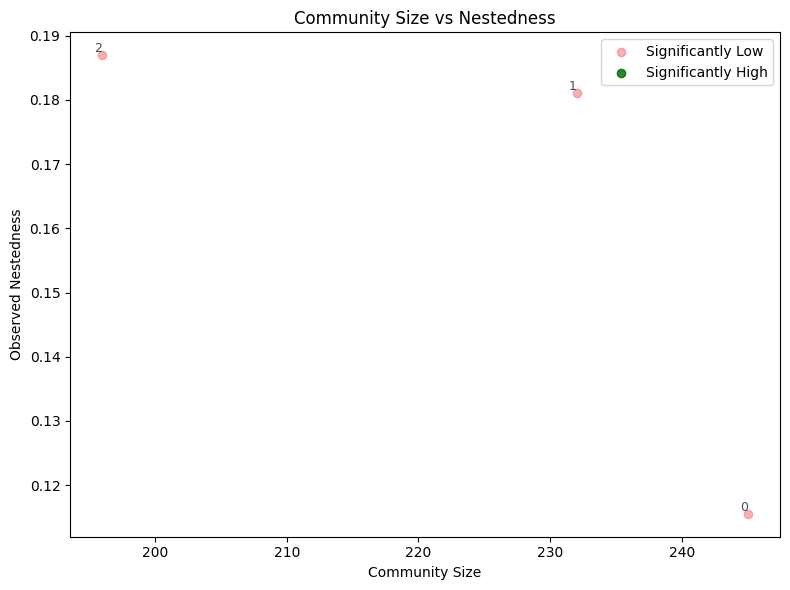

Plotted data (community_id, community_size, observed_nestedness, significance):
   community_id  community_size  observed_nestedness     significance
0             0             245             0.115531  not_significant
1             1             232             0.181126  not_significant
2             2             196             0.186957  not_significant


" plt.figure(figsize=(8, 6))\nplt.hist(valid_results_community_nestedness['p_value'].dropna(), bins=20, alpha=0.7, color='lightgreen', edgecolor='black')\nplt.axvline(0.05, color='red', linestyle='--', label='α=0.05')\nplt.xlabel('P-value')\nplt.ylabel('Frequency')\nplt.title('Distribution of P-values')\nplt.legend()\nplt.tight_layout()\nplt.savefig(os.path.join(figures_dir, 'nestedness_pvalue_distribution.png'), dpi=300, bbox_inches='tight')\nplt.show() "

In [38]:
# Visualize community nestedness results
valid_results_community_nestedness = community_nestedness_df[community_nestedness_df['significance'].isin(['significant', 'not_significant'])]

# Plot 2: Distribution of Z-scores
""" plt.figure(figsize=(8, 6))
plt.hist(valid_results_community_nestedness['z_score'].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Z=0')
plt.axvline(1.96, color='orange', linestyle='--', label='Z=1.96 (p=0.05)')
plt.axvline(-1.96, color='orange', linestyle='--')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.title('Distribution of Nestedness Z-scores')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'nestedness_zscores_distribution.png'), dpi=300, bbox_inches='tight')
plt.show() """

# Plot 3: Community size vs Nestedness, with community labels
plt.figure(figsize=(8, 6))
significant_mask = valid_results_community_nestedness['significance'] == 'significant'

# Plot not significant
plt.scatter(valid_results_community_nestedness[~significant_mask]['community_size'], 
  valid_results_community_nestedness[~significant_mask]['observed_nestedness'],
  c='lightcoral', alpha=0.6, label='Significantly Low')

# Plot significant
plt.scatter(valid_results_community_nestedness[significant_mask]['community_size'], 
  valid_results_community_nestedness[significant_mask]['observed_nestedness'],
  c='darkgreen', alpha=0.8, label='Significantly High')

# Annotate each point with its community_id
for idx, row in valid_results_community_nestedness.iterrows():
  plt.text(row['community_size'], row['observed_nestedness'], str(row['community_id']),
   fontsize=9, ha='right', va='bottom', alpha=0.7)

plt.xlabel('Community Size')
plt.ylabel('Observed Nestedness')
plt.title('Community Size vs Nestedness')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'nestedness_by_community_size.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print the data being plotted
print("Plotted data (community_id, community_size, observed_nestedness, significance):")
print(valid_results_community_nestedness[['community_id', 'community_size', 'observed_nestedness', 'significance']])

# Plot 4: P-value distribution
""" plt.figure(figsize=(8, 6))
plt.hist(valid_results_community_nestedness['p_value'].dropna(), bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', label='α=0.05')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'nestedness_pvalue_distribution.png'), dpi=300, bbox_inches='tight')
plt.show() """

In [39]:
def plot_communities_null_models_and_structure(communities_to_plot, dir_to_save, fig_name, title_column = 'community_id'):
    fig, axes = plt.subplots(len(communities_to_plot), 2, figsize=(16, 4 * len(communities_to_plot)))

    for i, (_, row) in enumerate(communities_to_plot.iterrows()):
        comm_idx = row['community_id']
        null_scores = row['null_scores']
        
        title = row[title_column]
        
        if len(null_scores) > 0:
            # Histogram of null model distribution
            sns.histplot(null_scores, kde=True, color='skyblue', ax=axes[i, 0])
            axes[i, 0].axvline(row['observed_nestedness'], color='red', linestyle='--', 
                            linewidth=2, label=f'Observed (NODF={row["observed_nestedness"]:.4f})')
            axes[i, 0].axvline(row['null_mean'], color='black', linestyle='-', 
                            linewidth=1, label=f'Null mean (NODF={row["null_mean"]:.4f})')
            axes[i, 0].set_title(f'Community {title} Null Model Analysis\n'
                                f'Z-score: {row["z_score"]:.4f}, p-value: {row["p_value"]:.4f}')
            axes[i, 0].set_xlabel('Nestedness (NODF)')
            axes[i, 0].set_ylabel('Frequency')
            axes[i, 0].legend()
        
        # Bar plot of community structure
        axes[i, 1].bar(['Left Nodes', 'Right Nodes'], 
                    [row['left_nodes'], row['right_nodes']], 
                    color=['lightblue', 'lightcoral'])
        axes[i, 1].set_title(f'Community {comm_idx} Structure\n'
                            f'Total size: {row["community_size"]}, Edges: {row["num_edges"]}')
        axes[i, 1].set_ylabel('Number of Nodes')

    plt.tight_layout()

    # Save figure
    plt.savefig(os.path.join(dir_to_save, fig_name), dpi=300, bbox_inches='tight')
    plt.show()


Detailed analysis for top 3 significant communities:


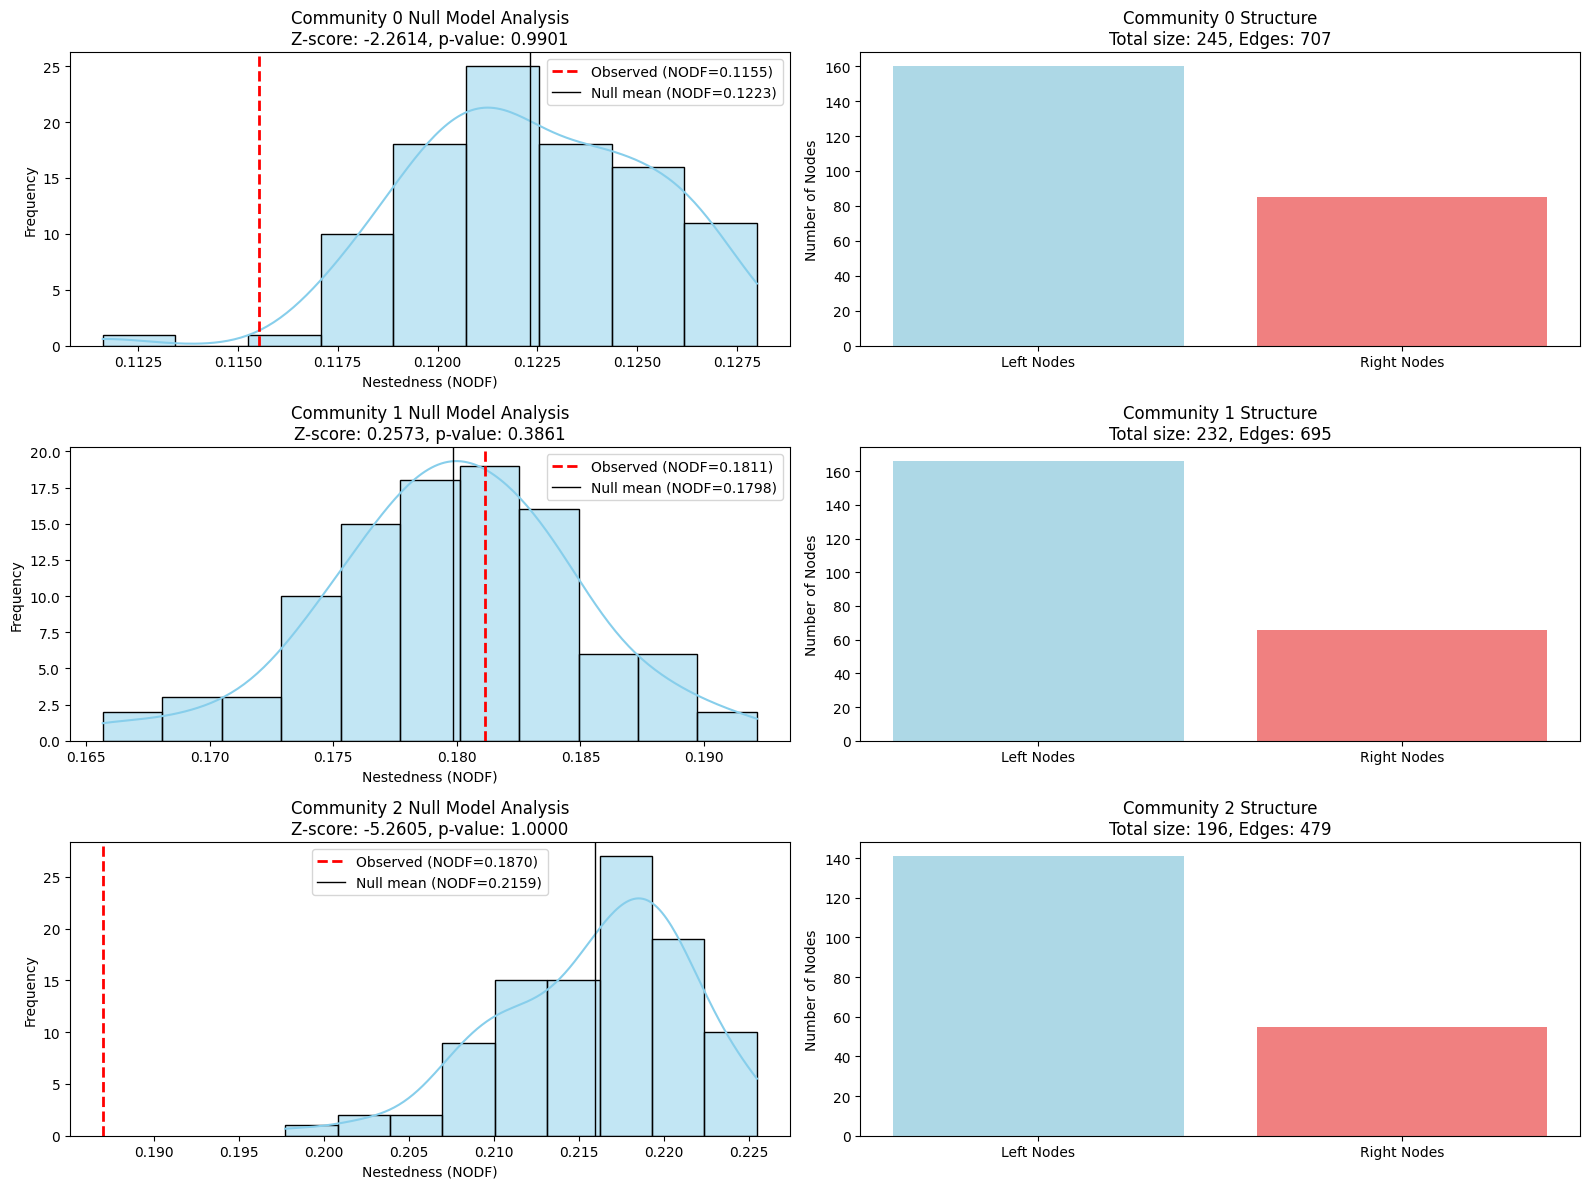

In [40]:
# Create detailed plots for significant communities
significant_communities = valid_results_community_nestedness.head(5)

print(f"\nDetailed analysis for top {len(significant_communities)} significant communities:")

plot_communities_null_models_and_structure(significant_communities, figures_dir, 'significant_communities_detailed.png', 'community_id')

#### Nestedness Evolution for each Community

In [48]:
# Focus on multiple communities for temporal nestedness analysis
target_communities = [0, 1, 2]

# Initialize storage for all communities' time series nestedness analysis
communities_data = {}
all_communities_nestedness_ts = {}
cumulative_window = 21
min_edges_threshold = 10

# Prepare data for each community
for community_id in target_communities:
    communities_data[community_id] = community_data[community_id].copy()
    all_communities_nestedness_ts[community_id] = []

print(f"Target communities for temporal analysis: {target_communities}")

# Display summary for each community
for community_id in target_communities:
    print(f"\nCommunity {community_id} summary:")
    print(f"Total investment pairs: {len(communities_data[community_id])}")
    print(f"Year range: {communities_data[community_id]['year'].min()} to {communities_data[community_id]['year'].max()}")
    
    # Show year distribution
    year_counts = communities_data[community_id]['year'].value_counts().sort_index()
    print(f"Investment pairs per year for Community {community_id}:")
    print(year_counts.head(10))  # Show first 10 years

Target communities for temporal analysis: [0, 1, 2]

Community 0 summary:
Total investment pairs: 717
Year range: 2008 to 2024
Investment pairs per year for Community 0:
year
2008      1
2009      2
2012     10
2014     15
2015     19
2016      2
2017     31
2018     33
2019    129
2020     38
Name: count, dtype: int64

Community 1 summary:
Total investment pairs: 712
Year range: 2004 to 2025
Investment pairs per year for Community 1:
year
2004     9
2006     6
2008     5
2009    10
2010     6
2011     2
2012     1
2013     5
2014    15
2015    33
Name: count, dtype: int64

Community 2 summary:
Total investment pairs: 489
Year range: 2009 to 2024
Investment pairs per year for Community 2:
year
2009      2
2010      4
2012      3
2013      1
2014      8
2015     28
2016     14
2017     14
2018     72
2019    105
Name: count, dtype: int64


In [49]:
# Process each community in target_communities
for community_id in target_communities:
    print(f"\n{'='*80}")
    print(f"PROCESSING COMMUNITY {community_id}")
    print(f"{'='*80}")
    
    community_data_current = communities_data[community_id]
    community_nestedness_ts = all_communities_nestedness_ts[community_id]
    
    # Define file path for this community
    community_ts_nestedness_file = f'../data/processed/us/community_{community_id}_ts_nestedness_file.csv.gz'
    
    # Get community nodes from the bipartite graph
    community_nodes = set(top_communities[community_id])
    
    if CALCULATE_COMMUNITIES_TS_NESTEDNESS or not os.path.exists(community_ts_nestedness_file):
        print(f"Computing nestedness evolution for Community {community_id} ({cumulative_window}-year cumulative windows)...")
        
        # Loop through each year and calculate metrics using cumulative windows
        for year in range(min_year, max_year + 1):
            # Get cumulative data for the current window
            window_data = community_data_current[
                (community_data_current['year'] <= year) & 
                (community_data_current['year'] >= year - cumulative_window)
            ]
            
            if len(window_data) < min_edges_threshold:
                print(f"Year {year}: Skipping (only {len(window_data)} investment pairs)")
                continue
            
            try:
                # Get active investors for this time window from the investment pairs
                active_left_investors = set(window_data['investor_name_left'].unique())
                active_right_investors = set(window_data['investor_name_right'].unique())
                
                # Filter to only include investors that are in this community AND active in this window
                window_community_left = [node for node in community_nodes if node in set_0 and node in active_left_investors]
                window_community_right = [node for node in community_nodes if node in set_1 and node in active_right_investors]
                
                # Skip if either set is empty
                if len(window_community_left) == 0 or len(window_community_right) == 0:
                    print(f"Year {year}: Skipping (empty bipartite set in time window)")
                    continue
                
                # Create adjacency matrix for this community and time window
                left_indices_window = {node: i for i, node in enumerate(window_community_left)}
                right_indices_window = {node: j for j, node in enumerate(window_community_right)}
                
                # Initialize adjacency matrix
                adjacency_matrix_window = np.zeros((len(window_community_left), len(window_community_right)))
                
                # Fill matrix with connections from the bipartite graph
                for left_node in window_community_left:
                    for right_node in window_community_right:
                        if bipartite_graph.has_edge(left_node, right_node):
                            left_idx = left_indices_window[left_node]
                            right_idx = right_indices_window[right_node]
                            adjacency_matrix_window[left_idx, right_idx] = 1
                            
                # Remove rows and columns that have only zeros from adjacency_matrix_window
                row_mask = adjacency_matrix_window.sum(axis=1) > 0
                col_mask = adjacency_matrix_window.sum(axis=0) > 0
                adjacency_matrix_window = adjacency_matrix_window[row_mask][:, col_mask]

                # Update left/right node lists to match filtered matrix
                # window_community_left = [node for i, node in enumerate(window_community_left) if row_mask[i]]
                # window_community_right = [node for j, node in enumerate(window_community_right) if col_mask[j]]
                
                # Calculate observed nestedness
                calculator_window = NestednessCalculator(adjacency_matrix_window)
                nestedness_score_window = calculator_window.nodf(adjacency_matrix_window)
                
                # Basic network metrics
                num_left_vcs = adjacency_matrix_window.shape[0]
                num_right_vcs = adjacency_matrix_window.shape[1]
                num_nodes = num_left_vcs + num_right_vcs
                num_edges = int(adjacency_matrix_window.sum())
                density = adjacency_matrix_window.mean()
                connectance = num_edges / (num_left_vcs * num_right_vcs) if num_left_vcs > 0 and num_right_vcs > 0 else np.nan
                # Generate null models using curve ball algorithm
                null_nestedness_scores_window = []
                n_iterations = 100  # Reduced for computational efficiency in time series
                n_iterations_cv = 10000
                
                print(f"Year {year}: Generating {n_iterations} null models...")
                for i in tqdm(range(n_iterations), desc=f"Community {community_id} Year {year}", leave=False):
                    try:
                        # Generate null model matrix
                        M = adjacency_matrix_window.copy()
                        r_hp = find_presences(M)
                        RM = curve_ball(M, r_hp, n_iterations_cv)
                        
                        null_matrix = RM.astype(adjacency_matrix_window.dtype)
                        
                        # Calculate nestedness of null model
                        calculator_null = NestednessCalculator(null_matrix)
                        null_score = calculator_null.nodf(null_matrix)
                        null_nestedness_scores_window.append(null_score)
                        
                    except Exception as e:
                        print(f"    Error in null model iteration {i}: {e}")
                        continue
                
                # Calculate statistical significance
                if len(null_nestedness_scores_window) > 0:
                    null_scores_array = np.array(null_nestedness_scores_window)
                    mean_null = np.mean(null_scores_array)
                    std_null = np.std(null_scores_array)
                    
                    if std_null > 0:
                        z_score = (nestedness_score_window - mean_null) / std_null
                    else:
                        z_score = np.nan
                    
                    # Corrected p-value calculation for empirical distributions
                    # Adding 1 to both numerator and denominator to avoid p-values of exactly 0
                    # This is the standard approach for empirical p-values with discrete distributions
                    p_value = (np.sum(null_scores_array >= nestedness_score_window) + 1) / (len(null_scores_array) + 1)
                    significance = 'significant' if p_value < 0.05 else 'not_significant'
                else:
                    mean_null = std_null = z_score = p_value = np.nan
                    significance = 'null_model_failed'
                    null_scores_array = np.array([])
                
                # Store results
                community_nestedness_ts.append({
                    'community_id': community_id,
                    'year': year,
                    'window_start': year - cumulative_window,
                    'window_end': year,
                    'num_pairs': len(window_data),
                    'num_nodes': num_nodes,
                    'left_nodes': num_left_vcs,
                    'right_nodes': num_right_vcs,
                    'num_edges': num_edges,
                    'density': density,
                    'connectance': connectance,
                    'observed_nestedness': nestedness_score_window,
                    'null_mean': mean_null,
                    'null_std': std_null,
                    'z_score': z_score,
                    'p_value': p_value,
                    'significance': significance,
                    'null_scores': null_scores_array.tolist() if len(null_scores_array) > 0 else []
                })
                
                print(f"Year {year}: {num_nodes} nodes ({num_left_vcs} left, {num_right_vcs} right), "
                    f"{num_edges} edges, Connectance: {connectance:.4f}, "
                    f"Nestedness: {nestedness_score_window:.4f}, "
                    f"Z-score: {z_score:.4f}, P-value: {p_value:.4f} ({significance})")
                
            except Exception as e:
                print(f"Year {year}: Error - {str(e)}")
                continue

        print(f"\nSuccessfully analyzed {len(community_nestedness_ts)} years for Community {community_id}")
        
        # Save results for this community
        community_nestedness_df = pd.DataFrame(community_nestedness_ts)
        community_nestedness_df.to_csv(community_ts_nestedness_file, compression='gzip')
        print(f"Saved nestedness results to {community_ts_nestedness_file}")
        
        # Store in all_communities_nestedness_ts
        all_communities_nestedness_ts[community_id] = community_nestedness_ts
        
    else:
        # Load existing results
        community_nestedness_df = pd.read_csv(community_ts_nestedness_file, compression='gzip')    
        # Apply the parsing function to the null_scores column
        community_nestedness_df['null_scores'] = community_nestedness_df['null_scores'].apply(parse_null_scores)
        print(f"Loaded nestedness results from {community_ts_nestedness_file}")
        
        # Convert to list format for consistency
        all_communities_nestedness_ts[community_id] = community_nestedness_df.to_dict('records')

print(f"\n{'='*80}")
print("COMPLETED PROCESSING ALL TARGET COMMUNITIES")
print(f"{'='*80}")


PROCESSING COMMUNITY 0
Computing nestedness evolution for Community 0 (21-year cumulative windows)...
Year 2004: Skipping (only 0 investment pairs)
Year 2005: Skipping (only 0 investment pairs)
Year 2006: Skipping (only 0 investment pairs)
Year 2007: Skipping (only 0 investment pairs)
Year 2008: Skipping (only 1 investment pairs)
Year 2009: Skipping (only 3 investment pairs)
Year 2010: Skipping (only 3 investment pairs)
Year 2011: Skipping (only 3 investment pairs)
Year 2012: Generating 100 null models...


Year 2012: 13 nodes (7 left, 6 right), 14 edges, Connectance: 0.3333, Nestedness: 0.2222, Z-score: -2.6557, P-value: 1.0000 (not_significant)
Year 2013: Generating 100 null models...


Year 2013: 13 nodes (7 left, 6 right), 14 edges, Connectance: 0.3333, Nestedness: 0.2222, Z-score: -2.3356, P-value: 1.0000 (not_significant)
Year 2014: Generating 100 null models...


Year 2014: 19 nodes (13 left, 6 right), 31 edges, Connectance: 0.3974, Nestedness: 0.3625, Z-score: -4.1535, P-value: 0.9901 (not_significant)
Year 2015: Generating 100 null models...


Year 2015: 34 nodes (23 left, 11 right), 67 edges, Connectance: 0.2648, Nestedness: 0.3566, Z-score: -3.4788, P-value: 0.9901 (not_significant)
Year 2016: Generating 100 null models...


...

Year 2020: 136 nodes (92 left, 44 right), 331 edges, Connectance: 0.0818, Nestedness: 0.2007, Z-score: -4.5058, P-value: 1.0000 (not_significant)
Year 2021: Generating 100 null models...


Year 2021: 163 nodes (115 left, 48 right), 391 edges, Connectance: 0.0708, Nestedness: 0.1901, Z-score: -6.3903, P-value: 1.0000 (not_significant)
Year 2022: Generating 100 null models...


Year 2022: 187 nodes (135 left, 52 right), 456 edges, Connectance: 0.0650, Nestedness: 0.1870, Z-score: -4.4205, P-value: 1.0000 (not_significant)
Year 2023: Generating 100 null models...


Year 2023: 189 nodes (137 left, 52 right), 458 edges, Connectance: 0.0643, Nestedness: 0.1877, Z-score: -5.0776, P-value: 1.0000 (not_significant)
Year 2024: Generating 100 null models...


Year 2024: 196 nodes (141 left, 55 right), 479 edges, Connectance: 0.0618, Nestedness: 0.1870, Z-score: -4.5362, P-value: 1.0000 (not_significant)

Successfully analyzed 12 years for Community 2
Saved nestedness results to ../data/processed/us/community_2_ts_nestedness_file.csv.gz

COMPLETED PROCESSING ALL TARGET COMMUNITIES


In [50]:
# Display comprehensive summary for all communities
print("NESTEDNESS EVOLUTION SUMMARY FOR ALL TARGET COMMUNITIES")
print("=" * 80)

# Store dataframes for all communities
all_communities_dfs = {}

for community_id in target_communities:
    print(f"\nCommunity {community_id} Nestedness Evolution Summary:")
    print("-" * 60)
    
    # Convert to DataFrame for analysis
    community_df = pd.DataFrame(all_communities_nestedness_ts[community_id])
    all_communities_dfs[community_id] = community_df
    
    if len(community_df) > 0:
        community_df['community_size'] = community_df['num_nodes']
        
        print(f"Years analyzed: {len(community_df)}")
        print(f"Period: {community_df['year'].min()} to {community_df['year'].max()}")
        print(f"Significant periods (p < 0.05): {len(community_df[community_df['significance'] == 'significant'])}")

        # Display summary statistics
        print("\nNestedness Statistics Over Time:")
        valid_results = community_df[community_df['significance'].isin(['significant', 'not_significant'])]
        if len(valid_results) > 0:
            print(f"Mean observed nestedness: {valid_results['observed_nestedness'].mean():.4f} ± {valid_results['observed_nestedness'].std():.4f}")
            print(f"Mean null nestedness: {valid_results['null_mean'].mean():.4f} ± {valid_results['null_mean'].std():.4f}")
            print(f"Mean Z-score: {valid_results['z_score'].mean():.4f} ± {valid_results['z_score'].std():.4f}")
            print(f"Mean connectance: {valid_results['connectance'].mean():.4f} ± {valid_results['connectance'].std():.4f}")

        print("\nTop 10 Years with Highest Nestedness:")
        top_nestedness = valid_results.nlargest(10, 'observed_nestedness')[['year', 'num_pairs', 'num_nodes', 'connectance', 'observed_nestedness', 'z_score', 'p_value', 'significance']]
        print(top_nestedness.round(4))
    else:
        print("No data available for this community")

# Compare communities
print(f"\n{'='*80}")
print("CROSS-COMMUNITY COMPARISON")
print(f"{'='*80}")

comparison_data = []
for community_id in target_communities:
    if community_id in all_communities_dfs and len(all_communities_dfs[community_id]) > 0:
        df = all_communities_dfs[community_id]
        valid_results = df[df['significance'].isin(['significant', 'not_significant'])]
        if len(valid_results) > 0:
            comparison_data.append({
                'Community': community_id,
                'Years_Analyzed': len(df),
                'Significant_Years': len(df[df['significance'] == 'significant']),
                'Mean_Nestedness': valid_results['observed_nestedness'].mean(),
                'Max_Nestedness': valid_results['observed_nestedness'].max(),
                'Mean_Z_Score': valid_results['z_score'].mean(),
                'Mean_Connectance': valid_results['connectance'].mean()
            })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\nCommunity Comparison Summary:")
    print(comparison_df.round(4))

NESTEDNESS EVOLUTION SUMMARY FOR ALL TARGET COMMUNITIES

Community 0 Nestedness Evolution Summary:
------------------------------------------------------------
Years analyzed: 13
Period: 2012 to 2024
Significant periods (p < 0.05): 0

Nestedness Statistics Over Time:
Mean observed nestedness: 0.2139 ± 0.0903
Mean null nestedness: 0.2550 ± 0.1280
Mean Z-score: -2.2168 ± 1.6166
Mean connectance: 0.1726 ± 0.1248

Top 10 Years with Highest Nestedness:
   year  num_pairs  num_nodes  connectance  observed_nestedness  z_score  \
2  2014         28         19       0.3974               0.3625  -4.1535   
3  2015         47         34       0.2648               0.3566  -3.4788   
4  2016         49         37       0.2333               0.3339  -3.6760   
5  2017         80         53       0.1682               0.2674  -4.2356   
0  2012         13         13       0.3333               0.2222  -2.6557   
1  2013         13         13       0.3333               0.2222  -2.3356   
6  2018        1

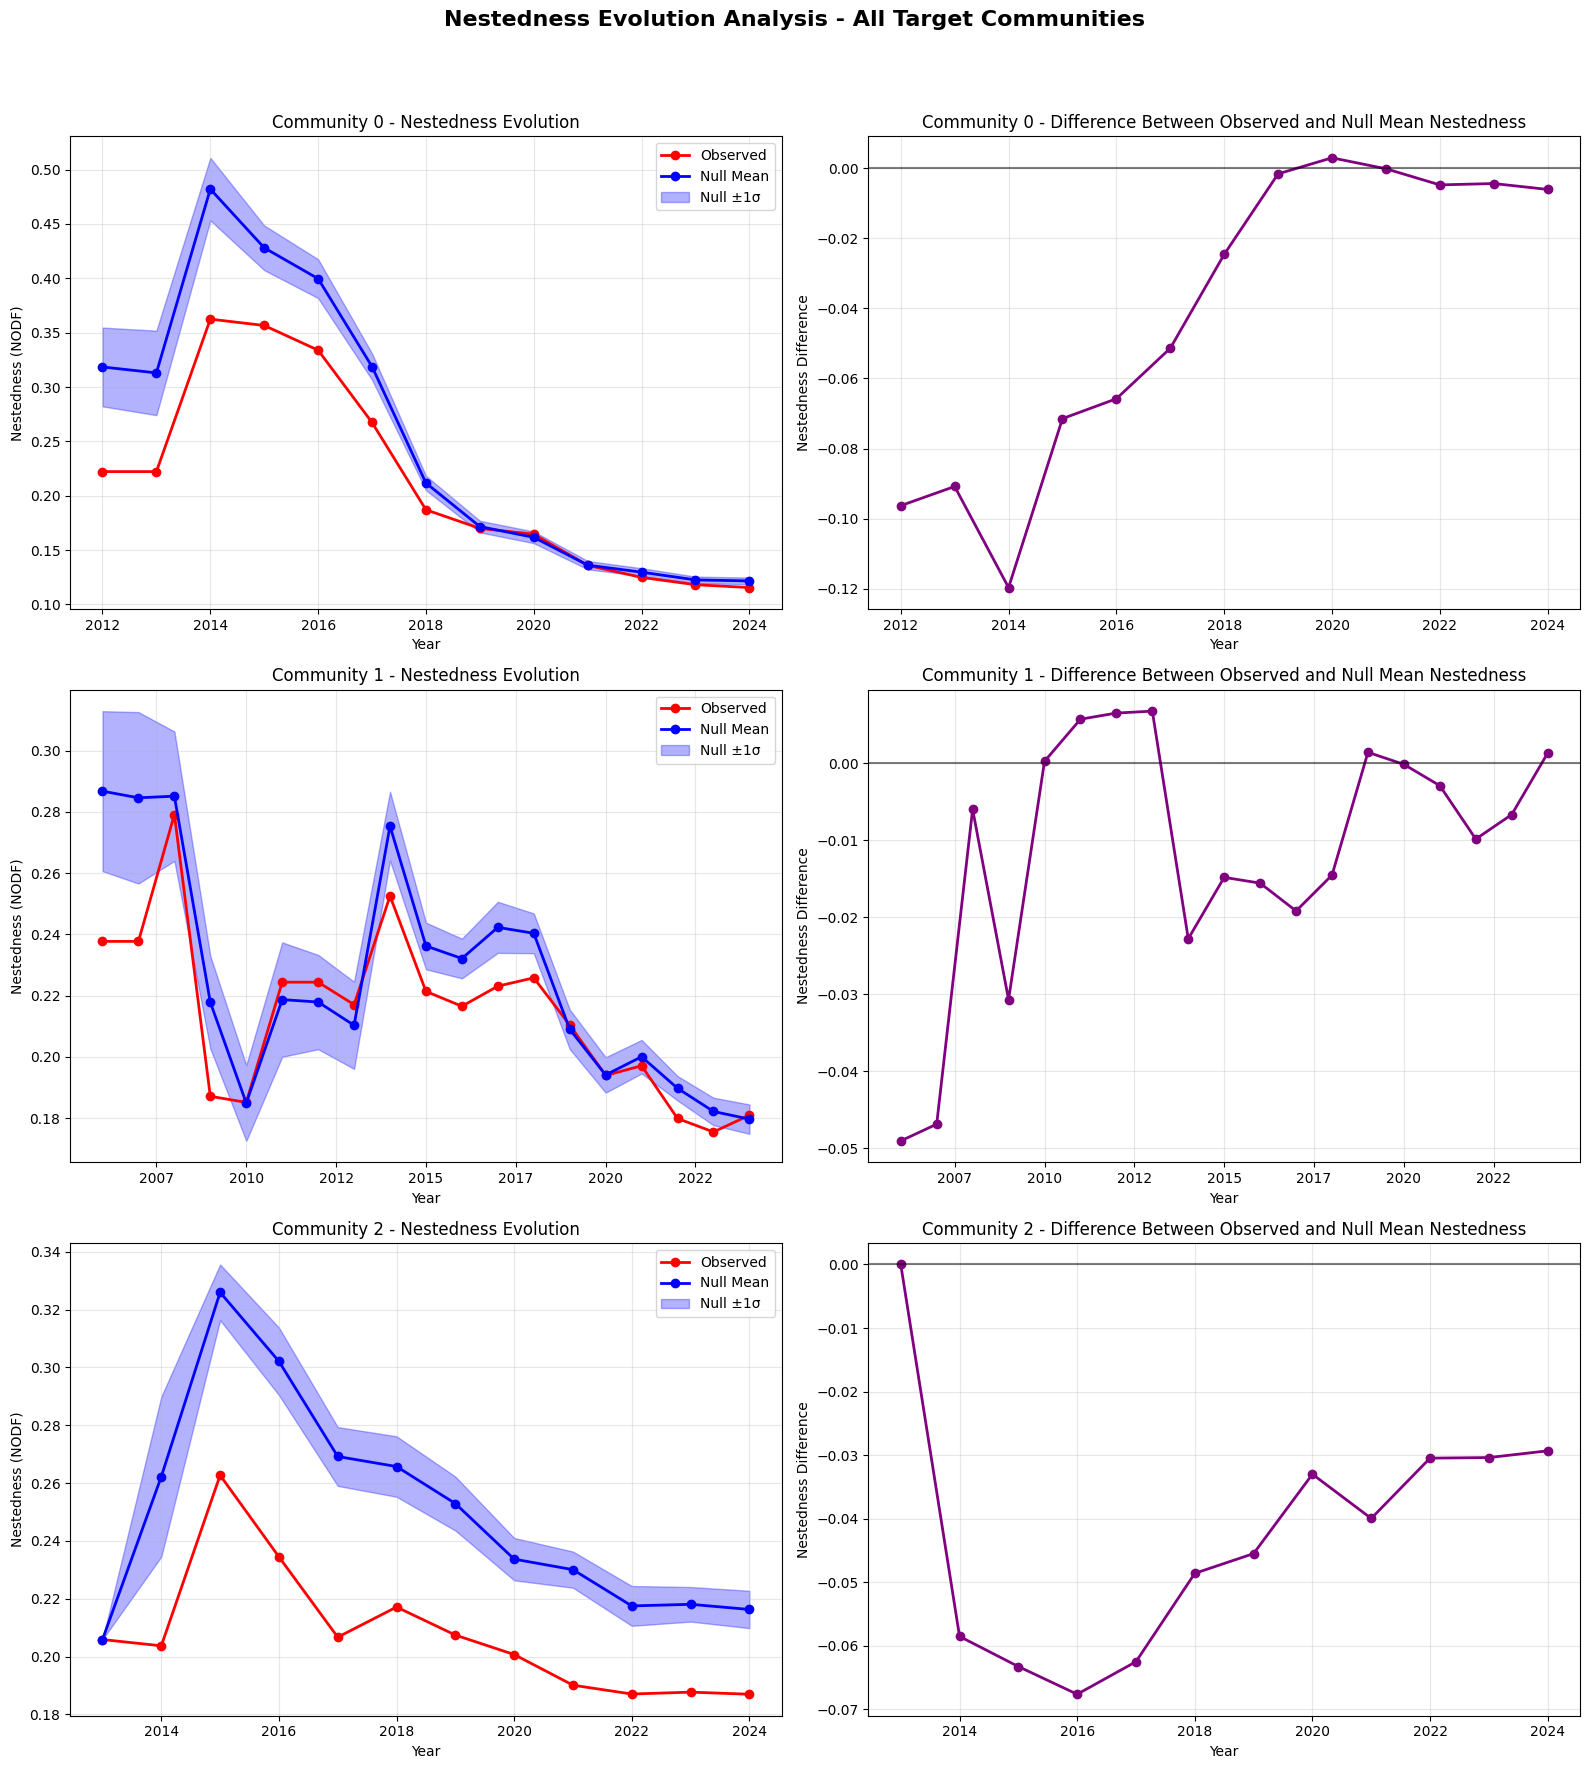

In [51]:
# Create comprehensive plots for all communities
n_communities = len(target_communities)
fig, axes = plt.subplots(n_communities, 2, figsize=(16, 6 * n_communities))

# If only one community, ensure axes is 2D
if n_communities == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Nestedness Evolution Analysis - All Target Communities', 
             fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, community_id in enumerate(target_communities):
    if community_id not in all_communities_dfs or len(all_communities_dfs[community_id]) == 0:
        # Handle case where community has no data
        axes[i, 0].text(0.5, 0.5, f'No data available\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=12)
        axes[i, 1].text(0.5, 0.5, f'No data available\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 1].transAxes, fontsize=12)
        axes[i, 0].set_title(f'Community {community_id} - Nestedness Evolution')
        axes[i, 1].set_title(f'Community {community_id} - Difference Between Observed and Null Mean Nestedness')
        continue
    
    community_df = all_communities_dfs[community_id]
    color = colors[i % len(colors)]
    
    # Filter for valid results
    valid_data = community_df[community_df['significance'].isin(['significant', 'not_significant'])].copy()
    significant_data = valid_data[valid_data['significance'] == 'significant']
    
    if len(valid_data) == 0:
        axes[i, 0].text(0.5, 0.5, f'No valid results\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=12)
        axes[i, 1].text(0.5, 0.5, f'No valid results\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 1].transAxes, fontsize=12)
        continue
    
    # Plot 1: Observed vs Null Nestedness over time (left)
    ax1 = axes[i, 0]
    ax1.plot(valid_data['year'], valid_data['observed_nestedness'], 
             'o-', linewidth=2, markersize=6, color='red', label='Observed')
    ax1.plot(valid_data['year'], valid_data['null_mean'], 
             'o-', linewidth=2, markersize=6, color='blue', label='Null Mean')
    ax1.fill_between(valid_data['year'], 
                     valid_data['null_mean'] - valid_data['null_std'],
                     valid_data['null_mean'] + valid_data['null_std'],
                     alpha=0.3, color='blue', label='Null ±1σ')
    ax1.set_title(f'Community {community_id} - Nestedness Evolution')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Nestedness (NODF)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
    
    # Plot 2: Difference between observed and null mean nestedness (right)
    ax2 = axes[i, 1]
    nestedness_diff = valid_data['observed_nestedness'] - valid_data['null_mean']
    ax2.plot(valid_data['year'], nestedness_diff, 
             'o-', linewidth=2, markersize=6, color='purple')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax2.set_title(f'Community {community_id} - Difference Between Observed and Null Mean Nestedness')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Nestedness Difference')
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
    
    # Highlight significant differences
    for j, (year, diff, sig) in enumerate(zip(valid_data['year'], 
                                              nestedness_diff, 
                                              valid_data['significance'])):
        if sig == 'significant':
            ax2.scatter(year, diff, s=100, edgecolor='red', facecolor='none', linewidth=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
plt.savefig(os.path.join(figures_dir, 'nestedness_evolution_all_communities_comparison.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

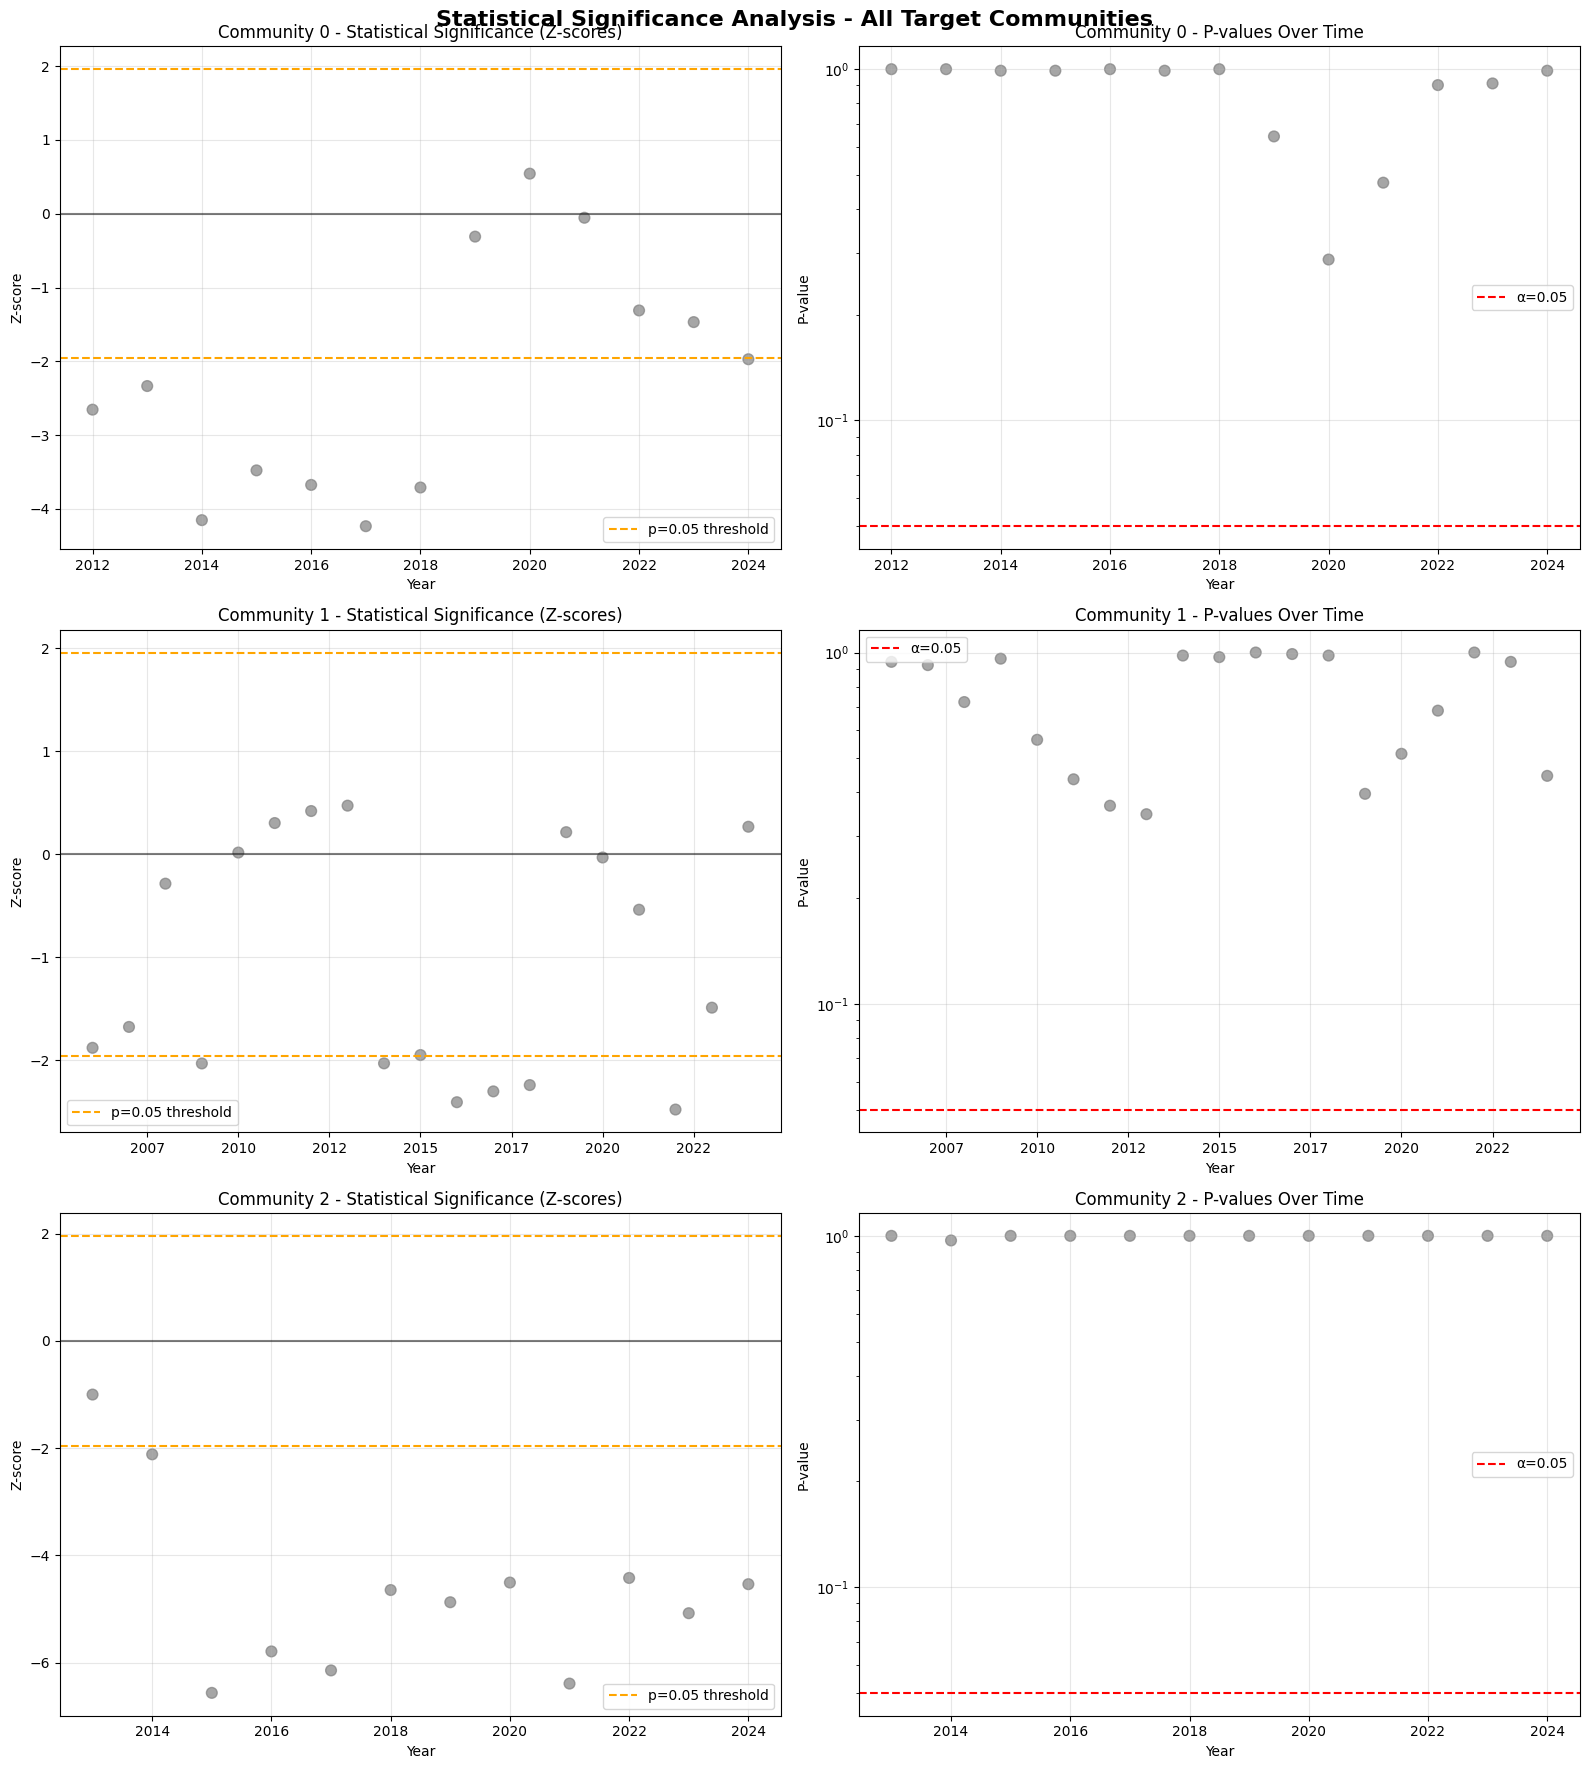

In [52]:
# Create statistical significance plots for all communities
n_communities = len(target_communities)
fig, axes = plt.subplots(n_communities, 2, figsize=(16, 6 * n_communities))

# If only one community, ensure axes is 2D
if n_communities == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Statistical Significance Analysis - All Target Communities', 
             fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, community_id in enumerate(target_communities):
    if community_id not in all_communities_dfs or len(all_communities_dfs[community_id]) == 0:
        # Handle case where community has no data
        axes[i, 0].text(0.5, 0.5, f'No data available\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=12)
        axes[i, 1].text(0.5, 0.5, f'No data available\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 1].transAxes, fontsize=12)
        axes[i, 0].set_title(f'Community {community_id} - Z-scores Over Time')
        axes[i, 1].set_title(f'Community {community_id} - P-values Over Time')
        continue
    
    community_df = all_communities_dfs[community_id]
    
    # Filter for valid results only
    valid_data = community_df[community_df['significance'].isin(['significant', 'not_significant'])].copy()
    
    if len(valid_data) == 0:
        axes[i, 0].text(0.5, 0.5, f'No valid results\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 0].transAxes, fontsize=12)
        axes[i, 1].text(0.5, 0.5, f'No valid results\nfor Community {community_id}', 
                       ha='center', va='center', transform=axes[i, 1].transAxes, fontsize=12)
        continue
    
    # Plot Z-scores over time
    ax1 = axes[i, 0]
    colors_sig = ['red' if sig == 'significant' else 'gray' for sig in valid_data['significance']]
    ax1.scatter(valid_data['year'], valid_data['z_score'], 
               c=colors_sig, s=60, alpha=0.7)
    ax1.axhline(y=1.96, color='orange', linestyle='--', label='p=0.05 threshold')
    ax1.axhline(y=-1.96, color='orange', linestyle='--')
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.set_title(f'Community {community_id} - Statistical Significance (Z-scores)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Z-score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

    # Plot P-values over time
    ax2 = axes[i, 1]
    ax2.scatter(valid_data['year'], valid_data['p_value'], 
               c=colors_sig, s=60, alpha=0.7)
    ax2.axhline(y=0.05, color='red', linestyle='--', label='α=0.05')
    ax2.set_title(f'Community {community_id} - P-values Over Time')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('P-value')
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'statistical_significance_all_communities.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

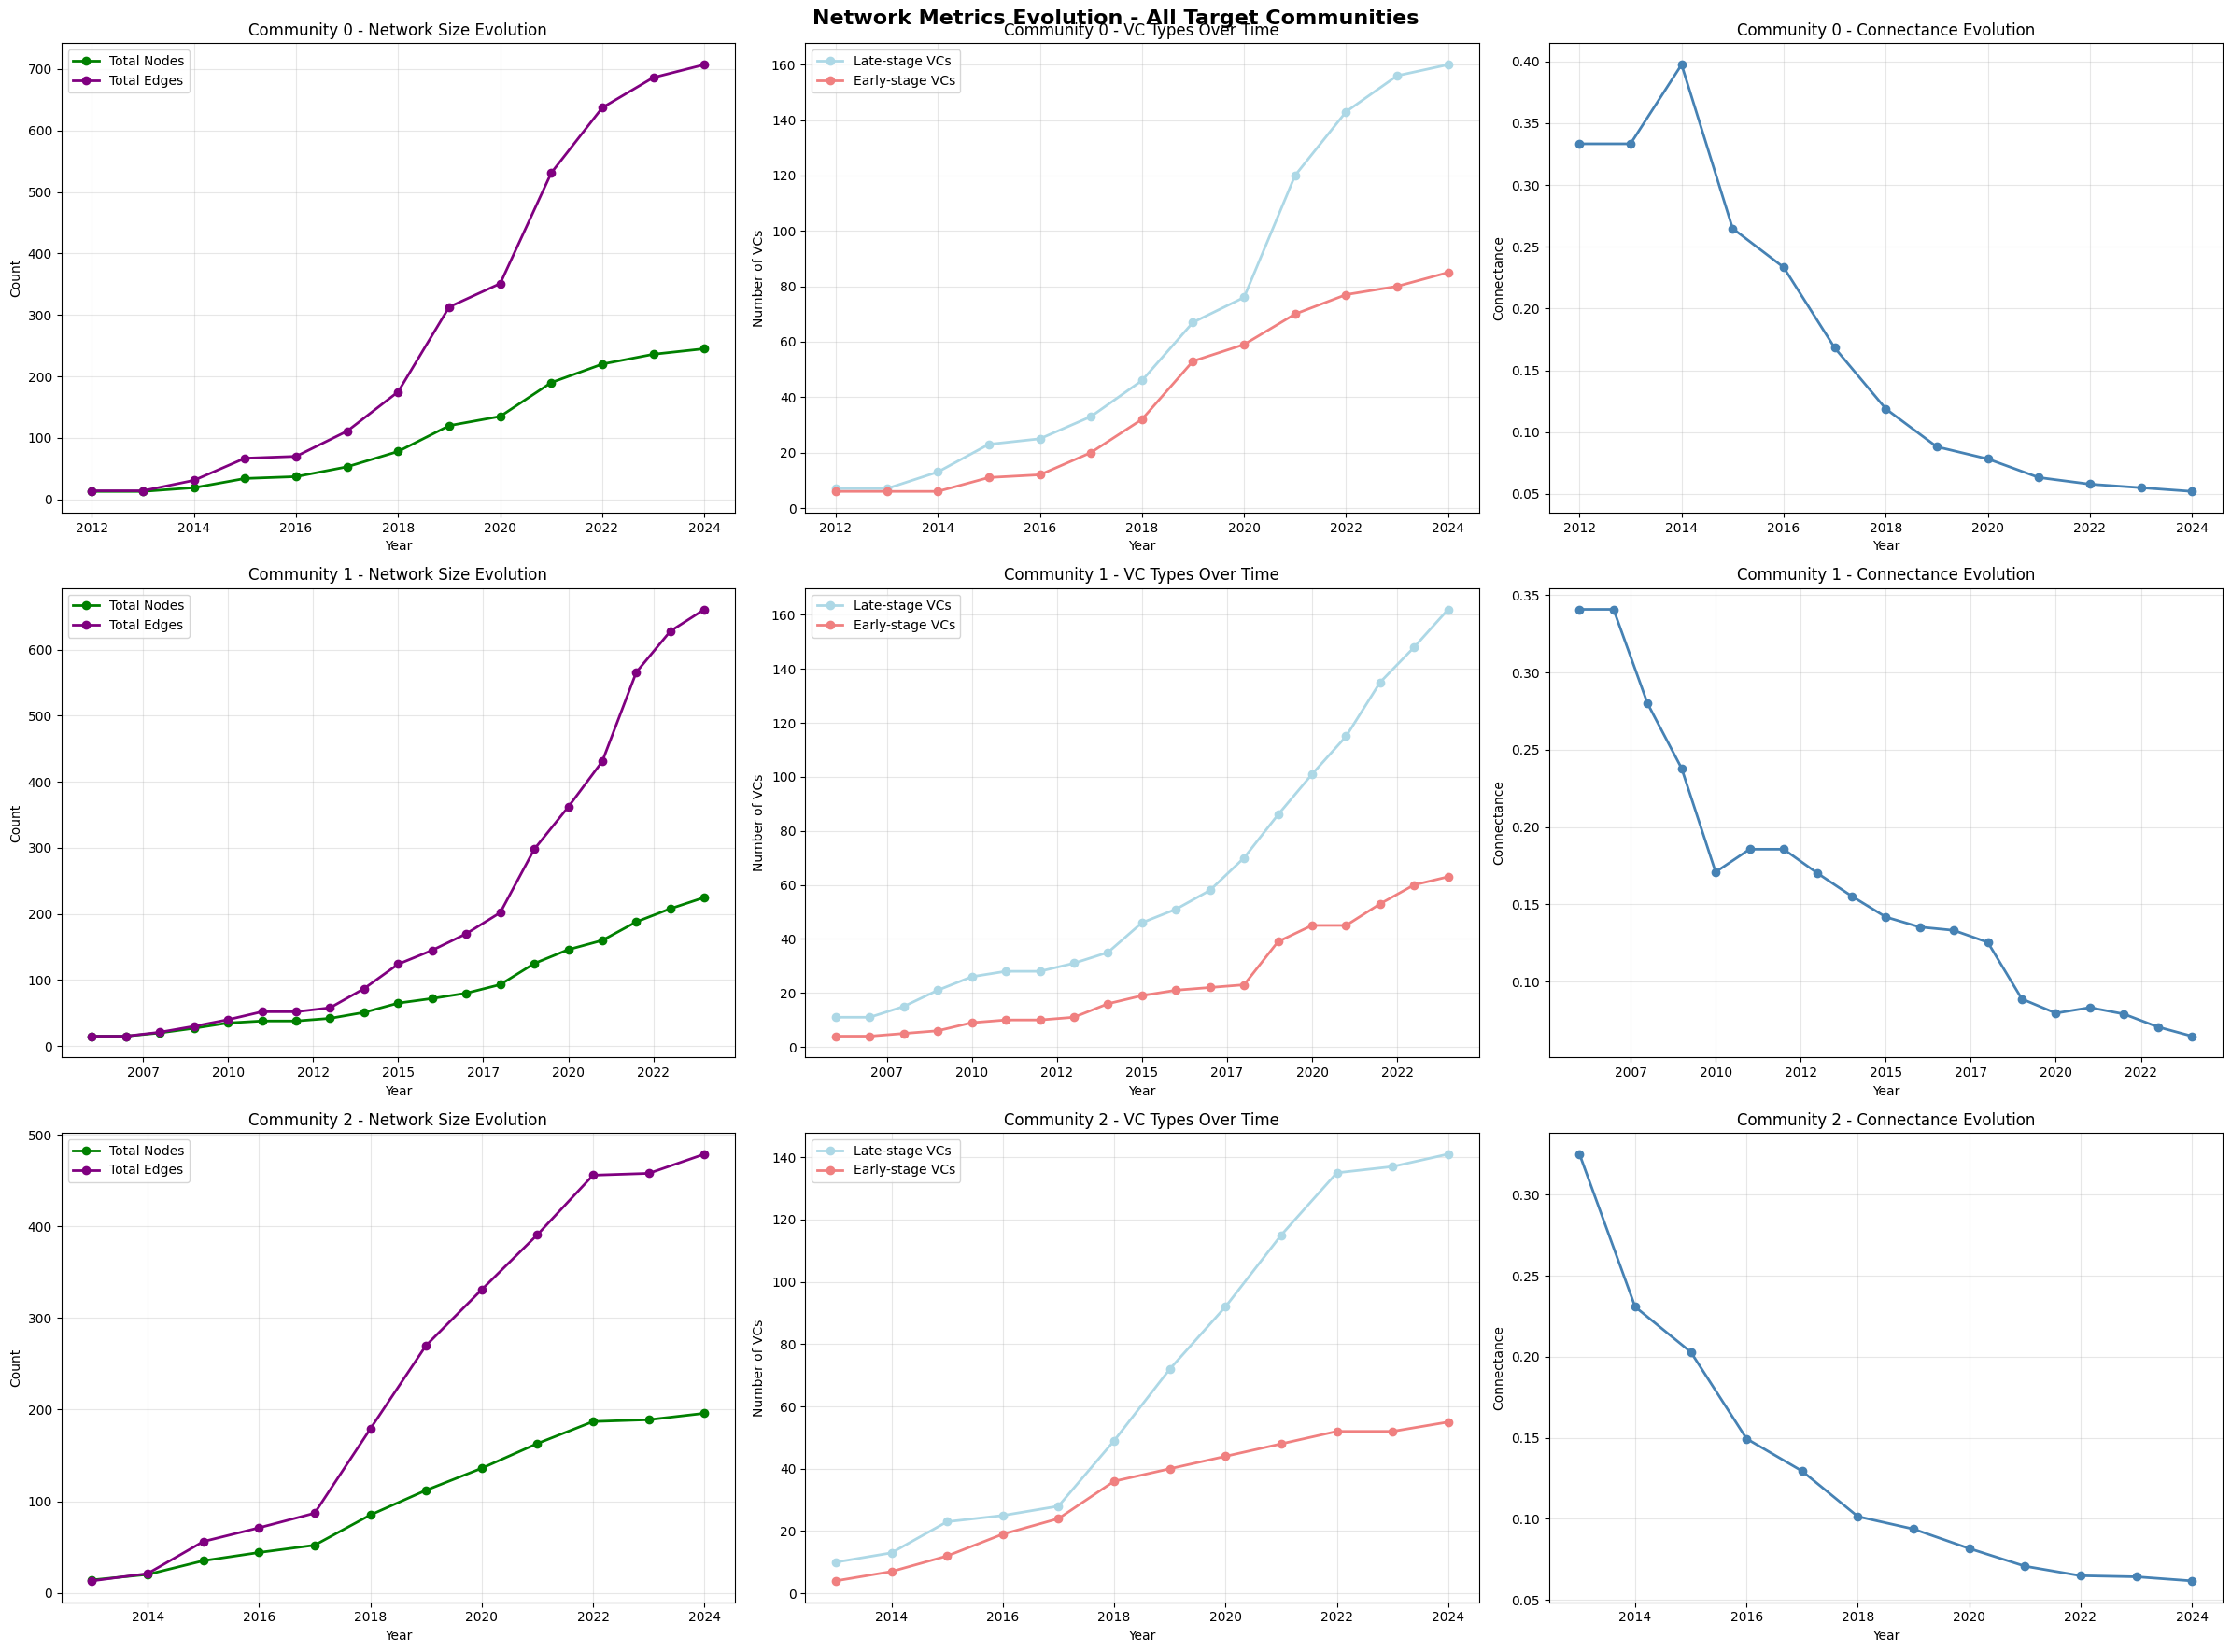

In [53]:
# Create network metrics evolution plots for all communities
n_communities = len(target_communities)
fig, axes = plt.subplots(n_communities, 3, figsize=(24, 6 * n_communities))

# If only one community, ensure axes is 2D
if n_communities == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Network Metrics Evolution - All Target Communities', 
             fontsize=16, fontweight='bold')

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, community_id in enumerate(target_communities):
    if community_id not in all_communities_dfs or len(all_communities_dfs[community_id]) == 0:
        # Handle case where community has no data
        for j in range(3):
            axes[i, j].text(0.5, 0.5, f'No data available\nfor Community {community_id}', 
                           ha='center', va='center', transform=axes[i, j].transAxes, fontsize=12)
        axes[i, 0].set_title(f'Community {community_id} - Network Size Evolution')
        axes[i, 1].set_title(f'Community {community_id} - VC Types Over Time')
        axes[i, 2].set_title(f'Community {community_id} - Connectance Evolution')
        continue
    
    community_df = all_communities_dfs[community_id]
    
    # Filter for valid results and sort by year to prevent line crossing issues
    valid_data = community_df[community_df['significance'].isin(['significant', 'not_significant'])].copy()
    valid_data = valid_data.sort_values('year').reset_index(drop=True)
    
    if len(valid_data) == 0:
        for j in range(3):
            axes[i, j].text(0.5, 0.5, f'No valid results\nfor Community {community_id}', 
                           ha='center', va='center', transform=axes[i, j].transAxes, fontsize=12)
        continue
    
    color = colors[i % len(colors)]
    
    # Plot 1: Network size evolution
    ax1 = axes[i, 0]
    
    # Use scatter plots with optional lines for better handling of sparse data
    if len(valid_data) > 1:
        ax1.plot(valid_data['year'], valid_data['num_nodes'], 
                'o-', linewidth=2, markersize=6, color='green', label='Total Nodes')
        ax1.plot(valid_data['year'], valid_data['num_edges'], 
                'o-', linewidth=2, markersize=6, color='purple', label='Total Edges')
    else:
        ax1.scatter(valid_data['year'], valid_data['num_nodes'], 
                   s=60, color='green', label='Total Nodes')
        ax1.scatter(valid_data['year'], valid_data['num_edges'], 
                   s=60, color='purple', label='Total Edges')
    
    ax1.set_title(f'Community {community_id} - Network Size Evolution')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Count')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

    # Plot 2: Left vs Right VCs
    ax2 = axes[i, 1]
    
    if len(valid_data) > 1:
        ax2.plot(valid_data['year'], valid_data['left_nodes'], 
                'o-', linewidth=2, markersize=6, color='lightblue', label='Late-stage VCs')
        ax2.plot(valid_data['year'], valid_data['right_nodes'], 
                'o-', linewidth=2, markersize=6, color='lightcoral', label='Early-stage VCs')
    else:
        ax2.scatter(valid_data['year'], valid_data['left_nodes'], 
                   s=60, color='lightblue', label='Late-stage VCs')
        ax2.scatter(valid_data['year'], valid_data['right_nodes'], 
                   s=60, color='lightcoral', label='Early-stage VCs')
    
    ax2.set_title(f'Community {community_id} - VC Types Over Time')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Number of VCs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

    # Plot 3: Connectance evolution
    ax3 = axes[i, 2]
    
    if len(valid_data) > 1:
        ax3.plot(valid_data['year'], valid_data['connectance'], 
                'o-', linewidth=2, markersize=6, color='steelblue')
    else:
        ax3.scatter(valid_data['year'], valid_data['connectance'], 
                   s=60, color='steelblue')
    
    ax3.set_title(f'Community {community_id} - Connectance Evolution')
    ax3.set_xlabel('Year')
    ax3.set_ylabel('Connectance')
    ax3.grid(True, alpha=0.3)
    ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))

plt.tight_layout()

# Save figure
plt.savefig(os.path.join(figures_dir, 'network_metrics_evolution_all_communities.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

SIGNIFICANT PERIODS ANALYSIS FOR ALL COMMUNITIES

Community 0 - Significant Periods Analysis:
------------------------------------------------------------
Periods analyzed (from 2014): 11
Significant periods: 0


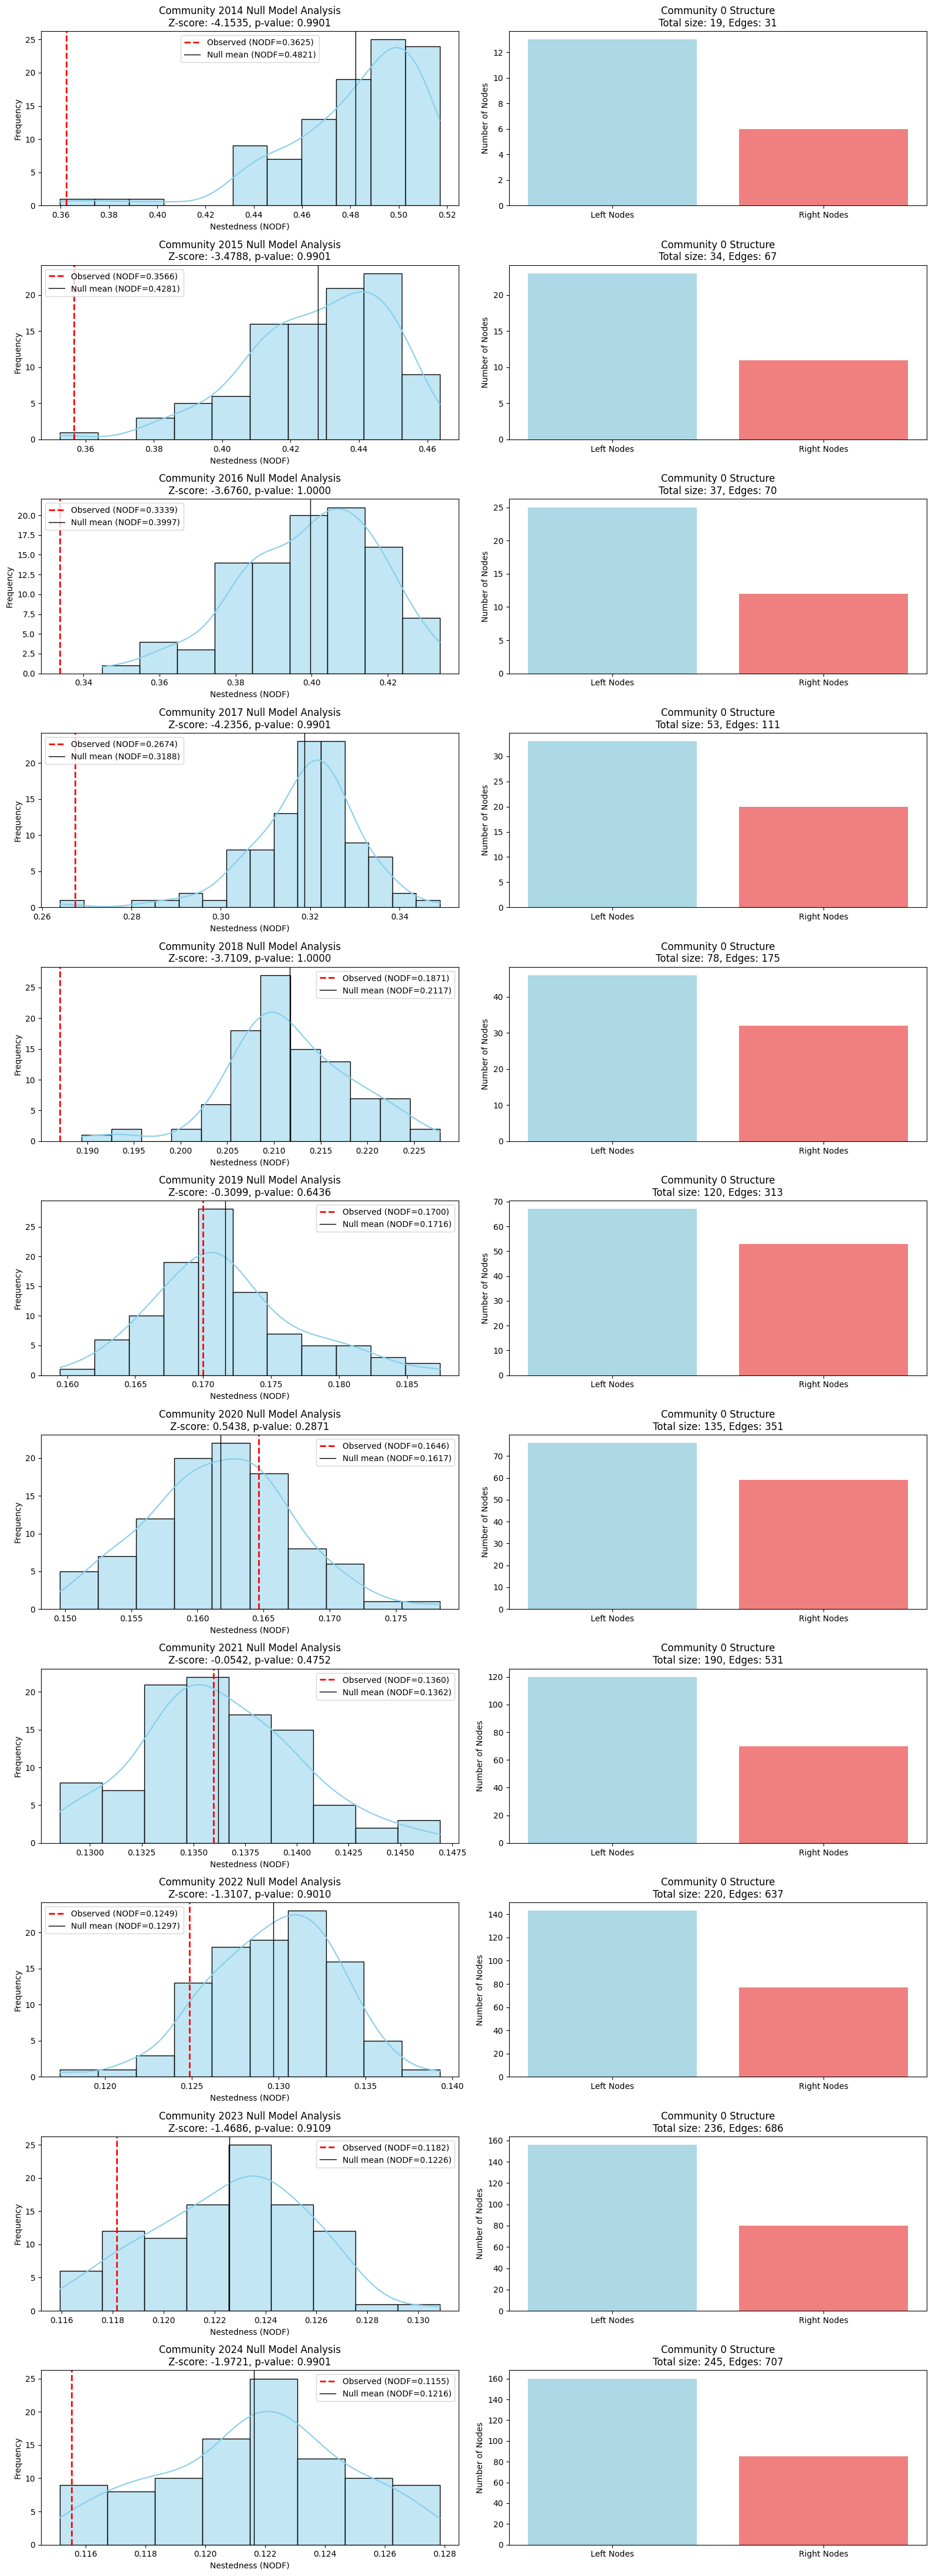

Generated visualization for Community 0

Community 1 - Significant Periods Analysis:
------------------------------------------------------------
Periods analyzed (from 2014): 11
Significant periods: 0


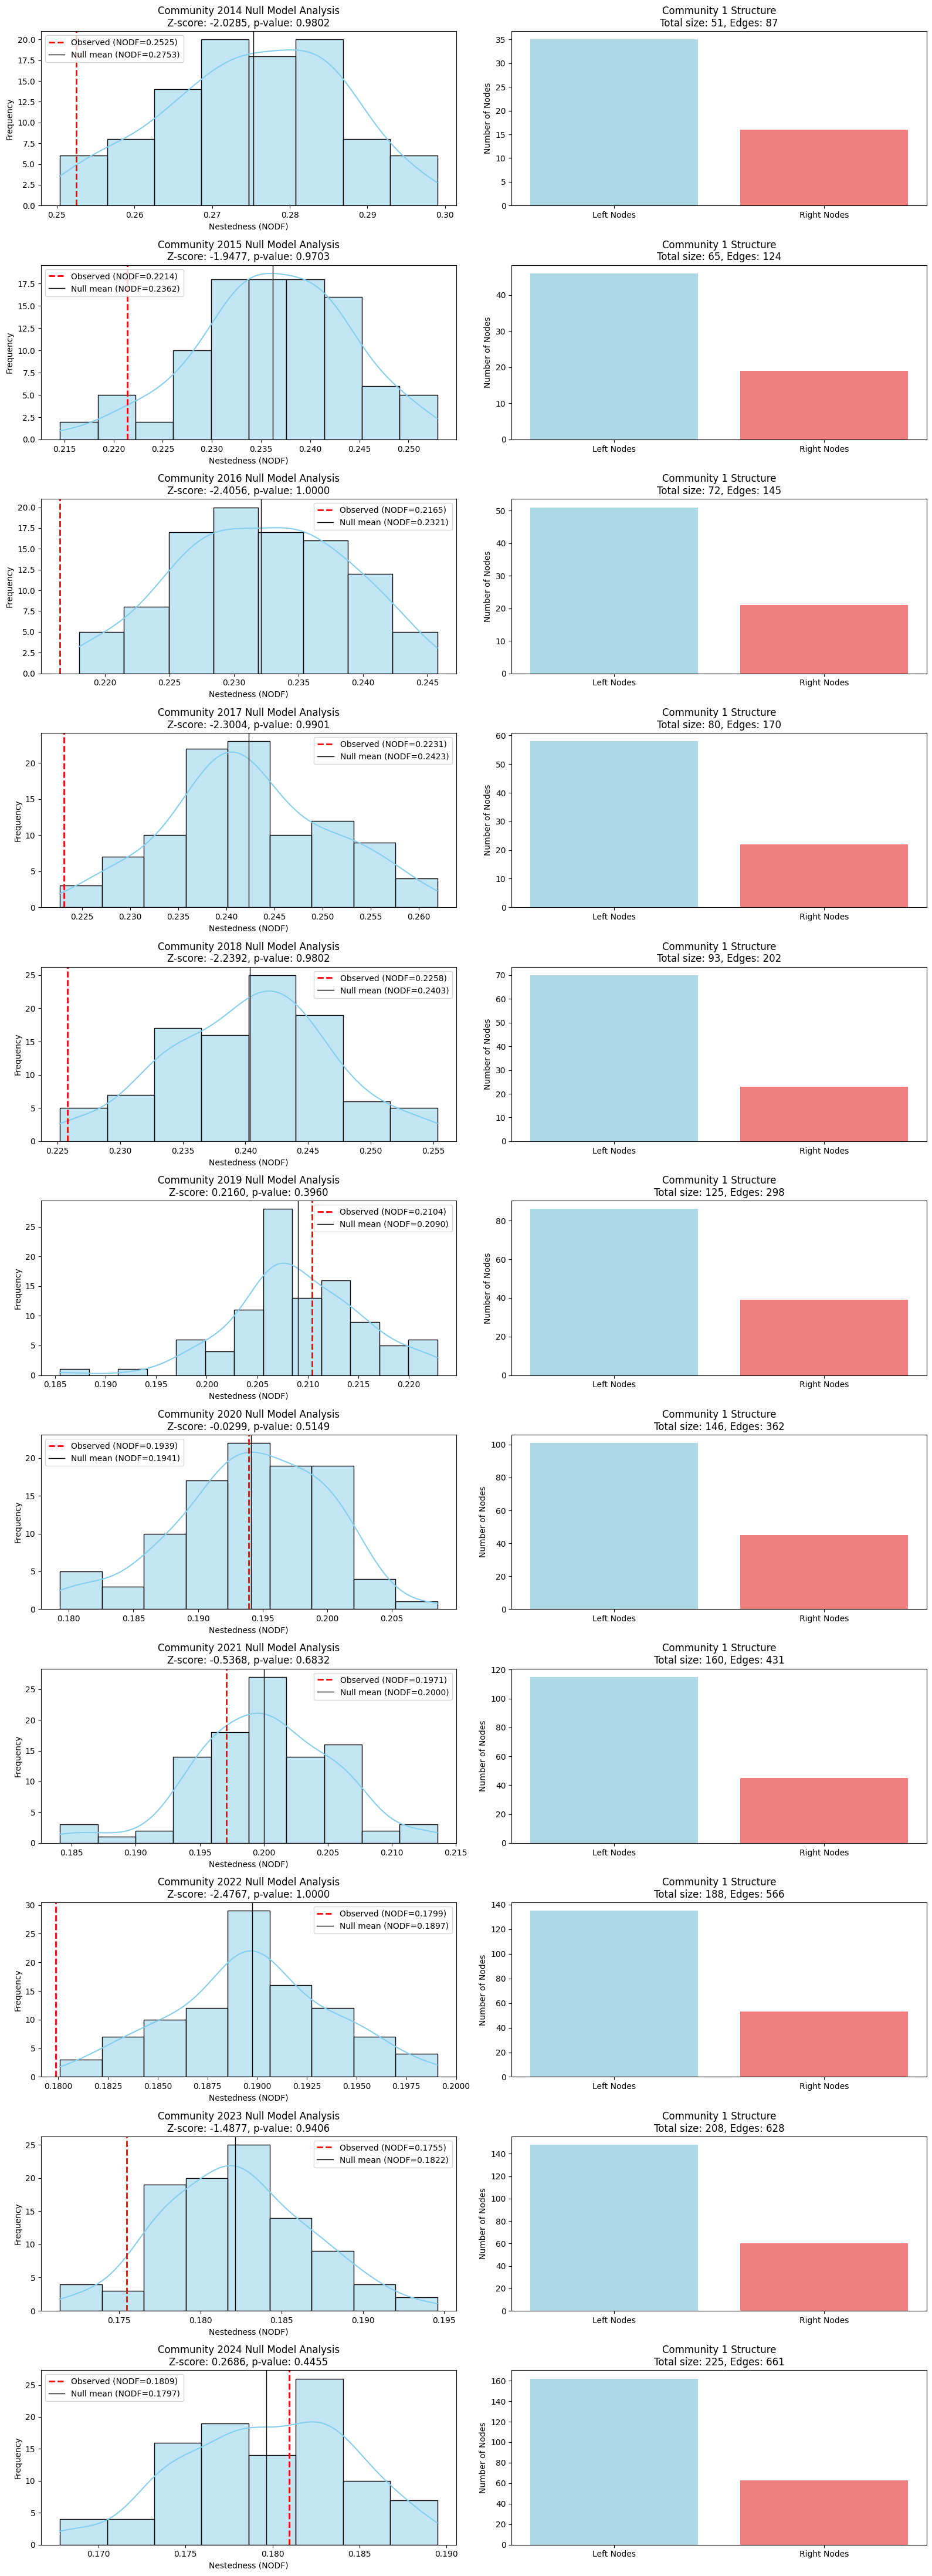

Generated visualization for Community 1

Community 2 - Significant Periods Analysis:
------------------------------------------------------------
Periods analyzed (from 2014): 11
Significant periods: 0


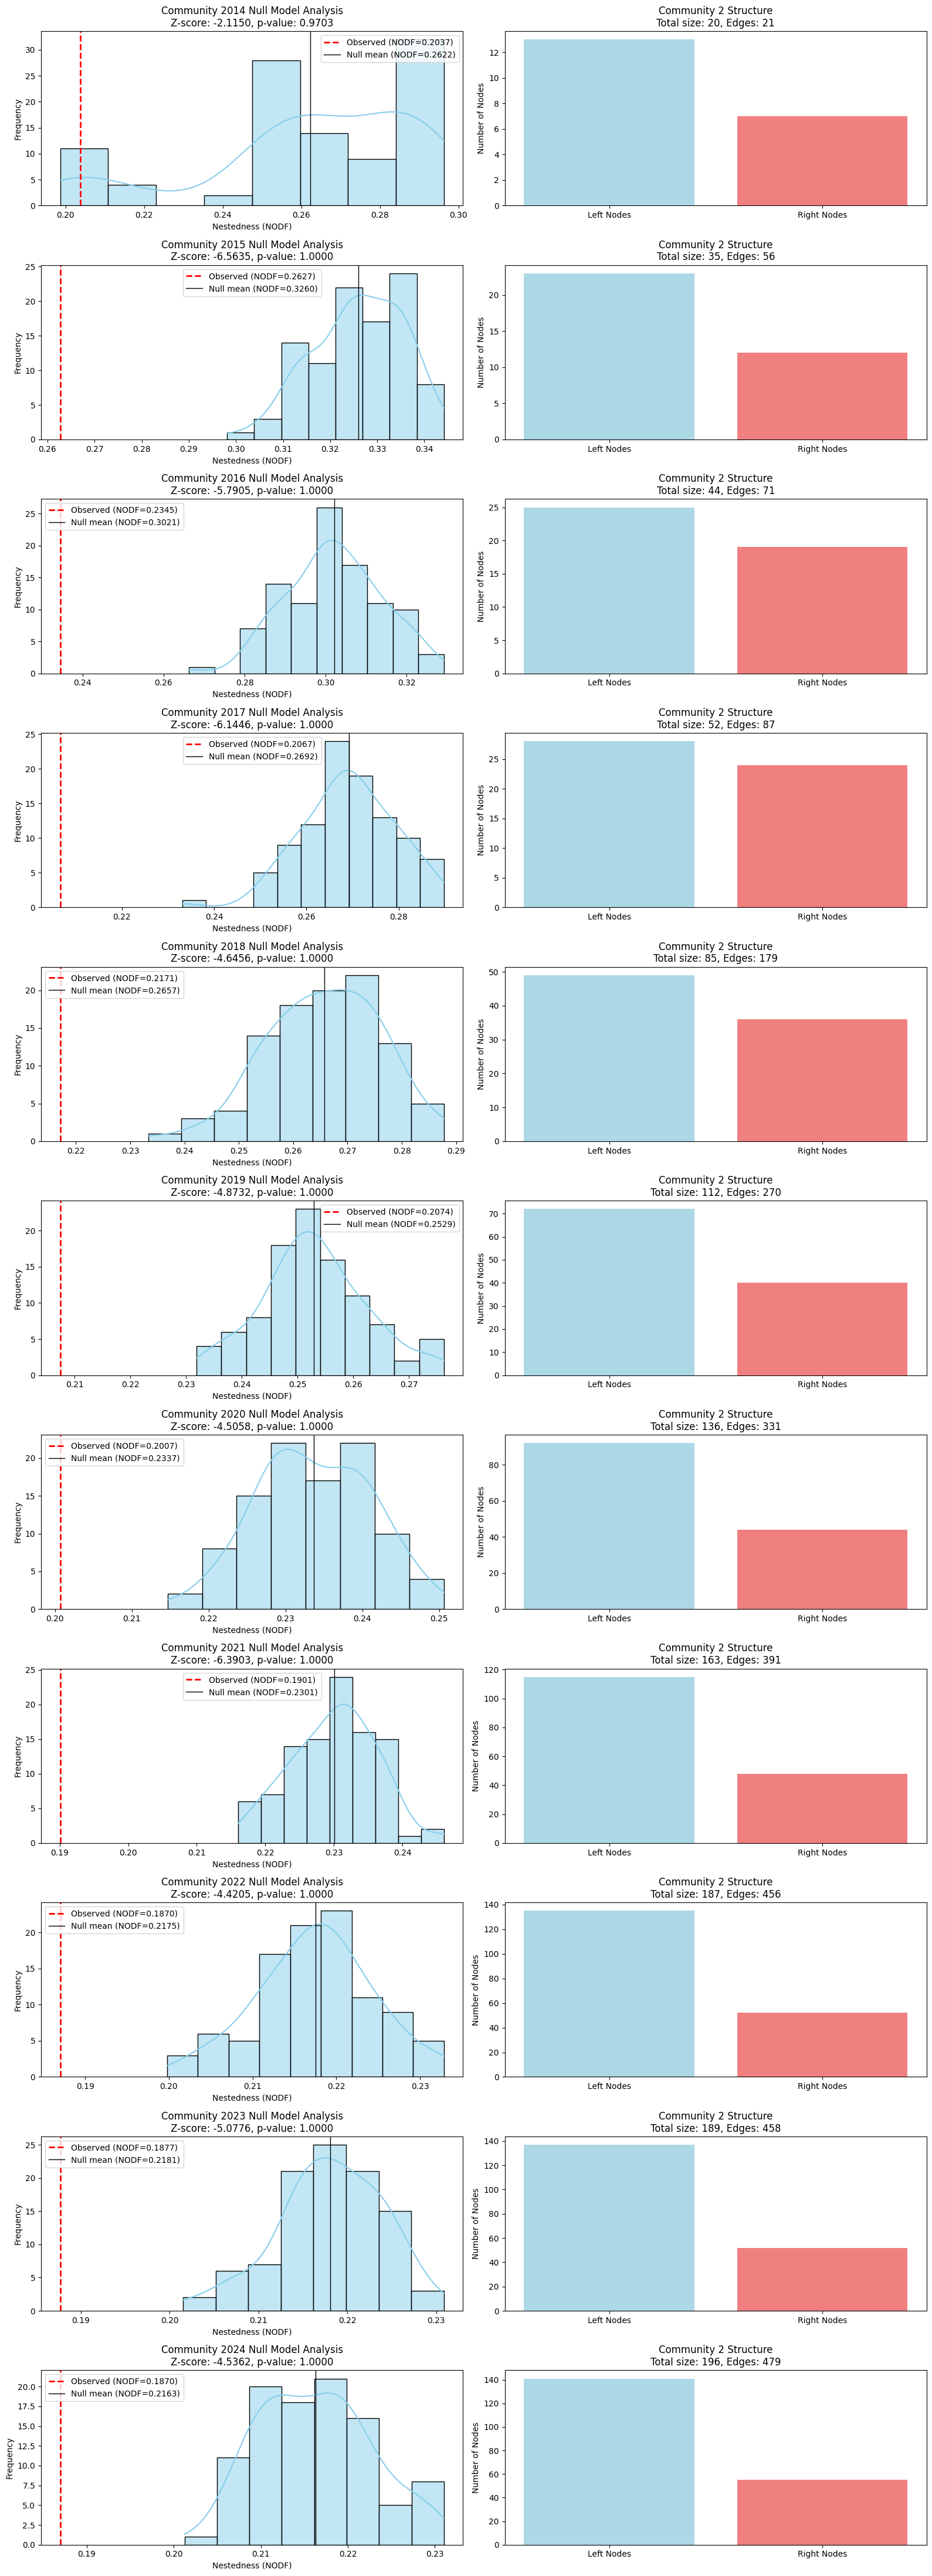

Generated visualization for Community 2

COMPLETED SIGNIFICANT PERIODS ANALYSIS FOR ALL COMMUNITIES


In [54]:
# Analyze significant periods for all communities
print("SIGNIFICANT PERIODS ANALYSIS FOR ALL COMMUNITIES")
print("=" * 80)

significant_years_threshold = 2014  # Years to focus on for significance analysis

for community_id in target_communities:
    print(f"\nCommunity {community_id} - Significant Periods Analysis:")
    print("-" * 60)
    
    if community_id not in all_communities_dfs or len(all_communities_dfs[community_id]) == 0:
        print(f"No data available for Community {community_id}")
        continue
    
    community_df = all_communities_dfs[community_id]
    
    # Focus on periods from 2014 onwards (or adjust threshold as needed)
    significant_periods = community_df[community_df['year'] >= significant_years_threshold]
    
    if len(significant_periods) > 0:
        print(f"Periods analyzed (from {significant_years_threshold}): {len(significant_periods)}")
        
        # Count significant periods
        sig_periods = significant_periods[significant_periods['significance'] == 'significant']
        print(f"Significant periods: {len(sig_periods)}")
        
        if len(sig_periods) > 0:
            print(f"Significant years: {sorted(sig_periods['year'].tolist())}")
            print(f"Peak nestedness in significant periods: {sig_periods['observed_nestedness'].max():.4f}")
            print(f"Mean nestedness in significant periods: {sig_periods['observed_nestedness'].mean():.4f}")
        
        # Call plotting function if it exists
        try:
            plot_communities_null_models_and_structure(
                significant_periods, 
                figures_dir, 
                f'dont_commit_significant_periods_community_{community_id}.png', 
                'year'
            )
            print(f"Generated visualization for Community {community_id}")
        except NameError:
            print(f"Plotting function not available - skipping visualization for Community {community_id}")
        except Exception as e:
            print(f"Error generating visualization for Community {community_id}: {e}")
    else:
        print(f"No data available for the specified period (>= {significant_years_threshold})")

print(f"\n{'='*80}")
print("COMPLETED SIGNIFICANT PERIODS ANALYSIS FOR ALL COMMUNITIES")
print(f"{'='*80}")